# Análisis del perfil de salud de los estadounidenses

Nicolás Vives Vicente

La salud de una persona está directamente relacionada con algunos hábitos, pero existen otros que a priori no diríamos que afectan a la salud aunque consideremos que se trata de 'buenos hábitos' o 'buenas situaciones'. El nivel educativo, tener hijos, ser propietario de una vivienda, el estado laboral... no son propiamente hábitos pero pertenecen al contexto de una persona, y reflejan parte de su disiplina y capacidades en la vida. El objetivo de este trabajo es tratar de predecir la salud y el índice de masa corporal de las personas en base a toda serie de variables, tanto los hábitos que todo el mundo diría que están ligados a la salud como la alimentación o el ejercicio, como esta serie de situaciones comentadas que en principio no lo estarían tanto. Por último mediante aprendizaje no-supervisado se intentará agrupar a la población en grupos en base a estas variables comentadas y se verá cómo es la salud y el IMC de los grupos formados.

Para realizar el trabajo se ha utilizado el conjunto de datos del Sistema de Vigilancia de Factores de Riesgo del Comportamiento (BRFSS), disponible en: https://www.cdc.gov/brfss/annual_data/annual_data.htm. Esta base de datos recopila información anual sobre los perfiles de los ciudadanos, además de factores de riesgo y enfermedades crónicas a través de encuestas telefónicas. Los datos cubren los 50 estados de los EE. UU. y varios territorios. Se ha elegido este *dataset* por la cantidad de entradas y de variables, además de que estudiar este tema en un país como Estados Unidos resulta muy interesante ya que existe un grave problema de salud pública.

Se puede descargar el CodeBook que explica el significado de cada variable y sus posibles valores en: https://www.cdc.gov/brfss/annual_data/2024/zip/codebook24_llcp-v2-508.zip

# 1. Introducción


Importación de liberías:

In [1]:
# 1. Sistema y Utilidades
import os
import re
import time
import joblib
from itertools import cycle
from google.colab import drive

# 2. Procesamiento de Datos y Visualización
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 3. Scikit-Learn
from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.decomposition import PCA

# Clasificación
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    StackingClassifier
)

# Regresión
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR

# Aprendizaje No Supervisado (Clustering)
from sklearn.cluster import KMeans, DBSCAN
from sklearn.neighbors import NearestNeighbors

# Métricas y Evaluación
from sklearn.metrics import (
    # Clasificación
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, roc_curve, auc,
    # Regresión
    mean_absolute_error, mean_squared_error, r2_score,
    # Clustering
    silhouette_score
)

In [2]:
ENTORNO = 'kaggle'

if ENTORNO == 'colab':
    from google.colab import drive
    drive.mount('/content/drive')

    base_path = '/content/drive/Othercomputers/Mi portátil/'

    file_raw_path = os.path.join(base_path, 'datos', 'LLCP2024.XPT')
    results_path = os.path.join(base_path, 'resultados')

    # Cargar el dataset crudo desde el archivo XPT
    df = pd.read_sas(file_raw_path)

elif ENTORNO == 'kaggle':
    input_path = '/kaggle/input/datasets/nicovives/brfss-2024-base-data/'
    file_raw_path = os.path.join(input_path, 'LLCP2024.XPT')
    results_path = '/kaggle/input/datasets/nicovives/resultados/resultados'

    # Cargar el dataset crudo desde el archivo XPT
    df = pd.read_sas(file_raw_path)

print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}")

Filas: 457670, Columnas: 301


Puesto que el conjunto de datos tiene demasiadas columnas, concretamente 301, y muchas de ellas no son relevantes para nuestro análisis, seleccionamos las necesarias.

In [3]:
# Variables seleccionadas
columnas = [

    # SALUD GENERAL Y MENTAL
    'GENHLTH',   # Salud general (Target)
    'PHYSHLTH',  # Días con mala salud física en el último mes
    'MENTHLTH',  # Días con mala salud mental en el último mes
    'POORHLTH',  # Días que la mala salud impidió hacer actividades

    # DEMOGRAFÍA Y SOCIOECONOMÍA
    'SEXVAR',    # Sexo
    'MARITAL',   # Estado civil
    'EDUCA',     # Nivel educativo
    'EMPLOY1',   # Estado de empleo (trabajando, parado, jubilado...)
    'INCOME3',   # Nivel de ingresos
    'RENTHOM1',  # Propietario o inquilino de la vivienda
    'CHILDREN',  # Número de niños en el hogar
    'WEIGHT2',   # Peso
    'HEIGHT3',   # Altura

    # ACCESO A LA SALUD
    '_HLTHPL2',  # ¿Tiene cobertura/seguro médico?
    'PERSDOC3',  # ¿Tiene un médico de cabecera o personal?
    'MEDCOST1',  # ¿No pudo ir al médico por el coste el último año?

    # HISTORIAL DE CONDICIONES CRÓNICAS
    'CVDINFR4',  # Diagnóstico de ataque al corazón
    'CVDCRHD4',  # Diagnóstico de angina / enfermedad coronaria
    'CVDSTRK3',  # Diagnóstico de accidente cerebrovascular (Ictus)
    'ASTHMA3',   # Diagnóstico de asma
    'CHCOCNC1',  # Diagnóstico de otros tipos de cáncer
    'CHCCOPD3',  # Diagnóstico de EPOC, enfisema o bronquitis crónica
    'ADDEPEV3',  # Diagnóstico de trastorno depresivo
    'CHCKDNY2',  # Diagnóstico de enfermedad renal
    'DIABETE4',  # Diagnóstico de diabetes
    'HAVARTH4',  # Diagnóstico de artritis

    # DISCAPACIDADES Y DIFICULTADES FÍSICAS
    'DEAF',      # Sordera o dificultad severa para oír
    'BLIND',     # Ceguera o dificultad severa para ver
    'DECIDE',    # Dificultad para concentrarse o recordar
    'DIFFWALK',  # Dificultad para caminar o subir escaleras
    'DIFFDRES',  # Dificultad para vestirse o bañarse
    'DIFFALON',  # Dificultad para hacer recados solo

    # HÁBITOS DE VIDA (TABACO, ALCOHOL, EJERCICIO)
    'SMOKE100',  # ¿Ha fumado 100 cigarrillos en su vida?
    'SMOKDAY2',  # ¿Fuma todos los días, algunos, o nada?
    'USENOW3',   # Uso de tabaco de mascar
    'ECIGNOW3',  # Uso de cigarrillos electrónicos / vapeo
    'ALCDAY4',   # Días que consumió alcohol en los últimos 30
    'AVEDRNK4',  # Bebidas promedio por día cuando bebe
    'DRNK3GE5',  # Consumo excesivo (Binge drinking)
    'MAXDRNKS',  # Máximo de bebidas en un solo día

    # ACTIVIDAD FÍSICA E ÍNDICES
    'EXERANY2',  # ¿Hizo ejercicio o actividad física en el último mes? (Binaria)
    '_BMI5',     # Índice de Masa Corporal
]


df_clean = df[columnas].copy()

display(df_clean.head())

df_clean.columns

,GENHLTH,PHYSHLTH,MENTHLTH,POORHLTH,SEXVAR,MARITAL,EDUCA,EMPLOY1,INCOME3,RENTHOM1,...,SMOKE100,SMOKDAY2,USENOW3,ECIGNOW3,ALCDAY4,AVEDRNK4,DRNK3GE5,MAXDRNKS,EXERANY2,_BMI5
0,3.0,2.0,88.0,88.0,2.0,3.0,4.0,7.0,99.0,1.0,...,2.0,NaN,3.0,1.0,888.0,NaN,NaN,NaN,1.0,2249.0
1,1.0,88.0,88.0,NaN,1.0,1.0,6.0,7.0,11.0,1.0,...,1.0,3.0,3.0,1.0,888.0,NaN,NaN,NaN,1.0,2583.0
2,2.0,30.0,88.0,1.0,1.0,6.0,5.0,1.0,99.0,1.0,...,1.0,1.0,3.0,1.0,230.0,2.0,3.0,5.0,1.0,2253.0
3,1.0,88.0,88.0,NaN,1.0,1.0,6.0,7.0,6.0,1.0,...,2.0,NaN,3.0,1.0,888.0,NaN,NaN,NaN,1.0,2509.0
4,3.0,88.0,88.0,NaN,1.0,5.0,5.0,8.0,3.0,1.0,...,2.0,NaN,3.0,4.0,888.0,NaN,NaN,NaN,2.0,1977.0


Index(['GENHLTH', 'PHYSHLTH', 'MENTHLTH', 'POORHLTH', 'SEXVAR', 'MARITAL',
       'EDUCA', 'EMPLOY1', 'INCOME3', 'RENTHOM1', 'CHILDREN', 'WEIGHT2',
       'HEIGHT3', '_HLTHPL2', 'PERSDOC3', 'MEDCOST1', 'CVDINFR4', 'CVDCRHD4',
       'CVDSTRK3', 'ASTHMA3', 'CHCOCNC1', 'CHCCOPD3', 'ADDEPEV3', 'CHCKDNY2',
       'DIABETE4', 'HAVARTH4', 'DEAF', 'BLIND', 'DECIDE', 'DIFFWALK',
       'DIFFDRES', 'DIFFALON', 'SMOKE100', 'SMOKDAY2', 'USENOW3', 'ECIGNOW3',
       'ALCDAY4', 'AVEDRNK4', 'DRNK3GE5', 'MAXDRNKS', 'EXERANY2', '_BMI5'],
      dtype='object')

# 2. Limpieza y procesamiento de los datos

## 2.1 Inputación de 7 (No está seguro), 8 (0) y 9 (No contesta)

Si observamos el Codebook prácticamente todas las preguntas tienen la opción de no responder o 'No estoy seguro', esta opción elegimos transformarla temporalmente como un `NaN` para todas ellas. Veremos más adelante cómo tratamos los valores faltantes según la variable.

También suele existir en las variables numéricas la respuesta 0 como una opción independiente. A continuación nos encargamos también de darle ese valor 0 correcto.

In [4]:
# Variables de 1 dígito (7 = No sabe / No está seguro, 9 = Rehúsa contestar)
vars_1_digito = [
    'GENHLTH', 'SEXVAR', 'MARITAL', 'EDUCA', 'RENTHOM1', 'VETERAN3',
    '_HLTHPL2', 'PERSDOC3', 'MEDCOST1', 'CVDINFR4', 'CVDCRHD4', 'CVDSTRK3',
    'ASTHMA3', 'CHCOCNC1', 'CHCCOPD3', 'ADDEPEV3', 'CHCKDNY2', 'DIABETE4',
    'HAVARTH4', 'DEAF', 'BLIND', 'DECIDE', 'DIFFWALK', 'DIFFDRES', 'DIFFALON',
    'SMOKE100', 'SMOKDAY2', 'USENOW3', 'ECIGNOW3', 'EXERANY2'
]

# Variables de 2 dígitos (77 = No sabe, 99 = Rehúsa contestar)
vars_2_digitos = [
    'PHYSHLTH', 'MENTHLTH', 'POORHLTH', 'CHILDREN', 'INCOME3',
    'AVEDRNK4', 'DRNK3GE5', 'MAXDRNKS'
]

# Variables de 3 o 4 dígitos (777/7777 = No sabe, 999/9999 = Rehúsa contestar)
vars_3_digitos = [
    'WEIGHT2', 'HEIGHT3', 'ALCDAY4'
]

# APLICACIÓN DE TRANSFORMACIONES A NaN

# Iteramos sobre cada grupo de variables y aplicamos el reemplazo
for col in vars_1_digito:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].replace([7, 9], np.nan)

for col in vars_2_digitos:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].replace([77, 99], np.nan)

for col in vars_3_digitos:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].replace([777, 999, 7777, 9999], np.nan)

# CONVERSIÓN DEL "88" o "888" a "0"
# El CDC usa 88 para indicar "Ninguno" o "Cero días".
vars_con_88_como_cero = [
    'PHYSHLTH', 'MENTHLTH', 'POORHLTH', 'CHILDREN', 'ALCDAY4', 'DRNK3GE5'
]

for col in vars_con_88_como_cero:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].replace([88, 888], 0)

# Comprobación para ver cuántos nulos se han generado en total
print("Recuento de NaNs por variable tras la limpieza:")
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0].sort_values(ascending=False))

Recuento de NaNs por variable tras la limpieza:
SMOKDAY2    290978
MAXDRNKS    253739
DRNK3GE5    250675
AVEDRNK4    249957
POORHLTH    195028
INCOME3      87423
ALCDAY4      43777
_BMI5        43037
WEIGHT2      36374
ECIGNOW3     32751
SMOKE100     31472
USENOW3      30657
HEIGHT3      24040
DIFFALON     22061
DECIDE       20512
DIFFWALK     20452
DIFFDRES     20274
_HLTHPL2     18544
BLIND        17994
DEAF         17103
PHYSHLTH     11067
CHILDREN      9379
MENTHLTH      8156
PERSDOC3      4613
CVDCRHD4      4578
MARITAL       4222
RENTHOM1      3944
EMPLOY1       3303
CVDINFR4      3115
ADDEPEV3      2664
HAVARTH4      2573
CHCOCNC1      2446
EDUCA         2363
CHCCOPD3      2174
CHCKDNY2      1979
ASTHMA3       1861
MEDCOST1      1673
CVDSTRK3      1452
EXERANY2      1315
GENHLTH       1310
DIABETE4      1034
dtype: int64


Tras hacer el conteo de `NaN` y observar la gran cantidad, procedemos con su tratamiento.

## 2.2 Correción de las variables con más valores faltantes

Vista la cantidad de nulos que tenemos, para limpiar el conjunto de datos debemos tener una medida que nos indique la relevancia de estos nulos. Lo primero que vamos a hacer es ver cuales son las variables con un mayor porcentaje de nulos. El objetivo es determinar por qué tienen tantos y cómo los podemos corregir.

Establecemos que las variables con una cantidad de nulos **inferior al 2%** dejaran de ser tratadas en esta sección y de necesitarlo se utilizará otro enfoque como veremos en la sección 2.3.

In [5]:
porcentaje_nulos = (df_clean.isnull().sum() / len(df_clean)) * 100

porcentaje_nulos[porcentaje_nulos > 0].sort_values(ascending=False).head(15).round(2)

SMOKDAY2    63.58
MAXDRNKS    55.44
DRNK3GE5    54.77
AVEDRNK4    54.62
POORHLTH    42.61
INCOME3     19.10
ALCDAY4      9.57
_BMI5        9.40
WEIGHT2      7.95
ECIGNOW3     7.16
SMOKE100     6.88
USENOW3      6.70
HEIGHT3      5.25
DIFFALON     4.82
DECIDE       4.48
dtype: float64

Tras mostrar el top 15 variables con más nulos observamos que la primera es `SMOKDAY2`, que corresponde a si el encuestado que contestó que había fumado más de 100 cigarrillos continuaba fumando actualmente. Puesto que una gran parte de la población no ha fumado más de 100 cigarrillos esta pregunta solo corresponde a los que respondieron sí, provocando que el número de personas que no contestaron fuera superior al 63.5%.

Para solucionar esto vamos a combinar ambas preguntas en una nueva y única variable ordinal que llamaremos `SMOKE_LVL`.

En ella, asignaremos un valor de 0 a quienes nunca han sido fumadores regulares (los que respondieron "No" a la primera pregunta), transformando así esos valores nulos condicionales en un dato real. Para el resto, utilizaremos la información de `SMOKDAY2` para clasificarlos en una escala de riesgo: 1 para exfumadores ("Not at all"), 2 para fumadores ocasionales ("Some days") y 3 para fumadores diarios ("Every day").

Finalmente, eliminaremos las dos variables originales del conjunto de datos. Con esto logramos tres objetivos:

1. Resolver el problema de los valores faltantes provocados por la estructura de la pregunta

2. Reducir la dimensionalidad

3. Crear una escala ordinal perfecta para que los algoritmos basados en árboles interpreten correctamente el nivel de riesgo de las variables relacionadas con el tabaco.

In [6]:
condiciones_tabaco = [
    # Condición 0: No ha fumado 100 cigarrillos
    (df_clean['SMOKE100'] == 2),

    # Condición 1: Sí ha fumado 100 (1), pero ahora fuma "Not at all" (3) -> Exfumador
    (df_clean['SMOKE100'] == 1) & (df_clean['SMOKDAY2'] == 3),

    # Condición 2: Sí ha fumado 100 (1), y ahora fuma "Some days" (2) -> Ocasional
    (df_clean['SMOKE100'] == 1) & (df_clean['SMOKDAY2'] == 2),

    # Condición 3: Sí ha fumado 100 (1), y ahora fuma "Every day" (1) -> Diario
    (df_clean['SMOKE100'] == 1) & (df_clean['SMOKDAY2'] == 1)
]

# Valores numéricos que corresponden a cada condición
valores_tabaco = [0, 1, 2, 3]

# Creamos una nueva variable SMOKE_LVL
# Si alguna fila no cumple ninguna condición le asignamos np.nan
df_clean['SMOKE_LVL'] = np.select(condiciones_tabaco, valores_tabaco, default=np.nan)

# Eliminamos las variables originales
df_clean = df_clean.drop(columns=['SMOKE100', 'SMOKDAY2'])

# Comprobación
print("Distribución de la nueva variable SMOKE_LVL:")
print(df_clean['SMOKE_LVL'].value_counts(dropna=False).sort_index())

Distribución de la nueva variable SMOKE_LVL:
SMOKE_LVL
0.0    258956
1.0    119598
2.0     13976
3.0     33118
NaN     32022
Name: count, dtype: int64


Hemos conseguido pasar de 290.978 nulos a 32.022, sin embargo continúan siendo demasiados. Estos nulos corresponden a la gente que no ha contestado a las preguntas o que contestó que SÍ a la primera y no contestó a la segunda. Para solucionar esto y eliminar los nulos vamos a crear una variable que indique si el encuestado respondió o no a la pregunta. Rellenaremos su valor en `SMOKELVL` con la moda pero dejaremos constancia de que se trata de un valor ficticio por la ausencia de respuesta con esta nueva variable `SAY_SMOKELVL`.

In [7]:
df_clean['SAY_SMOKE_LVL'] = np.where(df_clean['SMOKE_LVL'].notnull(), 1, 0)
df_clean['SMOKE_LVL'] = df_clean['SMOKE_LVL'].fillna(df_clean['SMOKE_LVL'].mode()[0])

In [8]:
# Comprobación de los resultados
print("Distribución de la nueva variable SMOKE_LVL:")
print(df_clean['SMOKE_LVL'].value_counts(dropna=False).sort_index())

Distribución de la nueva variable SMOKE_LVL:
SMOKE_LVL
0.0    290978
1.0    119598
2.0     13976
3.0     33118
Name: count, dtype: int64


Una vez solucionados los nulos de esta variable observamos que las tres siguientes son `MAXDRNKS`	(55.44%), `DRNK3GE5`	(54.77%) y `AVEDRNK4`	(54.62%).

Para optimizar la información sobre el consumo de alcohol, hemos procedido de manera similar al consumo de tabaco, consolidado diversas métricas de frecuencia y cantidad en una nueva y única variable ordinal denominada `ALC_LVL`.

En primer lugar, filtramos para eliminar valores biológicamente imposibles o errores de captura, como frecuencias que exceden los días del mes o promedios de consumo diarios físicamente imposibles, transformándolos en valores nulos reales. Posteriormente, normalizamos la variable de frecuencia (días por semana o mes) a una unidad común de días mensuales para estandarizar la base de comparación.

Para la construcción de la escala, asignamos un valor de 0 a los abstemios, eliminando así los nulos por salto de preguntas al no consumir alcohol. Para el resto de la muestra, utilizamos una jerarquía de riesgo basada en las guías de salud pública: asignamos un 1 para consumo ligero, un 2 para consumo moderado, un 3 para riesgo ocasional y un 4 para consumo crónico o de alto riesgo, donde la frecuencia y el volumen de alcohol representan una amenaza severa para la salud.

Finalmente, eliminamos las variables originales (frecuencia, promedio y máximos) para evitar la redundancia y la multicolinealidad. Con esta transformación logramos tres objetivos: unificar dimensiones dispares en un solo indicador, limpiar el ruido estadístico de los valores atípicos y entregar a los algoritmos una escala ordinal que captura con precisión el riesgo asociado al alcohol.

In [9]:
# Frecuencia (Días al mes)
def normalize_alcday(val):
    if 101 <= val <= 107:
        return (val - 100) * 4.345  # Semanal a mensual
    elif 201 <= val <= 230:
        return val - 200            # Ya es mensual
    elif val == 0:
        return 0                    # No bebió nada
    else:
        return np.nan               # No sabe / No responde

df_clean['ALCDAY_MONTH'] = df_clean['ALCDAY4'].apply(normalize_alcday)

# Limpieza de valores fuera de rango o imposibles

# DRNK3GE5 no puede ser > 30 ya que son días al mes
df_clean.loc[df_clean['DRNK3GE5'] > 30, 'DRNK3GE5'] = np.nan

# AVEDRNK4: Un promedio de 50 copas diarias es un error de registro
# Establecemos un límite razonable (ej. 20 copas/día) para evitar distorsiones
df_clean.loc[df_clean['AVEDRNK4'] > 20, 'AVEDRNK4'] = np.nan

# 'MAXDRNKS': Un máximo de 50 copas a la vez es un error de registro
# Establecemos un límite (ej. 25 copas de golpe) para evitar distorsiones
df_clean.loc[df_clean['MAXDRNKS'] > 25, 'MAXDRNKS'] = np.nan

condiciones_alcohol = [
    # 0. Abstemio
    (df_clean['ALCDAY_MONTH'] == 0),

    # 4. Crónico / Alto Riesgo (Binge drinkers frecuentes o promedios altos por género)
    (df_clean['DRNK3GE5'] >= 5) |
    ((df_clean['SEXVAR'] == 1) & (df_clean['AVEDRNK4'] >= 5)) | # Hombres: 5+
    ((df_clean['SEXVAR'] == 2) & (df_clean['AVEDRNK4'] >= 4)) | # Mujeres: 4+
    (df_clean['MAXDRNKS'] >= 8),

    # 3. Riesgo Ocasional (Bebedores con episodios de atracón ocasionales)
    (df_clean['DRNK3GE5'] > 0) | (df_clean['MAXDRNKS'] >= 5),

    # 2. Consumo Moderado (Beben con frecuencia pero sin excesos en una sentada)
    (df_clean['AVEDRNK4'] >= 2) | (df_clean['MAXDRNKS'] >= 3),

    # 1. Consumo Ligero
    (df_clean['ALCDAY_MONTH'] > 0)
]

# El orden de los valores debe coincidir exactamente con las condiciones
valores_alcohol = [0, 4, 3, 2, 1]

df_clean['ALC_LVL'] = np.select(condiciones_alcohol, valores_alcohol, default=np.nan)

# Limpieza de las variables originales y creadas para la limpieza como
cols_a_borrar = ['ALCDAY4', 'AVEDRNK4', 'DRNK3GE5', 'MAXDRNKS', 'ALCDAY_MONTH']
df_clean = df_clean.drop(columns=[c for c in cols_a_borrar if c in df_clean.columns])

# Comprobación
print("Distribución de la nueva escala ampliada ALC_LVL (0 a 4):")
print(df_clean['ALC_LVL'].value_counts(dropna=False).sort_index())

Distribución de la nueva escala ampliada ALC_LVL (0 a 4):
ALC_LVL
0.0    203261
1.0     79944
2.0     71875
3.0     28371
4.0     30444
NaN     43775
Name: count, dtype: int64


Hemos conseguido pasar de 250.675 nulos a 43.775. Estos corresponden a individuos que, aunque pudieron haber admitido el consumo de alcohol, omitieron detalles sobre su intensidad o frecuencia, o bien, se negaron a participar desde la pregunta de filtrado inicial. Para solucionar esto y eliminar los nulos vamos a crear una variable que indique si el encuestado respondió o no a la pregunta. Rellenaremos su valor en `ALCLVL` con la moda pero dejaremos constancia de que se trata de un valor ficticio por la ausencia de respuesta con esta nueva variable `SAY_ALCLVL`.

In [10]:
df_clean['SAY_ALC_LVL'] = np.where(df_clean['ALC_LVL'].notnull(), 1, 0)
df_clean['ALC_LVL'] = df_clean['ALC_LVL'].fillna(df_clean['ALC_LVL'].mode()[0])

Gracias a este tratamiento hemos eliminado también las variables MAXDRNKS y AVEDRNK4 que tenían un 54.28% y un 54.08% de nulos respectivamente.

In [11]:
porcentaje_nulos = (df_clean.isnull().sum() / len(df_clean)) * 100

porcentaje_nulos[porcentaje_nulos > 0].sort_values(ascending=False).head(15).round(2)

POORHLTH    42.61
INCOME3     19.10
_BMI5        9.40
WEIGHT2      7.95
ECIGNOW3     7.16
USENOW3      6.70
HEIGHT3      5.25
DIFFALON     4.82
DECIDE       4.48
DIFFWALK     4.47
DIFFDRES     4.43
_HLTHPL2     4.05
BLIND        3.93
DEAF         3.74
PHYSHLTH     2.42
dtype: float64

La siguiente variable con un mayor porcentaje de nulos es `POORHLTH`, si miramos el Codebook encontramos el significado completo de la pregunta y encontramos que si un encuestado reporta cero días de mala salud física (`PHYSHLTH` = 88, transformado a 0) y cero días de mala salud mental (`MENTHLTH` = 88, transformado a 0), es lógicamente imposible que la mala salud haya limitado sus actividades diarias.

Por ello, la pregunta `POORHLTH` no se realiza y el sistema la registra como en blanco u omitida ("Not asked or Missing").

La solución que aplicaremos será asignar 0 a `POORHLTH` cuando la salud física y mental también son 0

In [12]:
condicion_salud_perfecta = (df_clean['PHYSHLTH'] == 0) & (df_clean['MENTHLTH'] == 0)
df_clean.loc[condicion_salud_perfecta, 'POORHLTH'] = df_clean.loc[condicion_salud_perfecta, 'POORHLTH'].fillna(0)

In [13]:
porcentaje_nulos = (df_clean.isnull().sum() / len(df_clean)) * 100

porcentaje_nulos[porcentaje_nulos > 0].sort_values(ascending=False).head(15).round(2)

INCOME3     19.10
_BMI5        9.40
WEIGHT2      7.95
ECIGNOW3     7.16
USENOW3      6.70
HEIGHT3      5.25
DIFFALON     4.82
DECIDE       4.48
DIFFWALK     4.47
DIFFDRES     4.43
_HLTHPL2     4.05
BLIND        3.93
DEAF         3.74
PHYSHLTH     2.42
CHILDREN     2.05
dtype: float64

La siguiente variable es `INCOME3` con un 19.10% de nulos. En este caso muchos de ellos han sido inputados de respuestas como 'no sabe' o 'no contesta', y para solucionar esto lo que haremos será añadir una nueva variable `SAY_INCOME` que indique si el encuestado ha respondido sobre su salario o no. En caso de no responder en la variable `INCOME3` pondremos que su salario es la mediana. De esta manera mantenemos la información de los encuestados que no quisieron responder la pregunta (ya que esto aporta información, pues según algunos estudios este perfil corresponde mayoritariamente a la gente que está en los extrémos del rango de poder adquisitivo).

In [14]:
# Creamos la variable indicadora SAY_INCOME (0 si es NaN, 1 si tiene valor)
df_clean['SAY_INCOME'] = np.where(df_clean['INCOME3'].isnull(), 0, 1)

# Imputamos los valores nulos en INCOME3 con la mediana calculada
df_clean['INCOME3'] = df_clean['INCOME3'].fillna(df_clean['INCOME3'].median())

In [15]:
porcentaje_nulos = (df_clean.isnull().sum() / len(df_clean)) * 100

porcentaje_nulos[porcentaje_nulos > 0].sort_values(ascending=False).head(15).round(2)

_BMI5       9.40
WEIGHT2     7.95
ECIGNOW3    7.16
USENOW3     6.70
HEIGHT3     5.25
DIFFALON    4.82
DECIDE      4.48
DIFFWALK    4.47
DIFFDRES    4.43
_HLTHPL2    4.05
BLIND       3.93
DEAF        3.74
PHYSHLTH    2.42
CHILDREN    2.05
MENTHLTH    1.78
dtype: float64

La siguiente variable es `_BMI5`. El guion bajo (_) al principio del nombre indica que no se trata de una pregunta que el encuestador al usuario, sino una variable derivada. El sistema de la encuesta la calcula matemáticamente a posteriori utilizando las respuestas de dos variables primarias: el peso (`WEIGHT2`) y la altura (`HEIGHT3`).

Para que `_BMI5` tenga un valor válido, el usuario tuvo que responder correctamente tanto a su peso como a su altura. Si un encuestado omitió su peso pero dio su altura, el cálculo falla y genera un `NaN`. Si dio su peso pero omitió su altura, también genera un `NaN`.

Para solucionar el problema vamos a limpiar las variables `WEIGHT2` y `HEIGHT3`. Una vez limpias calcularemos el BMI y lo inputaremos en la variable `_BMI5` para todas las entradas. Crearemos también las variables `SAYWEIGHT` y `SAYHEIGHT` para indicar si han respondido o no a la pregunta.

In [16]:
# Creamos la variable indicadora SAY_WEIGHT (0 si es NaN, 1 si tiene valor)
df_clean['SAY_WEIGHT'] = np.where(df_clean['WEIGHT2'].isnull(), 0, 1)

# Tenemos datos en libras y en kg, pasamos a kg
# Valores < 1000 son libras y valores >= 9000 son kilos (formato 9XXX).
es_libra = df_clean['WEIGHT2'] < 1000
es_kilo = df_clean['WEIGHT2'] >= 9000

df_clean.loc[es_libra, 'WEIGHT2'] = df_clean.loc[es_libra, 'WEIGHT2'] * 0.453592
df_clean.loc[es_kilo, 'WEIGHT2'] = df_clean.loc[es_kilo, 'WEIGHT2'] - 9000

# Imputamos los valores nulos con la mediana
df_clean['WEIGHT2'] = df_clean['WEIGHT2'].fillna(df_clean['WEIGHT2'].median())

In [17]:
# Creamos la variable indicadora SAY_HEIGHT (0 si es NaN, 1 si tiene valor)
df_clean['SAY_HEIGHT'] = np.where(df_clean['HEIGHT3'].isnull(), 0, 1)

# Pasamos a centímetros (cm)
# Balores < 9000 están en pies y pulgadas (ej. 504 = 5 pies, 4 pulgadas).
# Valores >= 9000 están en centímetros (ej. 9165 = 165 cm).
es_imperial = df_clean['HEIGHT3'] < 9000
es_metrico = df_clean['HEIGHT3'] >= 9000

# De Sistema Imperial a Metros
pies = df_clean.loc[es_imperial, 'HEIGHT3'] // 100
pulgadas = df_clean.loc[es_imperial, 'HEIGHT3'] % 100
df_clean.loc[es_imperial, 'HEIGHT3'] = ((pies * 12) + pulgadas) * 0.0254 * 100

# De Sistema Métrico a centímetros
df_clean.loc[es_metrico, 'HEIGHT3'] = (df_clean.loc[es_metrico, 'HEIGHT3'] - 9000)

# Imputamos los valores nulos con la mediana
df_clean['HEIGHT3'] = df_clean['HEIGHT3'].fillna(df_clean['HEIGHT3'].median())

In [18]:
# Calculamos el IMC: Peso(kg) / Altura(m)^2
imc_calculado = (df_clean['WEIGHT2'] / ((df_clean['HEIGHT3']/100) ** 2))

# Rellenamos _BMI5 con el IMC calculado redondeado
df_clean['_BMI5'] = imc_calculado.round(0)

In [19]:
porcentaje_nulos = (df_clean.isnull().sum() / len(df_clean)) * 100

porcentaje_nulos[porcentaje_nulos > 0].sort_values(ascending=False).head(15).round(2)

ECIGNOW3    7.16
USENOW3     6.70
DIFFALON    4.82
DECIDE      4.48
DIFFWALK    4.47
DIFFDRES    4.43
_HLTHPL2    4.05
BLIND       3.93
DEAF        3.74
PHYSHLTH    2.42
CHILDREN    2.05
MENTHLTH    1.78
POORHLTH    1.24
PERSDOC3    1.01
CVDCRHD4    1.00
dtype: float64

La siguiente variable con más nulos corresponde al uso de cigarrillos electrónicos. Transformaremos a una variable ordinal y crearemos de nuevo una variable binaria que indique si el usuario ha contestado o no.

In [20]:
# Riesgo de 0 a 3
condiciones_ecig = [
    (df_clean['ECIGNOW3'] == 1), # Nunca
    (df_clean['ECIGNOW3'] == 4), # Ex-vapeador
    (df_clean['ECIGNOW3'] == 3), # Ocasional
    (df_clean['ECIGNOW3'] == 2)  # Diario
]

valores_ecig = [0, 1, 2, 3]

# Creamos la nueva variable ordinal
df_clean['ECIGLVL'] = np.select(condiciones_ecig, valores_ecig, default=df_clean['ECIGNOW3'].mode()[0])

# Creamos una variable para indicar quienes han respondido a la pregunta
df_clean['SAY_ECIG'] = df_clean['ECIGNOW3'].notnull().astype(int)

df_clean = df_clean.drop(columns=['ECIGNOW3'])

La siguiente variable con un mayor porcentaje de nulos es `USENOW3`, con un porcentaje de nulos del 6.70%. Esta variable corresponde al uso de tabaco de mascar, tabaco en polvo o snus todos los días, algunos días o nunca.

Procedemos creando una variable que indique si han respondido a esta pregunta, al igual que hemos hecho anteriormente por ejemplo en el tabaco o el alcohol.

A continuación inputamos en escala 0 si no consumen, 1 algunos días y 2 todos los días.

In [21]:
# Variable indicadora SAY_USENOW3 (1 si respondió, 0 si era NaN)
df_clean['SAY_USENOW3'] = df_clean['USENOW3'].notnull().astype(int)

df_clean['USENOW3'] = df_clean['USENOW3'].replace({1: 2, 2: 1, 3: 0}).fillna(df_clean['USENOW3'].mode()[0])

Continuamos ahora con las variables binarias de salud:
- `DIFFALON`	4.82%
- `DECIDE`	4.48%
- `DIFFWALK`	4.47%
- `DIFFDRES`	4.43%
- `BLIND`	3.93%
- `DEAF`	3.74%

Para tratar estas variables de salud y discapacidad, seguiremos una lógica de procesamiento que permitirá que los modelos interpreten correctamente el 1 como la presencia de la condición (Yes) y el 0 como su ausencia (No). Además para cada una crearemos la variable a la que estamos acostumbrados que indica si el individuo respondió o no a la pregunta.

In [22]:
# Lista de variables
variables_salud = ['DIFFALON', 'DECIDE', 'DIFFWALK', 'DIFFDRES', 'BLIND', 'DEAF', '_HLTHPL2']

for var in variables_salud:
    # Creamos la variable indicadora SAY_variable (0 si es NaN, 1 si respondió)
    nombre_say = f'SAY_{var}'
    df_clean[nombre_say] = np.where(df_clean[var].isnull(), 0, 1)

    # Creamos la variable binaria YES_variable
    # Transformamos: 1 (Yes) -> 1, 2 (No) -> 0, NaN -> 0
    nombre_yes = f'YES_{var}'

    # El 2 pasa a ser 0, el 1 se queda como 1
    df_clean[nombre_yes] = df_clean[var].replace({2: 0})

    # Imputamos los NaN
    df_clean[nombre_yes] = df_clean[nombre_yes].fillna(0)

df_clean = df_clean.drop(columns=variables_salud)

In [23]:
porcentaje_nulos = (df_clean.isnull().sum() / len(df_clean)) * 100

porcentaje_nulos[porcentaje_nulos > 0].sort_values(ascending=False).head(15).round(2)

PHYSHLTH    2.42
CHILDREN    2.05
MENTHLTH    1.78
POORHLTH    1.24
PERSDOC3    1.01
CVDCRHD4    1.00
MARITAL     0.92
RENTHOM1    0.86
EMPLOY1     0.72
CVDINFR4    0.68
ADDEPEV3    0.58
HAVARTH4    0.56
CHCOCNC1    0.53
EDUCA       0.52
CHCCOPD3    0.48
dtype: float64

Ahora tenemos la variable `PHYSHLTH` con un	2.42% de nulos. Estos nulos correspondientes a no haber respondido la pregunta se transformarán en la mediana de la columna, creando una nueva variable binaria `SAY_PHYSHLTH` para indicar si se respondió o no.

Realizamos lo mismo para `MENTHLTH` ya que se trata de una variable muy ligada a la anterior y el tratamiento que le corresponde es el mismo.

In [24]:
df_clean['SAY_PHYSHLTH'] = df_clean['PHYSHLTH'].notnull().astype(int)
df_clean['PHYSHLTH'] = df_clean['PHYSHLTH'].fillna(df_clean['PHYSHLTH'].median())

df_clean['SAY_MENTHLTH'] = df_clean['MENTHLTH'].notnull().astype(int)
df_clean['MENTHLTH'] = df_clean['MENTHLTH'].fillna(df_clean['MENTHLTH'].median())

Por último, la única variable que nos queda por encima de nuestro umbral es `CHILDREN`, que corresponde al número de hijos del encuestado. Procedemos de nuevo como en casos anteriores creando una nueva variable indicadora para saber si se respondió o no a la pregunta.

In [25]:
# Creamos la variable indicadora (1 para datos presentes, 0 para NaN)
df_clean['SAY_CHILDREN'] = df_clean['CHILDREN'].notnull().astype(int)

# Rellenamos los valores NaN en la variable CHILDREN con la moda
df_clean['CHILDREN'] = df_clean['CHILDREN'].fillna(df_clean['CHILDREN'].mode()[0])

In [26]:
porcentaje_nulos = (df_clean.isnull().sum() / len(df_clean)) * 100

porcentaje_nulos[porcentaje_nulos > 0].sort_values(ascending=False).head(15).round(2)

POORHLTH    1.24
PERSDOC3    1.01
CVDCRHD4    1.00
MARITAL     0.92
RENTHOM1    0.86
EMPLOY1     0.72
CVDINFR4    0.68
ADDEPEV3    0.58
HAVARTH4    0.56
CHCOCNC1    0.53
EDUCA       0.52
CHCCOPD3    0.48
CHCKDNY2    0.43
ASTHMA3     0.41
MEDCOST1    0.37
dtype: float64

Hemos conseguido un porcentaje de nulos en todas las variables inferior al 2%. En la siguiente sección tratamos el resto de variables.

## 2.3 Tratamiento de las variables restantes

Comenzamos esta sección tratando las variables que no destacan por tener un gran porcentaje de nulos pero que deben ser tratadas antes de introducirlas en los modelos.

Primero transformamos la variable `SEXVAR` en una variable binaria `ISMALE` que indica cuándo el encuestado es hombre.

In [27]:
df_clean['ISMALE'] = (df_clean['SEXVAR'] == 1).astype(int)
df_clean = df_clean.drop(columns=['SEXVAR'])

Para el tratamiento de la variable `MARITAL` asignamos el valor 1 a quienes viven en pareja (casados o unión libre). El valor 2 agrupa a divorciados y separados, capturando el impacto de las rupturas sentimentales, mientras que se ha mantenido la viudez como una categoría independiente (3) debido a su fuerte asociación con perfiles de edad avanzada y riesgos específicos de salud mental. Finalmente, asignamos el valor 4 a quienes nunca se han casado, representando la base de soltería del dataset.

Posteriormente, aplicamos una codificación One-Hot generando las variables de `MAR_1` a `MAR_4`.

In [28]:
condiciones_marital = [
    (df_clean['MARITAL'].isin([1, 6])),  # En pareja
    (df_clean['MARITAL'].isin([2, 4])),  # Ruptura
    (df_clean['MARITAL'] == 3),          # Viudez
    (df_clean['MARITAL'] == 5)           # Solteros
]

valores_marital = [1, 2, 3, 4]

# Creamos la variable agrupada
df_clean['MARITAL_LVL'] = np.select(condiciones_marital, valores_marital, default=np.nan)

# Aplicamos One-Hot Encoding
df_clean = pd.get_dummies(df_clean, columns=['MARITAL_LVL'], prefix='MAR', dummy_na=False)

Para la limpieza de `EMPLOY1`, asignamos el valor 1 a la población activa (empleados e independientes) y el 2 a los desempleados. Los estudiantes y amas de casa el valor 3, al representar una población activa pero no remunerada. Por su relevancia estadística y en una muestra donde representan más del 30%, mantuvimos a los jubilados como una categoría independiente (4). Finalmente, aislamos a las personas incapaces de trabajar en el valor 5, ya que esta condición suele ser un predictor clave en modelos de riesgo sanitario.

Una vez codificadas de esta manera, para no tener en cuenta el sistema ordinal hacemos one hot encoding y eliminamos la variable `EMPLOY1`.

In [29]:
condiciones_empleo = [
    (df_clean['EMPLOY1'].isin([1, 2])),  # Activos
    (df_clean['EMPLOY1'].isin([3, 4])),  # Desempleados
    (df_clean['EMPLOY1'].isin([5, 6])),  # Estudiantes / Homemakers
    (df_clean['EMPLOY1'] == 7),          # Jubilados
    (df_clean['EMPLOY1'] == 8)           # Incapacidad
]

valores_empleo = [1, 2, 3, 4, 5]

df_clean['EMPLVL'] = np.select(condiciones_empleo, valores_empleo, default=np.nan)

# Y ahora hacemos one hot encoding
df_clean = pd.get_dummies(df_clean, columns=['EMPLVL'], prefix='EMP', dummy_na=False)

df_clean = df_clean.drop(columns=['EMPLOY1'])

La variable `RENTHOM1` tiene como respuestas:

1. El encuestado es dueño de la casa
2. El encuestado vive de alquiler
3. Otro tipo de acuerdo

Para codificar esta variable tomaremos como categoría de referencia la categoría 3, creando así dos variables binarias que indiquen si el encuestado es dueño de su casa o si vive de alquiler.

In [30]:
df_clean['IS_OWNER'] = df_clean['RENTHOM1'].map({1: 1, 2: 0, 3: 0})
df_clean['IS_TENANT'] = df_clean['RENTHOM1'].map({1: 0, 2: 1, 3: 0})

La variable `PERSDOC3` pregunta al encuestado si tiene médico de cabecera personal. Las posibles respuestas a la pregunta son:
1. El encuestado tiene solo uno
2. El encuestado tiene más de uno
3. No tiene

Elegimos codificar esta variable como binaria, diferenciando únicamente entre la persona que tiene médico y la que no.

In [31]:
df_clean['HAS_PERSDOC'] = df_clean['PERSDOC3'].map({1: 1, 2: 1, 3: 0})
df_clean = df_clean.drop(columns=['PERSDOC3'])

La variable `MEDCOST1` pregunta al encuestado si en los últimos 12 meses sucedió alguna vez que tuvo que ir al médico pero no fue porque no pudo permitírselo. Las únicas respuestas posibles son:

1. No pudo
2. Sí pudo

Transformamos esta variable en binaria para que sea más sencillo y los modelos la traten correctamente.

In [32]:
df_clean['CANT_AFFMED'] = (df_clean['MEDCOST1'] == 1).astype(int)
df_clean = df_clean.drop(columns=['MEDCOST1'])

Realizamos el mismo proceso para las siguientes variables, que también son binarias pero aparecían codificadas como 1 o 2.

In [33]:
# Lista de variables estándar (1=Yes, 2=No)
vars_binarias = [
    'CVDINFR4', 'CVDCRHD4', 'CVDSTRK3', 'ASTHMA3', 'CHCOCNC1',
    'CHCCOPD3', 'ADDEPEV3', 'CHCKDNY2', 'HAVARTH4', 'EXERANY2'
]

for var in vars_binarias:
    df_clean[f'HAS_{var}'] = df_clean[var].map({1: 1, 2: 0})
    # Eliminamos la original
    df_clean.drop(columns=[var], inplace=True)

# Transformación especial para DIABETE4
# 1 y  2 como Sí, y 3 y 4 como No.
df_clean['HAS_DIABETE'] = df_clean['DIABETE4'].map({1: 1, 2: 1, 3: 0, 4: 0})
df_clean.drop(columns=['DIABETE4'], inplace=True)

Por último, invertimos la numeración en la variable `GENHLTH` ya que de esta manera cuanto más alto es el indicador mejor salud tendrá el paciente, haciendo la variable más intuitiva.

In [34]:
df_clean['HEALTH'] = df_clean['GENHLTH'].map({1: 5, 2: 4, 3: 3,4: 2, 5: 1})
df_clean = df_clean.drop(columns=['GENHLTH'])

## 2.4 Eliminación de outliers

In [35]:
# Definimos reglas (mínimo, máximo) para cada variable continua
limites = {
    'WEIGHT2': (30, 400),      # Peso en kg: De 30kg a 400kg
    'HEIGHT3': (95, 250),      # Altura en cm: De 95cm a 250cm
    '_BMI5': (12.00, 99.00),     # IMC: De 12.00 a 99.00
    'CHILDREN': (0, 20),       # Niños: Máximo 20
    'MENTHLTH': (0, 30),       # Días al mes: Rango estricto de 0 a 30
    'POORHLTH': (0, 30),       # Días al mes: Rango estricto de 0 a 30
    'YES_PHYSHLTH': (0, 30),   # Días al mes: Rango estricto de 0 a 30
}

# Número de filas antes de filtrar
filas_previas = len(df_clean)

# Filtramos
for columna, (min_val, max_val) in limites.items():
    if columna in df_clean.columns:
        df_clean = df_clean[(df_clean[columna] >= min_val) & (df_clean[columna] <= max_val)]

# Reporte
filas_despues = len(df_clean)
filas_eliminadas = filas_previas - filas_despues

print(f"Filas originales: {filas_previas}")
print(f"Filas eliminadas por límites: {filas_eliminadas}")
print(f"Filas actuales: {filas_despues}")

Filas originales: 457670
Filas eliminadas por límites: 5942
Filas actuales: 451728


In [36]:
porcentaje_nulos = (df_clean.isnull().sum() / len(df_clean)) * 100

porcentaje_nulos[porcentaje_nulos > 0].sort_values(ascending=False).head(15).round(2)

HAS_PERSDOC     0.96
HAS_CVDCRHD4    0.95
MARITAL         0.89
IS_TENANT       0.82
IS_OWNER        0.82
RENTHOM1        0.82
HAS_CVDINFR4    0.64
HAS_ADDEPEV3    0.53
HAS_HAVARTH4    0.53
HAS_CHCOCNC1    0.50
EDUCA           0.49
HAS_CHCCOPD3    0.44
HAS_CHCKDNY2    0.40
HAS_ASTHMA3     0.38
HAS_CVDSTRK3    0.29
dtype: float64

Como último paso nos quedamos con el conjunto de datos que no tiene ningún `NaN`.

In [37]:
data = df_clean.dropna()
len(data)

421602

Aquí se ha omitido una celda que descargaba el dataset procesado y otra que lo cargaba directamente limpio. Se puede encontrar el dataset limpio en el proyecto de Kaggle.

# 3. Parte 1. Regresión y Clasificación

En esta sección entrenaremos una gran cantidad de modelos al igual que en la sección 4. Parte 2. Ensembles y Clustering. Para evitar que el notebook tarde horas en ejecutarse se ha añadido un seguro de ejecución en las celdas de entrenamiento de modelos. Con la librería Joblib podemos cargar modelos entrenados, de esta manera se pueden reproducir los resultados sin necesidad de reentrenarlos.

## 3.1 Clasificación

En esta sección vamos a tratar de clasificar a los individuos de la población según su nivel de salud. Para ello utilizaremos:

- Árboles de decisión
- Regresión logística
- Support Vector Classifier (SVC)

 Recordamos que la variable `HEALTH` ahora se estructrua de la siguiente forma:

- 1: Mala salud
- 2: Salud justa
- 3: Buena
- 4: Muy buena
- 5: Excelente

Debemos tener en cuenta antes de realizar predicciones sobre esta variable que existen otras columnas directamente ligadas con la salud general, como son `HEALTH`, `GENHLTH`, `PHYSHLTH`, `MENTHLTH`, `POORHLTH` `SAY_PHYSHLTH` y `SAY_MENTHLTH`.

En primer lugar tras excluir las variables mencionadas separamos el conjunto de datos en TRAIN (70%), VALIDACIÓN (20%) y TEST (10%).

In [38]:
# Variables que DEBEN quedarse fuera
excluir_columnas = ['HEALTH', 'GENHLTH', 'PHYSHLTH', 'MENTHLTH', 'POORHLTH',
                      'SAY_PHYSHLTH', 'SAY_MENTHLTH']

X = data.drop(columns=[col for col in excluir_columnas if col in data.columns])
y = data['HEALTH']

# División 70/20/10
# Primero separamos el 70% para Train y el 30% restante para un conjunto temporal
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)

# Del 30% temporal, dividimos: 2/3 para Validación (20% del total) y 1/3 para Test (10% del total)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=1/3, random_state=42, stratify=y_temp)

print(f"Distribución de datos:")
print(f"Entrenamiento (Train): {X_train.shape[0]} filas (70%)")
print(f"Validación (Val):      {X_val.shape[0]} filas (20%)")
print(f"Prueba (Test):         {X_test.shape[0]} filas (10%)")

# Escalado de características
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

Distribución de datos:
Entrenamiento (Train): 295121 filas (70%)
Validación (Val):      84320 filas (20%)
Prueba (Test):         42161 filas (10%)


### 3.1.1 Decision Tree

Comenzaremos entrenando árboles de decisión con 24 combinaciones de parámetros y compararemos resultados para encontrar la que mejores predicciones nos proporciona.

A continuación configuramos los parámetros que queramos para el entrenamiento y entrenamos los modelos. Utilizamos en cualquier caso el criterio Gini.

Puesto que tenemos 5 niveles de salud, el modelo no calcula una sola Precisión o un solo Recall. Calcula 5 (uno para el Nivel 1, otro para el Nivel 2, etc.). Para poder decidir cuales son los mejores parámetros para el Árbol de Decisión teniendo en cuenta parámetros que se puedan presentar en una sola tabla utilizamos las métricas _Macro. Se calculan las métricas de las 5 clases por separado y luego realiza la media, sin importar si había 10.000 pacientes en la Clase 3 y solo 50 pacientes en la Clase 5.

In [39]:
# SEGURO DE EJECUCIÓN

REENTRENAR = False  # Cambiar a False una vez para que no vuelva a entrenar

ruta_csv = os.path.join(results_path, 'resultados_3_1_1.csv')
ruta_f1 = os.path.join(results_path, '3_1_1_f1.pkl')
ruta_recall = os.path.join(results_path, '3_1_1_recall.pkl')
ruta_acc = os.path.join(results_path, '3_1_1_acc.pkl')

if not REENTRENAR and os.path.exists(ruta_csv):
    print("Cargando resultados desde el disco...")
    resultados_3_1_1 = pd.read_csv(ruta_csv)
    display(resultados_3_1_1.head(10))

    # Carga de los modelos entrenados
    modelo_f1_3_1_1 = joblib.load(ruta_f1)
    if os.path.exists(ruta_recall):
        modelo_recall_3_1_1 = joblib.load(ruta_recall)
    if os.path.exists(ruta_acc):
        modelo_acc_3_1_1 = joblib.load(ruta_acc)

else:
    # Definimos la cuadrícula de parámetros a probar
    param_grid = {
        'max_depth': [5, 10, 20, 25],
        'min_samples_leaf': [10, 50, 100],
        'class_weight': [None, 'balanced']
    }

    # Creamos la lista de todas las combinaciones posibles (4*3*2 = 24 modelos)
    grid = ParameterGrid(param_grid)
    resultados_grid = []

    print(f"Comenzando el entrenamiento de {len(grid)} combinaciones de hiperparámetros.")

    mejor_f1_val = -1
    mejor_recall_val = -1
    mejor_acc_val = -1

    modelo_f1_3_1_1 = None
    modelo_recall_3_1_1 = None
    modelo_acc_3_1_1 = None

    # Bucle de entrenamiento y evaluación
    for i, params in enumerate(grid):
        if (i + 1) % 5 == 0:
            print(f"Entrenando modelo {i + 1} de {len(grid)}...")

        # Entrenamiento del modelo con la combinación actual
        dt = DecisionTreeClassifier(**params, random_state=42)
        dt.fit(X_train, y_train)

        # Predicciones en el conjunto de VALIDACIÓN
        y_pred_val = dt.predict(X_val)

        # Cálculo de métricas
        acc = accuracy_score(y_val, y_pred_val)
        f1_macro = f1_score(y_val, y_pred_val, average='macro', zero_division=0)
        prec_macro = precision_score(y_val, y_pred_val, average='macro', zero_division=0)
        recall_macro = recall_score(y_val, y_pred_val, average='macro', zero_division=0)

        # Captura de los mejores modelos en memoria
        if f1_macro > mejor_f1_val:
            mejor_f1_val = f1_macro
            modelo_f1_3_1_1 = dt

        if recall_macro > mejor_recall_val:
            mejor_recall_val = recall_macro
            modelo_recall_3_1_1 = dt

        if acc > mejor_acc_val:
            mejor_acc_val = acc
            modelo_acc_3_1_1 = dt

        # Guardamos los resultados
        resultados_grid.append({
            'max_depth': params['max_depth'],
            'min_samples_leaf': params['min_samples_leaf'],
            'class_weight': str(params['class_weight']),
            'Accuracy': acc,
            'Precision_Macro': prec_macro,
            'Recall_Macro': recall_macro,
            'F1_Macro': f1_macro
        })

    resultados_3_1_1 = pd.DataFrame(resultados_grid)

    # Ordenamos por F1_Macro de mayor a menor
    resultados_3_1_1 = resultados_3_1_1.sort_values(by='F1_Macro', ascending=False).reset_index(drop=True)

    print("\nTOP 10 MEJORES MODELOS (Ordenados por F1-Macro)")
    display(resultados_3_1_1.head(10))

    # Guardar la tabla de resultados
    resultados_3_1_1.to_csv(ruta_csv, index=False)

    # Guardar siempre el mejor por F1
    joblib.dump(modelo_f1_3_1_1, ruta_f1)
    print(f"'3_1_1_f1.pkl' guardado (F1: {mejor_f1_val:.4f})")

    # Guardar el mejor por Recall (solo si es diferente al de F1)
    if modelo_recall_3_1_1 is not modelo_f1_3_1_1:
        joblib.dump(modelo_recall_3_1_1, ruta_recall)
        print(f"'3_1_1_recall.pkl' guardado (Recall: {mejor_recall_val:.4f})")
    else:
        print("El modelo por Recall coincide con F1. No se duplica.")

    # Guardar el mejor por Accuracy (solo si es diferente a los dos anteriores)
    if modelo_acc_3_1_1 not in [modelo_f1_3_1_1, modelo_recall_3_1_1]:
        joblib.dump(modelo_acc_3_1_1, ruta_acc)
        print(f"'3_1_1_acc.pkl' guardado (Accuracy: {mejor_acc_val:.4f})")
    else:
        print("El modelo por Accuracy coincide con uno anterior. No se duplica.")

Cargando resultados desde el disco...


,max_depth,min_samples_leaf,class_weight,Accuracy,Precision_Macro,Recall_Macro,F1_Macro
0,25,50,NaN,0.427194,0.411785,0.342807,0.356273
1,25,100,NaN,0.435176,0.421445,0.342554,0.355469
2,20,50,NaN,0.429637,0.414880,0.342816,0.355006
3,20,100,NaN,0.435935,0.422386,0.341715,0.353399
4,25,10,NaN,0.395339,0.362481,0.333279,0.340922
5,20,10,NaN,0.413152,0.377849,0.335829,0.340574
6,10,100,NaN,0.441117,0.441882,0.337021,0.340314
7,10,50,NaN,0.440263,0.439321,0.335042,0.338483
8,10,100,balanced,0.333444,0.334670,0.419001,0.334885
9,25,100,balanced,0.338188,0.332555,0.417571,0.333697


Veamos con detalle los resultados de los mejores modelos obtenidos según cada una de las métricas principales.

Mejor modelo según: Accuracy
Parámetros: Profundidad=10 | Hojas=100 | Peso=None

Reporte de Clasificación:
              precision    recall  f1-score   support

         1.0       0.44      0.23      0.30      3697
         2.0       0.41      0.23      0.30     11968
         3.0       0.44      0.54      0.48     28806
         4.0       0.45      0.63      0.52     27668
         5.0       0.47      0.05      0.09     12181

    accuracy                           0.44     84320
   macro avg       0.44      0.34      0.34     84320
weighted avg       0.44      0.44      0.41     84320



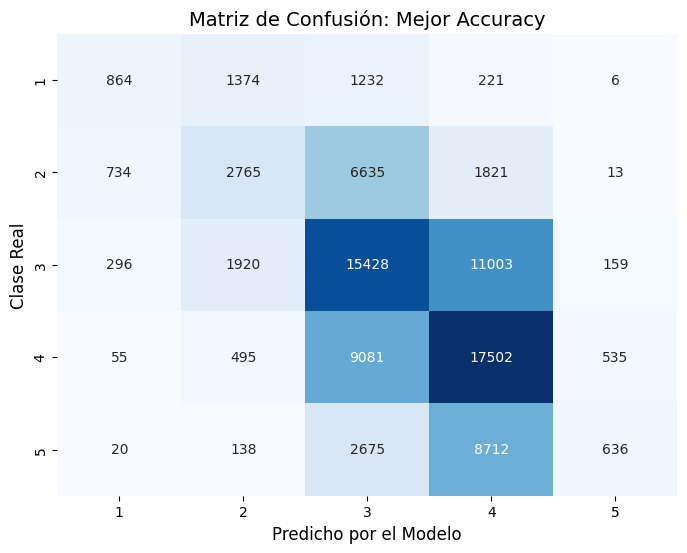

In [40]:
# EVALUACIÓN DEL MEJOR MODELO: ACCURACY

metrica = 'Accuracy'

# Extraemos los parámetros directamente del modelo ya entrenado
params = modelo_acc_3_1_1.get_params()
print(f"Mejor modelo según: {metrica}")
print(f"Parámetros: Profundidad={params['max_depth']} | Hojas={params['min_samples_leaf']} | Peso={params['class_weight']}\n")

# Predicciones directas (sin reentrenar)
y_pred_acc = modelo_acc_3_1_1.predict(X_val)

# Reporte de clasificación
print("Reporte de Clasificación:")
print(classification_report(y_val, y_pred_acc, zero_division=0))

# Matriz de Confusión
cm = confusion_matrix(y_val, y_pred_acc)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', cbar=False,
            xticklabels=[1, 2, 3, 4, 5],
            yticklabels=[1, 2, 3, 4, 5])

plt.title(f'Matriz de Confusión: Mejor {metrica}', fontsize=14)
plt.xlabel('Predicho por el Modelo', fontsize=12)
plt.ylabel('Clase Real', fontsize=12)
plt.show()

Este primer modelo de árbol de decisión, seleccionado por alcanzar la mayor precisión global ($Accuracy = 0.4390$). Presenta un comportamiento marcadamente sesgado hacia las categorías con mayor representación. Aunque muestra una capacidad aceptable para identificar los niveles intermedios de salud, con valores de $recall$ de $0.52$ para la clase $3$ y $0.63$ para la clase $4$, su rendimiento en los extremos es deficiente, especialmente en la clase $5$ (salud excelente), donde la sensibilidad cae drásticamente a $0.06$. La matriz de confusión confirma que el modelo tiende a clasificar erróneamente a los encuestados hacia las categorías mayoritarias, lo que sugiere que, si bien es el modelo con mejor tasa de acierto total, su utilidad práctica es limitada para distinguir con precisión los estados de salud más críticos o sobresalientes

Mejor modelo según: Recall_Macro
Parámetros: Profundidad=10 | Hojas=100 | Peso=balanced

Reporte de Clasificación:
              precision    recall  f1-score   support

         1.0       0.25      0.64      0.36      3697
         2.0       0.26      0.35      0.30     11968
         3.0       0.45      0.22      0.30     28806
         4.0       0.44      0.28      0.35     27668
         5.0       0.27      0.60      0.38     12181

    accuracy                           0.33     84320
   macro avg       0.33      0.42      0.33     84320
weighted avg       0.39      0.33      0.33     84320



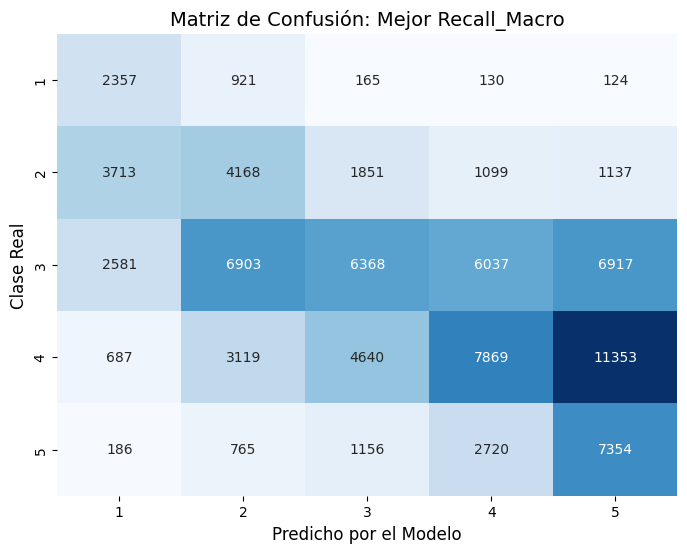

In [41]:
# EVALUACIÓN DEL MEJOR MODELO: RECALL MACRO

metrica = 'Recall_Macro'

params = modelo_recall_3_1_1.get_params()
print(f"Mejor modelo según: {metrica}")
print(f"Parámetros: Profundidad={params['max_depth']} | Hojas={params['min_samples_leaf']} | Peso={params['class_weight']}\n")

y_pred_recall = modelo_recall_3_1_1.predict(X_val)

print("Reporte de Clasificación:")
print(classification_report(y_val, y_pred_recall, zero_division=0))

cm = confusion_matrix(y_val, y_pred_recall)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', cbar=False,
            xticklabels=[1, 2, 3, 4, 5],
            yticklabels=[1, 2, 3, 4, 5])

plt.title(f'Matriz de Confusión: Mejor {metrica}', fontsize=14)
plt.xlabel('Predicho por el Modelo', fontsize=12)
plt.ylabel('Clase Real', fontsize=12)
plt.show()

Este segundo modelo, seleccionado bajo el criterio de $Recall$ $Macro$ ($0.4202$) utiliza pesos balanceados y prioriza la detección de las categorías en los extremos de la escala. A diferencia del modelo anterior, este logra capturar significativamente mejor los estados de salud "1" (peor) y "5" (excelente), alcanzando una sensibilidad ($recall$) de $0.64$ en ambos casos. No obstante, este equilibrio penaliza la precisión global ($Accuracy = 0.33$), ya que el modelo tiende a "arriesgarse" más al clasificar, lo que genera un mayor solapamiento y falsos positivos en las categorías centrales ($3$ y $4$). En conclusión, es un modelo mucho más sensible a las minorías y útil para identificar casos críticos, aunque a costa de una menor exactitud general y una mayor confusión en los niveles de salud intermedios.

Mejor modelo según: F1_Macro
Parámetros: Profundidad=25 | Hojas=50 | Peso=None

Reporte de Clasificación:
              precision    recall  f1-score   support

         1.0       0.43      0.23      0.30      3697
         2.0       0.39      0.28      0.32     11968
         3.0       0.43      0.53      0.47     28806
         4.0       0.45      0.54      0.49     27668
         5.0       0.37      0.13      0.19     12181

    accuracy                           0.43     84320
   macro avg       0.41      0.34      0.36     84320
weighted avg       0.42      0.43      0.41     84320



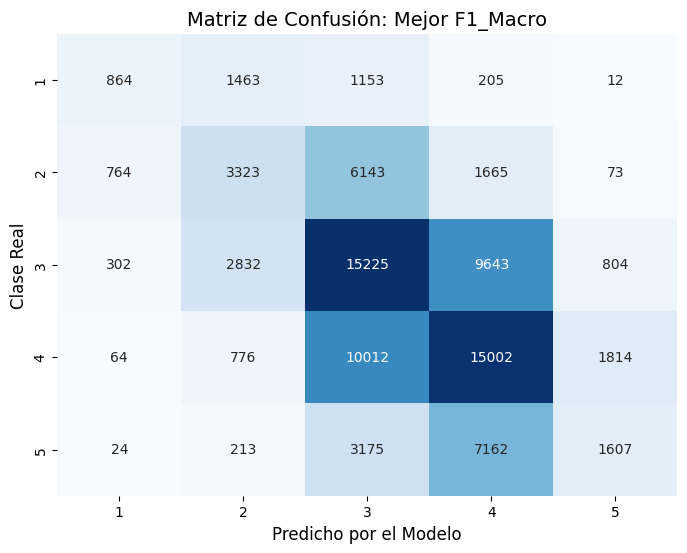

In [42]:
# EVALUACIÓN DEL MEJOR MODELO: F1 MACRO

metrica = 'F1_Macro'

params = modelo_f1_3_1_1.get_params()
print(f"Mejor modelo según: {metrica}")
print(f"Parámetros: Profundidad={params['max_depth']} | Hojas={params['min_samples_leaf']} | Peso={params['class_weight']}\n")

y_pred_f1 = modelo_f1_3_1_1.predict(X_val)

print("Reporte de Clasificación:")
print(classification_report(y_val, y_pred_f1, zero_division=0))

cm = confusion_matrix(y_val, y_pred_f1)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', cbar=False,
            xticklabels=[1, 2, 3, 4, 5],
            yticklabels=[1, 2, 3, 4, 5])

plt.title(f'Matriz de Confusión: Mejor {metrica}', fontsize=14)
plt.xlabel('Predicho por el Modelo', fontsize=12)
plt.ylabel('Clase Real', fontsize=12)
plt.show()

Este tercer modelo, seleccionado bajo el criterio de $F1\_Macro$ ($0.3592$), busca un compromiso técnico entre la precisión y la diversificación entre todas las categorías. Con una estructura más profunda (profundidad $= 25$, hojas $= 50$), este árbol logra una $Accuracy$ de $0.42$, situándose como un punto de equilibrio entre la especialización en las minorías del segundo modelo y la tendencia mayoritaria del primero. Aunque el rendimiento sigue siendo superior en los niveles intermedios ($3$ y $4$), se observa una mejora en la capacidad de discriminación de los extremos respecto al primer modelo, duplicando el $recall$ de la clase $5$ ($0.14$) y manteniendo una precisión más robusta en la clase $1$. En definitiva, se trata del modelo más balanceado, minimizando el impacto del desequilibrio de clases sin sacrificar drásticamente la capacidad predictiva global.

### 3.1.2 Logistic Regression

Vamos a tratar de mejorar los resultados obtenidos con los árboles de decisión mediante el sencillo modelo de la regresión logística. Entrenaremos 20 combinaciones de parámetros para ver cuál de ellas nos proporciona unos mejores resultados.

In [43]:
# SEGURO DE EJECUCIÓN

REENTRENAR = False  # Cambiar a False una vez para que no vuelva a entrenar

ruta_csv = os.path.join(results_path, 'resultados_3_1_2.csv')
ruta_f1 = os.path.join(results_path, '3_1_2_f1.pkl')
ruta_recall = os.path.join(results_path, '3_1_2_recall.pkl')
ruta_acc = os.path.join(results_path, '3_1_2_acc.pkl')

if not REENTRENAR and os.path.exists(ruta_csv):
    print("Cargando resultados desde el disco...")
    resultados_3_1_2 = pd.read_csv(ruta_csv)
    display(resultados_3_1_2.head(10))

    # Carga de los modelos entrenados
    modelo_f1_3_1_2 = joblib.load(ruta_f1)
    if os.path.exists(ruta_recall):
        modelo_recall_3_1_2 = joblib.load(ruta_recall)
    if os.path.exists(ruta_acc):
        modelo_acc_3_1_2 = joblib.load(ruta_acc)

else:
    # Definimos la cuadrícula de parámetros a probar
    param_grid = {
        'C': [0.01, 0.1, 1, 10, 100],  # Fuerza de la regularización (inversa)
        'solver': ['lbfgs', 'saga'],   # Algoritmos de optimización
        'class_weight': [None, 'balanced'],
        'max_iter': [1000]             # Fijo, suficientemente alto para que converja
    }

    # Creamos la lista de todas las combinaciones posibles (5*2*2*1 = 20 modelos)
    grid = ParameterGrid(param_grid)
    resultados_grid = []

    print(f"Comenzando el entrenamiento de {len(grid)} combinaciones de hiperparámetros.")

    mejor_f1_val = -1
    mejor_recall_val = -1
    mejor_acc_val = -1

    modelo_f1_3_1_2 = None
    modelo_recall_3_1_2 = None
    modelo_acc_3_1_2 = None

    # Bucle de entrenamiento y evaluación
    for i, params in enumerate(grid):
        if (i + 1) % 5 == 0:
            print(f"Entrenando modelo {i + 1} de {len(grid)}...")

        # Entrenamiento del modelo con la combinación actual (USAMOS DATOS ESCALADOS)
        log_reg = LogisticRegression(**params, random_state=42)
        log_reg.fit(X_train_scaled, y_train)

        # Predicciones en el conjunto de VALIDACIÓN (USAMOS DATOS ESCALADOS)
        y_pred_val = log_reg.predict(X_val_scaled)

        # Cálculo de métricas
        acc = accuracy_score(y_val, y_pred_val)
        f1_macro = f1_score(y_val, y_pred_val, average='macro', zero_division=0)
        prec_macro = precision_score(y_val, y_pred_val, average='macro', zero_division=0)
        recall_macro = recall_score(y_val, y_pred_val, average='macro', zero_division=0)

        # Captura de los mejores modelos en memoria
        if f1_macro > mejor_f1_val:
            mejor_f1_val = f1_macro
            modelo_f1_3_1_2 = log_reg

        if recall_macro > mejor_recall_val:
            mejor_recall_val = recall_macro
            modelo_recall_3_1_2 = log_reg

        if acc > mejor_acc_val:
            mejor_acc_val = acc
            modelo_acc_3_1_2 = log_reg

        # Guardamos los resultados
        resultados_grid.append({
            'C': params['C'],
            'solver': params['solver'],
            'class_weight': str(params['class_weight']),
            'max_iter': params['max_iter'],
            'Accuracy': acc,
            'Precision_Macro': prec_macro,
            'Recall_Macro': recall_macro,
            'F1_Macro': f1_macro
        })

    resultados_3_1_2 = pd.DataFrame(resultados_grid)

    # Ordenamos por F1_Macro de mayor a menor
    resultados_3_1_2 = resultados_3_1_2.sort_values(by='F1_Macro', ascending=False).reset_index(drop=True)

    print("\nTOP 10 MEJORES MODELOS (Ordenados por F1-Macro)")
    display(resultados_3_1_2.head(10))

    # Guardar la tabla de resultados
    resultados_3_1_2.to_csv(ruta_csv, index=False)

    # Guardar siempre el mejor por F1
    joblib.dump(modelo_f1_3_1_2, ruta_f1)
    print(f"'3_1_2_f1.pkl' guardado (F1: {mejor_f1_val:.4f})")

    # Guardar el mejor por Recall (solo si es diferente al de F1)
    if modelo_recall_3_1_2 is not modelo_f1_3_1_2:
        joblib.dump(modelo_recall_3_1_2, ruta_recall)
        print(f"'3_1_2_recall.pkl' guardado (Recall: {mejor_recall_val:.4f})")
    else:
        print("El modelo por Recall coincide con F1. No se duplica.")

    # Guardar el mejor por Accuracy (solo si es diferente a los dos anteriores)
    if modelo_acc_3_1_2 not in [modelo_f1_3_1_2, modelo_recall_3_1_2]:
        joblib.dump(modelo_acc_3_1_2, ruta_acc)
        print(f"'3_1_2_acc.pkl' guardado (Accuracy: {mejor_acc_val:.4f})")
    else:
        print("El modelo por Accuracy coincide con uno anterior. No se duplica.")

Cargando resultados desde el disco...


,C,solver,class_weight,max_iter,Accuracy,Precision_Macro,Recall_Macro,F1_Macro
0,0.10,saga,balanced,1000,0.361634,0.359892,0.440620,0.362146
1,1.00,saga,balanced,1000,0.361587,0.359817,0.440544,0.362107
2,0.01,saga,balanced,1000,0.361611,0.360031,0.440486,0.362092
3,0.01,lbfgs,balanced,1000,0.361587,0.359957,0.440557,0.362092
4,100.00,saga,balanced,1000,0.361575,0.359797,0.440490,0.362082
5,10.00,saga,balanced,1000,0.361575,0.359797,0.440490,0.362082
6,1.00,lbfgs,balanced,1000,0.361575,0.359810,0.440449,0.362079
7,0.10,lbfgs,balanced,1000,0.361611,0.359816,0.440408,0.362073
8,10.00,lbfgs,balanced,1000,0.361611,0.359804,0.440408,0.362054
9,100.00,lbfgs,balanced,1000,0.361551,0.359785,0.440371,0.362026


Veamos de nuevo con detalle los resultados de los mejores modelos según cada una de las métricas.

Mejor modelo según: Accuracy
Parámetros: C=100 | Solver=lbfgs | Peso=None

Reporte de Clasificación:
              precision    recall  f1-score   support

         1.0       0.51      0.23      0.32      3697
         2.0       0.44      0.25      0.32     11968
         3.0       0.45      0.54      0.49     28806
         4.0       0.46      0.67      0.55     27668
         5.0       0.35      0.04      0.07     12181

    accuracy                           0.45     84320
   macro avg       0.44      0.34      0.35     84320
weighted avg       0.44      0.45      0.42     84320



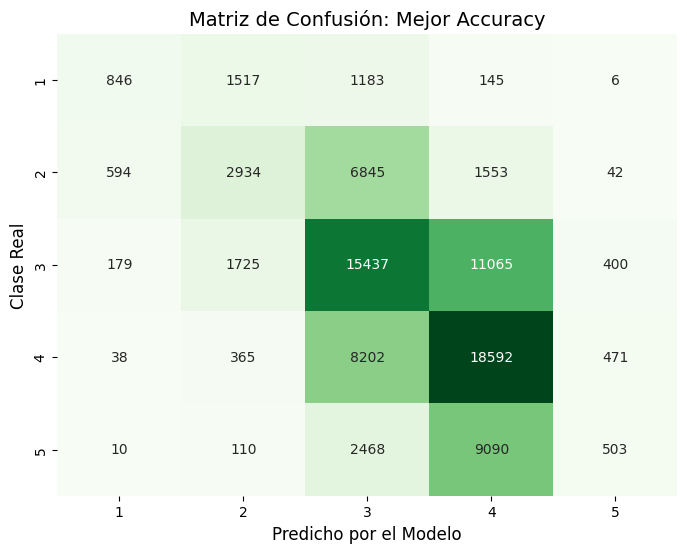

In [44]:
# EVALUACIÓN DEL MEJOR MODELO: ACCURACY

metrica = 'Accuracy'

# Extraemos los parámetros directamente del modelo ya entrenado
params = modelo_acc_3_1_2.get_params()
print(f"Mejor modelo según: {metrica}")
print(f"Parámetros: C={params['C']} | Solver={params['solver']} | Peso={params['class_weight']}\n")

# Predicciones directas (sin reentrenar, usando datos ESCALADOS)
y_pred_acc = modelo_acc_3_1_2.predict(X_val_scaled)

# Reporte de clasificación
print("Reporte de Clasificación:")
print(classification_report(y_val, y_pred_acc, zero_division=0))

# Matriz de Confusión
cm = confusion_matrix(y_val, y_pred_acc)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='g', cmap='Greens', cbar=False,
            xticklabels=[1, 2, 3, 4, 5],
            yticklabels=[1, 2, 3, 4, 5])

plt.title(f'Matriz de Confusión: Mejor {metrica}', fontsize=14)
plt.xlabel('Predicho por el Modelo', fontsize=12)
plt.ylabel('Clase Real', fontsize=12)
plt.show()

Este primer modelo de regresión logística, seleccionado por alcanzar la mayor precisión global ($Accuracy = 0.4544$) utilizando una penalización baja ($C=100.0$) y sin aplicar balanceo de clases, muestra un comportamiento predictivo fuertemente sesgado hacia las categorías mayoritarias. Su eficacia se concentra casi de manera exclusiva en los niveles de salud $3$ y $4$, donde logra sus mejores métricas de $recall$ ($0.54$ y $0.67$, respectivamente). Sin embargo, esta tendencia de clasificar con mayor acierto las clases más frecuentes hunde drásticamente la capacidad del modelo para identificar los extremos. El caso más crítico es el de la clase $5$ (salud excelente), con un $recall$ casi nulo ($0.04$), es decir del total de clase 5 solo se detecta el 4%. La matriz de confusión revela que la inmensa mayoría de estos son clasificados erróneamente como nivel $4$. En definitiva, al igual que el primer árbol de decisión, este modelo infla su tasa de acierto general a costa de ignorar a las minorías, resultando ineficaz para distinguir los estados de salud excepcionales.

Mejor modelo según: Recall_Macro / F1_Macro
Parámetros: C=0.1 | Solver=saga | Peso=balanced

Reporte de Clasificación:
              precision    recall  f1-score   support

         1.0       0.28      0.65      0.39      3697
         2.0       0.31      0.32      0.31     11968
         3.0       0.47      0.27      0.34     28806
         4.0       0.46      0.31      0.37     27668
         5.0       0.28      0.65      0.39     12181

    accuracy                           0.36     84320
   macro avg       0.36      0.44      0.36     84320
weighted avg       0.41      0.36      0.36     84320



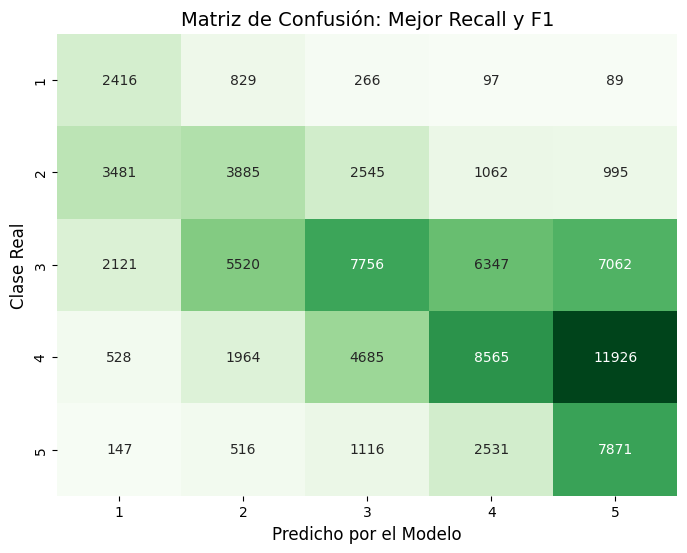

In [45]:
# EVALUACIÓN DEL MEJOR MODELO: RECALL Y F1 MACRO

metrica = 'Recall_Macro / F1_Macro'

# Usamos el modelo guardado por Recall (que sabemos que coincide con F1)
params = modelo_f1_3_1_2.get_params()
print(f"Mejor modelo según: {metrica}")
print(f"Parámetros: C={params['C']} | Solver={params['solver']} | Peso={params['class_weight']}\n")

# Predicciones directas usando datos ESCALADOS
y_pred_recall = modelo_f1_3_1_2.predict(X_val_scaled)

# Reporte de clasificación
print("Reporte de Clasificación:")
print(classification_report(y_val, y_pred_recall, zero_division=0))

# Matriz de Confusión
cm = confusion_matrix(y_val, y_pred_recall)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='g', cmap='Greens', cbar=False,
            xticklabels=[1, 2, 3, 4, 5],
            yticklabels=[1, 2, 3, 4, 5])

plt.title('Matriz de Confusión: Mejor Recall y F1', fontsize=14)
plt.xlabel('Predicho por el Modelo', fontsize=12)
plt.ylabel('Clase Real', fontsize=12)
plt.show()

Este segundo modelo de regresión logística, maximiza el $Recall$ $Macro$ ($0.4406$) y coincide con el seleccionado al maximizar también el $F1$ $Macro$ ($0.362146$). Gracias al balanceo de clases ($class\_weight=balanced$) y una mayor regularización ($C=0.1$), presenta un comportamiento opuesto al anterior y muy similar al del segundo árbol de decisión. Su principal fortaleza reside en la detección de los casos extremos, logrando identificar a la mayoría de los individuos en las clases $1$ y $5$ (ambas con un buen $recall$ de $0.65$). Sin embargo, este enfoque penaliza severamente el rendimiento general ($Accuracy = 0.36$), ya que el modelo asume un gran riesgo al predecir las minorías, generando un alto volumen de falsos positivos. La matriz de confusión muestra claramente cómo miles de encuestados con salud intermedia (clases $3$ y $4$) son clasificados erróneamente hacia los bordes de la escala. En conclusión, es una herramienta útil únicamente si el objetivo prioritario es no pasar por alto los estados de salud más críticos o excepcionales.

### 3.1.3 Support Vector Classifier (SVC)

Ahora probaremos el algoritmo SVC (Support Vector Classifier). Este tiene una complejidad computacional que escala de forma cuadrática o cúbica. Esto significa que si multiplicamos por 10 la cantidad de datos, el tiempo de entrenamiento no se multiplica por 10, sino por 100 o por 1.000.

Hacer un bucle con 20 combinaciones distintas sobre una 400.000 filas de entrenamiento es inviable. La solución que se tomará consiste en extraer una muestra (15.000 filas) del conjunto de entrenamiento y ejecutar el bucle sobre esa muestra.

Además, se reducirá el número de combinaciones de parámetros (solo probaremos 6 combinaciones en lugar de 24).

In [46]:
# SEGURO DE EJECUCIÓN

REENTRENAR = False  # Cambiar a False una vez para que no vuelva a entrenar

ruta_csv = os.path.join(results_path, 'resultados_3_1_3.csv')
ruta_f1 = os.path.join(results_path, '3_1_3_f1.pkl')
ruta_recall = os.path.join(results_path, '3_1_3_recall.pkl')
ruta_acc = os.path.join(results_path, '3_1_3_acc.pkl')

if not REENTRENAR and os.path.exists(ruta_csv):
    print("Cargando resultados desde el disco...")
    resultados_3_1_3 = pd.read_csv(ruta_csv)
    display(resultados_3_1_3.head(10))

    # Carga de los modelos entrenados
    modelo_f1_3_1_3 = joblib.load(ruta_f1)
    if os.path.exists(ruta_recall):
        modelo_recall_3_1_3 = joblib.load(ruta_recall)
    if os.path.exists(ruta_acc):
        modelo_acc_3_1_3 = joblib.load(ruta_acc)

else:
    # Tomamos solo 15.000 datos del conjunto de entrenamiento escalado para SVM
    # Lo hacemos aquí para no gastar memoria si los modelos ya están cargados
    X_train_svm, _, y_train_svm, _ = train_test_split(
        X_train_scaled, y_train, train_size=15000, random_state=42, stratify=y_train
    )

    # Definimos la cuadrícula de parámetros a probar
    param_grid = {
        'C': [0.1, 1, 10],            # Margen suave, normal y duro
        'class_weight': [None, 'balanced']
    }

    # Creamos la lista de todas las combinaciones posibles (3*2 = 6 modelos)
    grid = ParameterGrid(param_grid)
    resultados_grid = []

    print(f"Comenzando el entrenamiento de {len(grid)} combinaciones de hiperparámetros.")

    mejor_f1_val = -1
    mejor_recall_val = -1
    mejor_acc_val = -1

    modelo_f1_3_1_3 = None
    modelo_recall_3_1_3 = None
    modelo_acc_3_1_3 = None

    # Bucle de entrenamiento y evaluación
    for i, params in enumerate(grid):
        print(f"Entrenando modelo {i + 1} de {len(grid)}...")

        # Entrenamiento del modelo con la combinación actual (USAMOS DATOS ESCALADOS Y MUESTRA REDUCIDA)
        svm_model = SVC(**params, kernel='rbf', random_state=42)
        svm_model.fit(X_train_svm, y_train_svm)

        # Predicciones en el conjunto de VALIDACIÓN COMPLETO (DATOS ESCALADOS)
        y_pred_val = svm_model.predict(X_val_scaled)

        # Cálculo de métricas
        acc = accuracy_score(y_val, y_pred_val)
        f1_macro = f1_score(y_val, y_pred_val, average='macro', zero_division=0)
        prec_macro = precision_score(y_val, y_pred_val, average='macro', zero_division=0)
        recall_macro = recall_score(y_val, y_pred_val, average='macro', zero_division=0)

        # Captura de los mejores modelos en memoria
        if f1_macro > mejor_f1_val:
            mejor_f1_val = f1_macro
            modelo_f1_3_1_3 = svm_model

        if recall_macro > mejor_recall_val:
            mejor_recall_val = recall_macro
            modelo_recall_3_1_3 = svm_model

        if acc > mejor_acc_val:
            mejor_acc_val = acc
            modelo_acc_3_1_3 = svm_model

        # Guardamos los resultados
        resultados_grid.append({
            'C': params['C'],
            'class_weight': str(params['class_weight']),
            'Accuracy': acc,
            'Precision_Macro': prec_macro,
            'Recall_Macro': recall_macro,
            'F1_Macro': f1_macro
        })

    resultados_3_1_3 = pd.DataFrame(resultados_grid)

    # Ordenamos por F1_Macro de mayor a menor
    resultados_3_1_3 = resultados_3_1_3.sort_values(by='F1_Macro', ascending=False).reset_index(drop=True)

    print("\nTOP MEJORES MODELOS SVC (Ordenados por F1-Macro)")
    display(resultados_3_1_3)

    # Guardar la tabla de resultados
    resultados_3_1_3.to_csv(ruta_csv, index=False)

    # Guardar siempre el mejor por F1
    joblib.dump(modelo_f1_3_1_3, ruta_f1)
    print(f"'3_1_3_f1.pkl' guardado (F1: {mejor_f1_val:.4f})")

    # Guardar el mejor por Recall (solo si es diferente al de F1)
    if modelo_recall_3_1_3 is not modelo_f1_3_1_3:
        joblib.dump(modelo_recall_3_1_3, ruta_recall)
        print(f"'3_1_3_recall.pkl' guardado (Recall: {mejor_recall_val:.4f})")
    else:
        print("El modelo por Recall coincide con F1. No se duplica.")

    # Guardar el mejor por Accuracy (solo si es diferente a los dos anteriores)
    if modelo_acc_3_1_3 not in [modelo_f1_3_1_3, modelo_recall_3_1_3]:
        joblib.dump(modelo_acc_3_1_3, ruta_acc)
        print(f"'3_1_3_acc.pkl' guardado (Accuracy: {mejor_acc_val:.4f})")
    else:
        print("El modelo por Accuracy coincide con uno anterior. No se duplica.")

Cargando resultados desde el disco...


,C,class_weight,Accuracy,Precision_Macro,Recall_Macro,F1_Macro
0,1.0,balanced,0.371407,0.358497,0.402160,0.362599
1,0.1,balanced,0.349051,0.343383,0.434324,0.346199
2,10.0,balanced,0.367303,0.341926,0.358062,0.343277
3,10.0,NaN,0.412951,0.370755,0.338074,0.341845
4,1.0,NaN,0.439101,0.415740,0.312070,0.303327
5,0.1,NaN,0.433112,0.252060,0.268460,0.234158


De los 6 SVC entrenados nos quedamos únicamente con el modelo que maximiza el $F1$ $Macro$.

Mejor modelo según: F1_Macro
Parámetros: C=1 | Peso=balanced

Reporte de Clasificación:
              precision    recall  f1-score   support

         1.0       0.27      0.37      0.31      3697
         2.0       0.32      0.45      0.38     11968
         3.0       0.45      0.29      0.36     28806
         4.0       0.46      0.33      0.38     27668
         5.0       0.29      0.57      0.39     12181

    accuracy                           0.37     84320
   macro avg       0.36      0.40      0.36     84320
weighted avg       0.40      0.37      0.37     84320



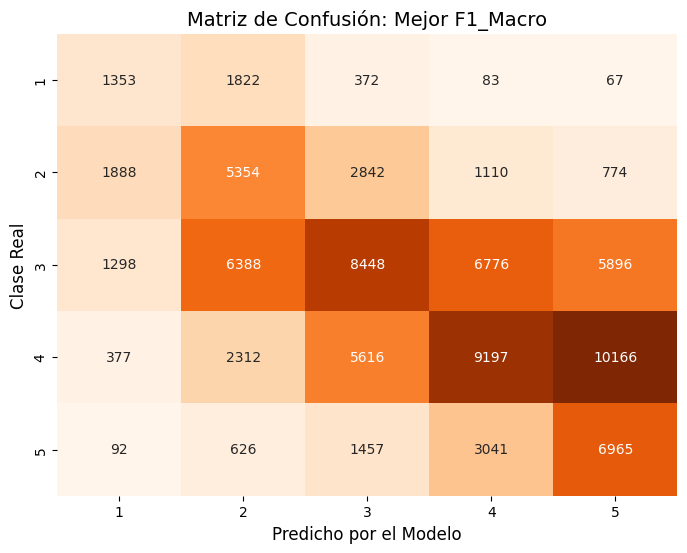

In [47]:
# EVALUACIÓN DEL MEJOR MODELO: F1 MACRO

metrica = 'F1_Macro'

# Extraemos los parámetros directamente del modelo ya entrenado
params = modelo_f1_3_1_3.get_params()
print(f"Mejor modelo según: {metrica}")
print(f"Parámetros: C={params['C']} | Peso={params['class_weight']}\n")

# Predicciones directas (sin reentrenar, usando datos ESCALADOS)
y_pred_f1 = modelo_f1_3_1_3.predict(X_val_scaled)

# Reporte de clasificación
print("Reporte de Clasificación:")
print(classification_report(y_val, y_pred_f1, zero_division=0))

# Matriz de Confusión
cm = confusion_matrix(y_val, y_pred_f1)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='g', cmap='Oranges', cbar=False,
            xticklabels=[1, 2, 3, 4, 5],
            yticklabels=[1, 2, 3, 4, 5])

plt.title(f'Matriz de Confusión: Mejor {metrica}', fontsize=14)
plt.xlabel('Predicho por el Modelo', fontsize=12)
plt.ylabel('Clase Real', fontsize=12)
plt.show()

Este único modelo de Máquinas de Vectores de Soporte (SVC) seleccionado por maximizar el F1 Macro (0.3626) utilizando pesos balanceados, representa el intento con mayor éxito de equilibrar el rendimiento a lo largo de todas las categorías. Su mayor logro es estabilizar los valores de F1-score por clase, manteniéndolos en una franja muy estrecha (entre 0.31 y 0.39), sin ignorar a las minorías. Sin embargo, este equilibrio se consigue a costa de sacrificar nuevamente la exactitud global (Accuracy = 0.37). Al observar la matriz de confusión y la métrica de recall, notamos que el modelo da visibilidad a las clases menos frecuentes, logrando identificar aceptablemente la clase 5 (recall de 0.57) y mejorando sustancialmente en la clase 2 (0.45). El gran inconveniente es que esto genera una enorme dispersión en las clases mayoritarias (3 y 4), donde miles de encuestados con niveles de salud intermedios son asignados erróneamente a los extremos de la escala. En definitiva, se trata del modelo más equitativo y estable de todos frente al desbalance de clases, pero es limitado en cuanto a la precisión general.

### Evaluación final

Tras una gran fase de ajuste de hiperparámetros en la que se han entrenado y evaluado un total de 50 configuraciones (24 Árboles de Decisión, 20 Regresiones Logísticas y 6 SVC), filtramos los mejores candidatos basándonos en sus métricas clave. Esto nos ha dejado con una lista corta de 6 modelos finalistas (3 Árboles, 2 Logísticas y 1 SVC).

De entre todos ellos, el modelo seleccionado como "Mejor modelo" es la Regresión Logística, configurada con los siguientes parámetros:

- C = 0.10
- solver = saga
- class_weight = balanced

La selección de este modelo se basa en tres pilares clave:

1. Sensibilidad Superior (Líder en Recall): Ha logrado el Recall Macro más alto de todos los modelos evaluados en el conjunto de validación.

2. Detección de Casos Extremos: Gracias al balanceo de pesos, el modelo asume el "riesgo" necesario para clasificar correctamente a las minorías. En lugar de apostar siempre de forma conservadora por las clases centrales (salud regular/buena), demuestra una buena capacidad para identificar a los individuos en los extremos: aquellos con mala salud (clase 1) y salud excelente (clase 5).

3. Equilibrio: Su métrica de equilibrio global (F1-Macro) es prácticamente idéntica a la del modelo más potente (el SVC). Ante un empate en rendimiento, preferimos la simplicidad algorítmica: la Regresión Logística es un modelo mucho más ligero, transparente y sencillo que un SVC.

A continuación se muestran las diferentes métricas obtenidas para este modelo en el conjunto de test.


RESULTADOS FINALES EN EL CONJUNTO DE TEST
Accuracy General : 0.3645
F1-Macro         : 0.3661
Recall-Macro     : 0.4443

Reporte de Clasificación:
              precision    recall  f1-score   support

         1.0       0.28      0.66      0.40      1849
         2.0       0.32      0.34      0.33      5984
         3.0       0.47      0.27      0.34     14403
         4.0       0.47      0.32      0.38     13835
         5.0       0.28      0.63      0.39      6090

    accuracy                           0.36     42161
   macro avg       0.36      0.44      0.37     42161
weighted avg       0.41      0.36      0.36     42161



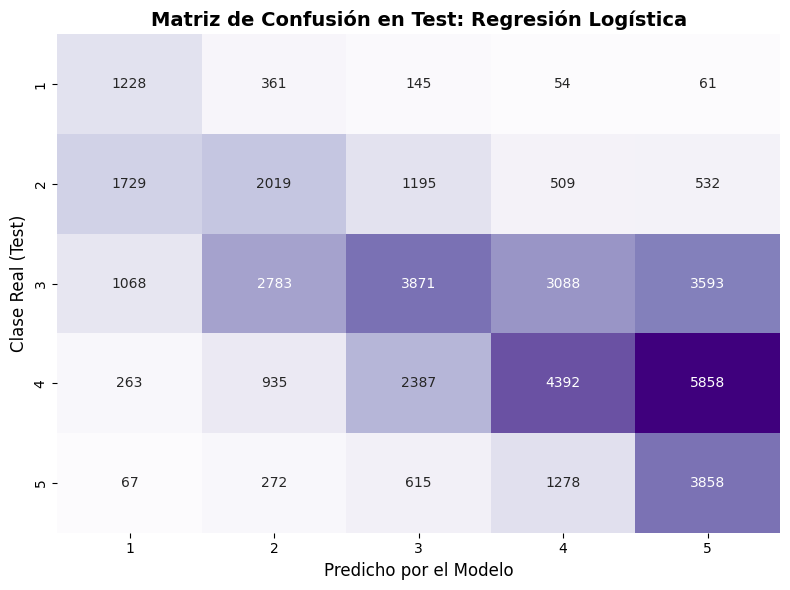

In [48]:
# EVALUACIÓN EN TEST

# Cargamos el modelo ganador directamente desde el disco
ruta_modelo_3_1_f1 = os.path.join(results_path, '3_1_2_f1.pkl')
modelo_3_1_f1 = joblib.load(ruta_modelo_3_1_f1)

# Usamos X_test_scaled para Regresión Logística
y_pred_test_3_1_f1 = modelo_3_1_f1.predict(X_test_scaled)

# Cálculo de métricas
acc_test = accuracy_score(y_test, y_pred_test_3_1_f1)
f1_test = f1_score(y_test, y_pred_test_3_1_f1, average='macro', zero_division=0)
recall_test = recall_score(y_test, y_pred_test_3_1_f1, average='macro', zero_division=0)

print("\nRESULTADOS FINALES EN EL CONJUNTO DE TEST")
print(f"Accuracy General : {acc_test:.4f}")
print(f"F1-Macro         : {f1_test:.4f}")
print(f"Recall-Macro     : {recall_test:.4f}\n")

# Reporte de Clasificación Final
print("Reporte de Clasificación:")
print(classification_report(y_test, y_pred_test_3_1_f1, zero_division=0))

# Matriz de Confusión Final
cm_test = confusion_matrix(y_test, y_pred_test_3_1_f1)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_test, annot=True, fmt='g', cmap='Purples', cbar=False,
            xticklabels=[1, 2, 3, 4, 5],
            yticklabels=[1, 2, 3, 4, 5])

plt.title('Matriz de Confusión en Test: Regresión Logística', fontsize=14, fontweight='bold')
plt.xlabel('Predicho por el Modelo', fontsize=12)
plt.ylabel('Clase Real (Test)', fontsize=12)
plt.tight_layout()
plt.show()

El modelo generaliza de manera excelente ante datos no vistos, replicando el *accuracy* global (0.36) y el comportamiento de las métricas en todas las categorías. El algoritmo sigue demostrando su alta sensibilidad hacia los extremos (manteniendo un recall muy bueno de 0.66 para la clase 1 y 0.63 para la clase 5), a costa de sufrir la misma confusión en los niveles intermedios.

Mostramos por último un gráfico que represente la importancia de las variables en el modelo seleccionado.

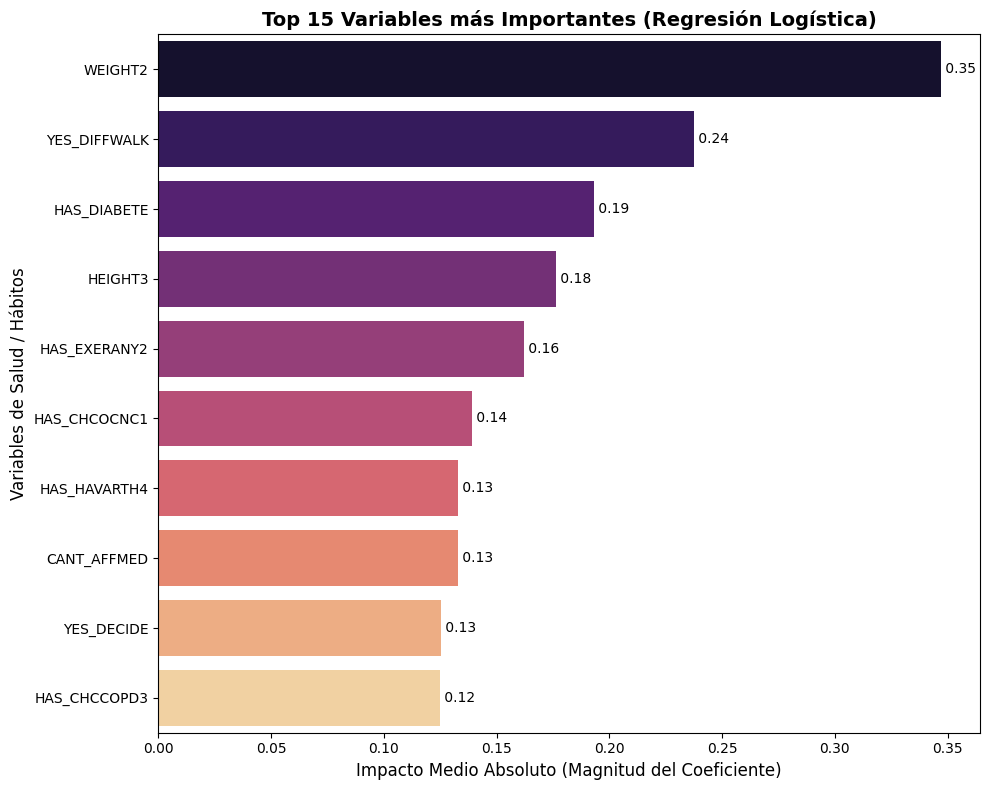

In [49]:
# Como es multiclase, coef_ es una matriz. Tomamos la media del valor absoluto por cada columna (variable)
importancias_globales = np.mean(np.abs(modelo_3_1_f1.coef_), axis=0)

nombres_variables = X_train.columns

df_importancias = pd.DataFrame({
    'Variable': nombres_variables,
    'Importancia': importancias_globales
})

df_importancias = df_importancias.sort_values(by='Importancia', ascending=False)

# Gráfico
plt.figure(figsize=(10, 8))
sns.barplot(x='Importancia', y='Variable', data=df_importancias.head(10), palette='magma', hue='Variable')

# Títulos y etiquetas
plt.title('Top 15 Variables más Importantes (Regresión Logística)', fontsize=14, fontweight='bold')
plt.xlabel('Impacto Medio Absoluto (Magnitud del Coeficiente)', fontsize=12)
plt.ylabel('Variables de Salud / Hábitos', fontsize=12)

# Añadir los valores exactos al final de cada barra
for index, value in enumerate(df_importancias.head(10)['Importancia']):
    plt.text(value, index, f' {value:.2f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

Al ser un modelo de Regresión Logística multiclase, el algoritmo genera una ecuación matemática para cada nivel de salud y le asigna un peso a cada factor.

Puesto que algunas variables empujan la predicción hacia "Mejor Salud" (coeficientes positivos) y otras hacia "Peor Salud" (coeficientes negativos). Al calcular el valor absoluto, eliminamos el signo para medir únicamente la magnitud con la que esa variable altera la decisión final, independientemente de la dirección. Al tener 5 clases de salud, el modelo calcula 5 pesos distintos para cada variable. El valor que vemos en el gráfico es el promedio de esos 5 pesos, dándonos una visión global de su importancia en todo el sistema.

En este modelo de regresión logística es fundamental recordar que nuestros datos pasaron por un proceso de estandarización previo. Por lo tanto, el modelo no está leyendo "kilos" o "años", sino desviaciones estándar (cuánto se aleja un paciente de la media poblacional).

- El Peso Corporal (`WEIGHT2` - 0.35): Es, con gran diferencia, el factor más determinante de todo el estudio. Si calculamos su impacto real ($e^{0.35} \approx 1.42$), esto significa que si un paciente experimenta un aumento o descenso de peso equivalente a una desviación estándar respecto a la media, las probabilidades relativas de que el algoritmo lo cambie a otra categoría de salud aumentan en un 42%.

- Movilidad y Cronicidad (`YES_DIFFWALK` - 0.24 y `HAS_DIABETE` - 0.19): Las siguientes variables más críticas están directamente ligadas a la pérdida de calidad de vida. Tener serias dificultades para caminar o subir escaleras, seguido de un diagnóstico de diabetes, alteran profundamente la clasificación del modelo, aumentando las probabilidades de cambio de categoría en un 27% y un 21%, respectivamente.

- Constitución y Hábitos (`HEIGHT3` - 0.18 y `HAS_EXERANY2` - 0.16): Cierran el top 5 la altura del individuo y el hecho de haber realizado actividad física o ejercicio en el último mes.

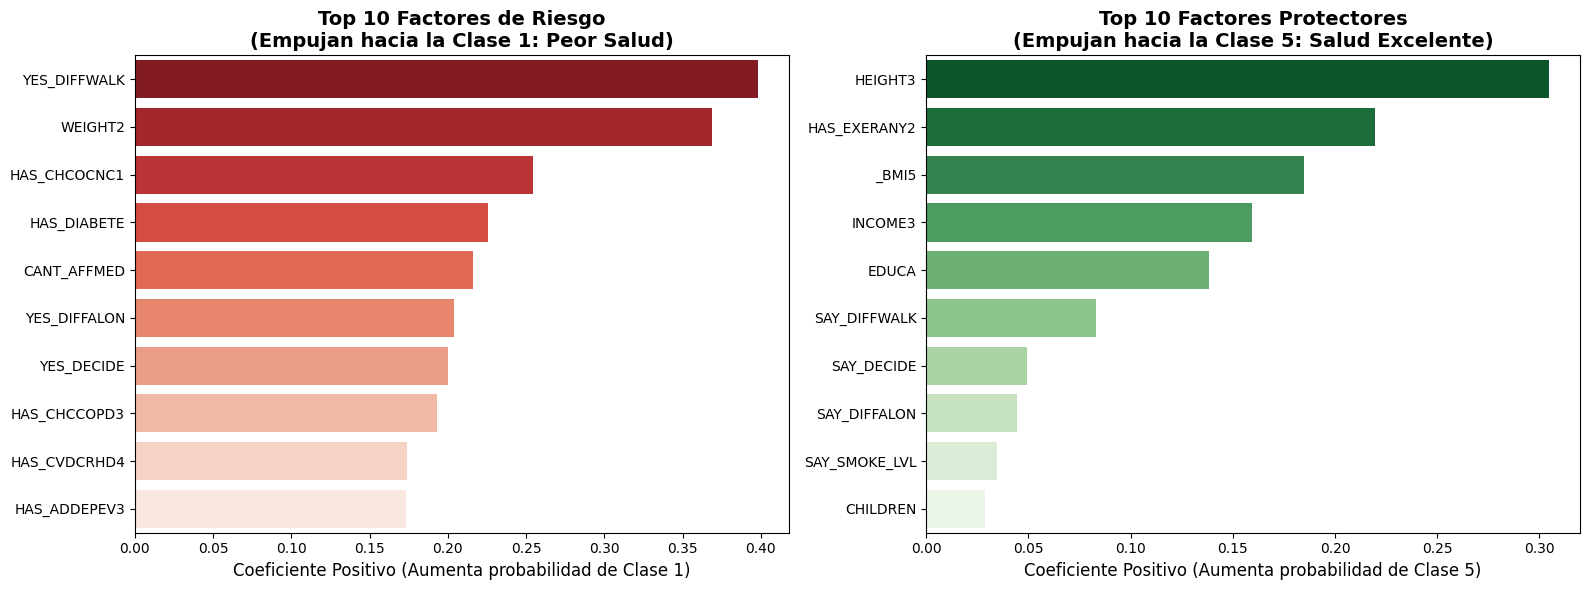

In [50]:
# Extraemos los coeficientes (sin valor absoluto)
# Índice 0 corresponde a la Clase 1 (Peor Salud)
# Índice 4 corresponde a la Clase 5 (Mejor Salud)
coef_clase1 = modelo_3_1_f1.coef_[0]
coef_clase5 = modelo_3_1_f1.coef_[4]
nombres_variables = X_train.columns

# Creamos DataFrames para cada extremo
df_peor_salud = pd.DataFrame({'Variable': nombres_variables, 'Impacto': coef_clase1})
df_mejor_salud = pd.DataFrame({'Variable': nombres_variables, 'Impacto': coef_clase5})

top_impulsores_peor = df_peor_salud.sort_values(by='Impacto', ascending=False).head(10)
top_impulsores_mejor = df_mejor_salud.sort_values(by='Impacto', ascending=False).head(10)

# Gráfico doble
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Impulsores de la Peor Salud (Clase 1)
sns.barplot(x='Impacto', y='Variable', data=top_impulsores_peor, ax=axes[0], palette='Reds_r', hue='Variable', legend=False)
axes[0].set_title('Top 10 Factores de Riesgo\n(Empujan hacia la Clase 1: Peor Salud)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Coeficiente Positivo (Aumenta probabilidad de Clase 1)', fontsize=12)
axes[0].set_ylabel('')

# Impulsores de la Mejor Salud (Clase 5)
sns.barplot(x='Impacto', y='Variable', data=top_impulsores_mejor, ax=axes[1], palette='Greens_r', hue='Variable', legend=False)
axes[1].set_title('Top 10 Factores Protectores\n(Empujan hacia la Clase 5: Salud Excelente)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Coeficiente Positivo (Aumenta probabilidad de Clase 5)', fontsize=12)
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

Al desglosar los coeficientes de la Regresión Logística (sin aplicar el valor absoluto), el algoritmo nos permite analizar las ecuaciones individuales. Se han aislado los coeficientes positivos más altos de la Clase 1 (Peor Salud) y de la Clase 5 (Mejor Salud). Al no aplicar el valor absoluto, medimos específicamente qué factores influyen en el modelo para detectar la mala salud y cuáles actúan como barreras protectoras hacia una salud excelente.

- Top 3 Factores de Riesgo (Empujan hacia la Peor Salud - Clase 1):

  - Movilidad Reducida (YES_DIFFWALK - 0.40): Es el factor de riesgo más determinante en este extremo. Si calculamos su impacto real ($e^{0.40} \approx 1.49$), esto significa que un aumento de una desviación estándar en las dificultades para caminar o subir escaleras dispara las probabilidades relativas de que el algoritmo asigne al paciente la peor categoría de salud en un 49%.
  
  - El Peso Corporal (WEIGHT2 - 0.37): Un incremento equivalente a una desviación estándar en el peso de un individuo aumenta las probabilidades relativas de pertenecer a la Clase 1 en un 45% ($e^{0.37} \approx 1.45$).
  
  - Historial Oncológico (HAS_CHCOCNC1 - 0.25): La presencia de diagnósticos de cáncer se revela como el tercer gran detonante. Padecerlo altera profundamente la predicción, incrementando las probabilidades de ser clasificado con la peor salud en un 28% ($e^{0.25} \approx 1.28$).
  
- Top 3 Factores Protectores (Empujan hacia la Mejor Salud - Clase 5):

  - Constitución Física (HEIGHT3 - 0.30): Es la barrera protectora más fuerte en el modelo para esta clase. Un incremento equivalente a una desviación estándar en la altura del individuo eleva las probabilidades relativas de alcanzar la máxima categoría de salud en un 35% ($e^{0.30} \approx 1.35$).
  
  - Actividad Física (HAS_EXERANY2 - 0.22): El ejercicio regular se confirma como un pilar fundamental del bienestar. Haber realizado actividad física en el último mes altera la predicción de forma muy positiva, incrementando las probabilidades de ser clasificado con salud excelente en un 25% ($e^{0.22} \approx 1.25$).
  
  - Índice de Masa Corporal (_BMI5 - 0.18): Cierra el top 3 de los factores protectores el Índice de Masa Corporal. Un incremento de una desviación estándar en esta variable estructurada eleva las probabilidades relativas de pertenecer a la mejor categoría de salud en un 20% ($e^{0.18} \approx 1.20$). Que WEIGHT2 y _BMI5 aparezcan en extremos opuestos sugiere que el modelo capta una interacción compleja entre el peso bruto y su proporción respecto a la altura, destacando la importancia de tener en cuenta ambas métricas de forma conjunta.

Cabe también considerar un modelo que ha maximizado el *accuracy* general como ha sido el árbol de decisión con parámetros max_depth = 10, min_samples_leaf = 100:


RESULTADOS FINALES EN EL CONJUNTO DE TEST
Accuracy General : 0.4401
F1-Macro         : 0.3381
Recall-Macro     : 0.3362

Reporte de Clasificación:
              precision    recall  f1-score   support

         1.0       0.43      0.24      0.31      1849
         2.0       0.41      0.23      0.29      5984
         3.0       0.44      0.54      0.48     14403
         4.0       0.45      0.63      0.52     13835
         5.0       0.42      0.05      0.09      6090

    accuracy                           0.44     42161
   macro avg       0.43      0.34      0.34     42161
weighted avg       0.43      0.44      0.40     42161



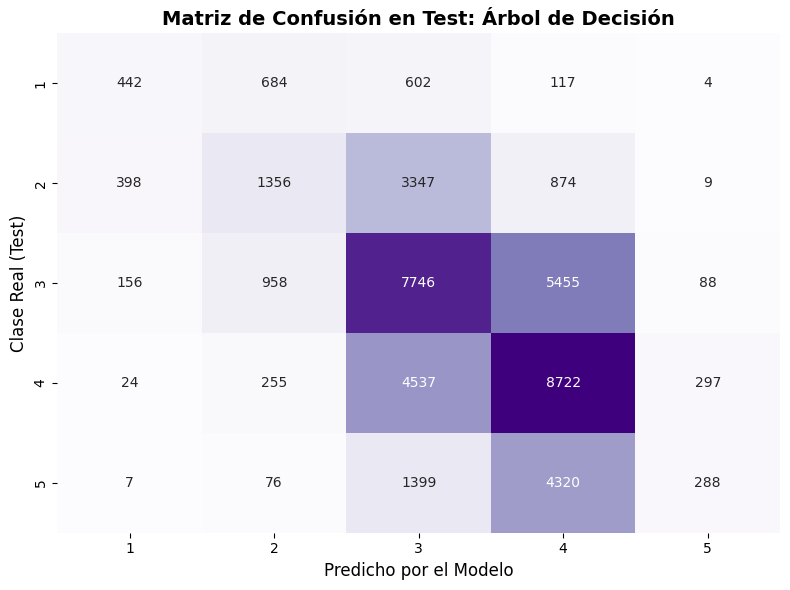

In [51]:
# EVALUACIÓN EN TEST: MEJOR MODELO ACCURACY (ÁRBOL DE DECISIÓN)

# Cargamos el modelo ganador directamente desde el disco
ruta_modelo_3_1_acc = os.path.join(results_path, '3_1_1_acc.pkl')
modelo_3_1_acc = joblib.load(ruta_modelo_3_1_acc)

# Usamos X_test (sin escalar) para Árboles de Decisión
y_pred_test_3_1_acc = modelo_3_1_acc.predict(X_test)

# Cálculo de métricas
acc_test = accuracy_score(y_test, y_pred_test_3_1_acc)
f1_test = f1_score(y_test, y_pred_test_3_1_acc, average='macro', zero_division=0)
recall_test = recall_score(y_test, y_pred_test_3_1_acc, average='macro', zero_division=0)

print("\nRESULTADOS FINALES EN EL CONJUNTO DE TEST")
print(f"Accuracy General : {acc_test:.4f}")
print(f"F1-Macro         : {f1_test:.4f}")
print(f"Recall-Macro     : {recall_test:.4f}\n")

# Reporte de Clasificación Final
print("Reporte de Clasificación:")
print(classification_report(y_test, y_pred_test_3_1_acc, zero_division=0))

# Matriz de Confusión Final
cm_test = confusion_matrix(y_test, y_pred_test_3_1_acc)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_test, annot=True, fmt='g', cmap='Purples', cbar=False,
            xticklabels=[1, 2, 3, 4, 5],
            yticklabels=[1, 2, 3, 4, 5])

plt.title('Matriz de Confusión en Test: Árbol de Decisión', fontsize=14, fontweight='bold')
plt.xlabel('Predicho por el Modelo', fontsize=12)
plt.ylabel('Clase Real (Test)', fontsize=12)
plt.tight_layout()
plt.show()

El modelo generaliza de manera excelente ante datos no vistos, replicando exactamente el accuracy global (0.44) y el comportamiento de las métricas en todas las categorías. Se mantiene el fuerte sesgo hacia los niveles centrales con un recall de 0.54 para la clase 3 y 0.63 para la clase 4, a costa de anular casi por completo las clases extremas, donde tiene un rendimiento pésimo con un recall de 0.05 para la clase 5.

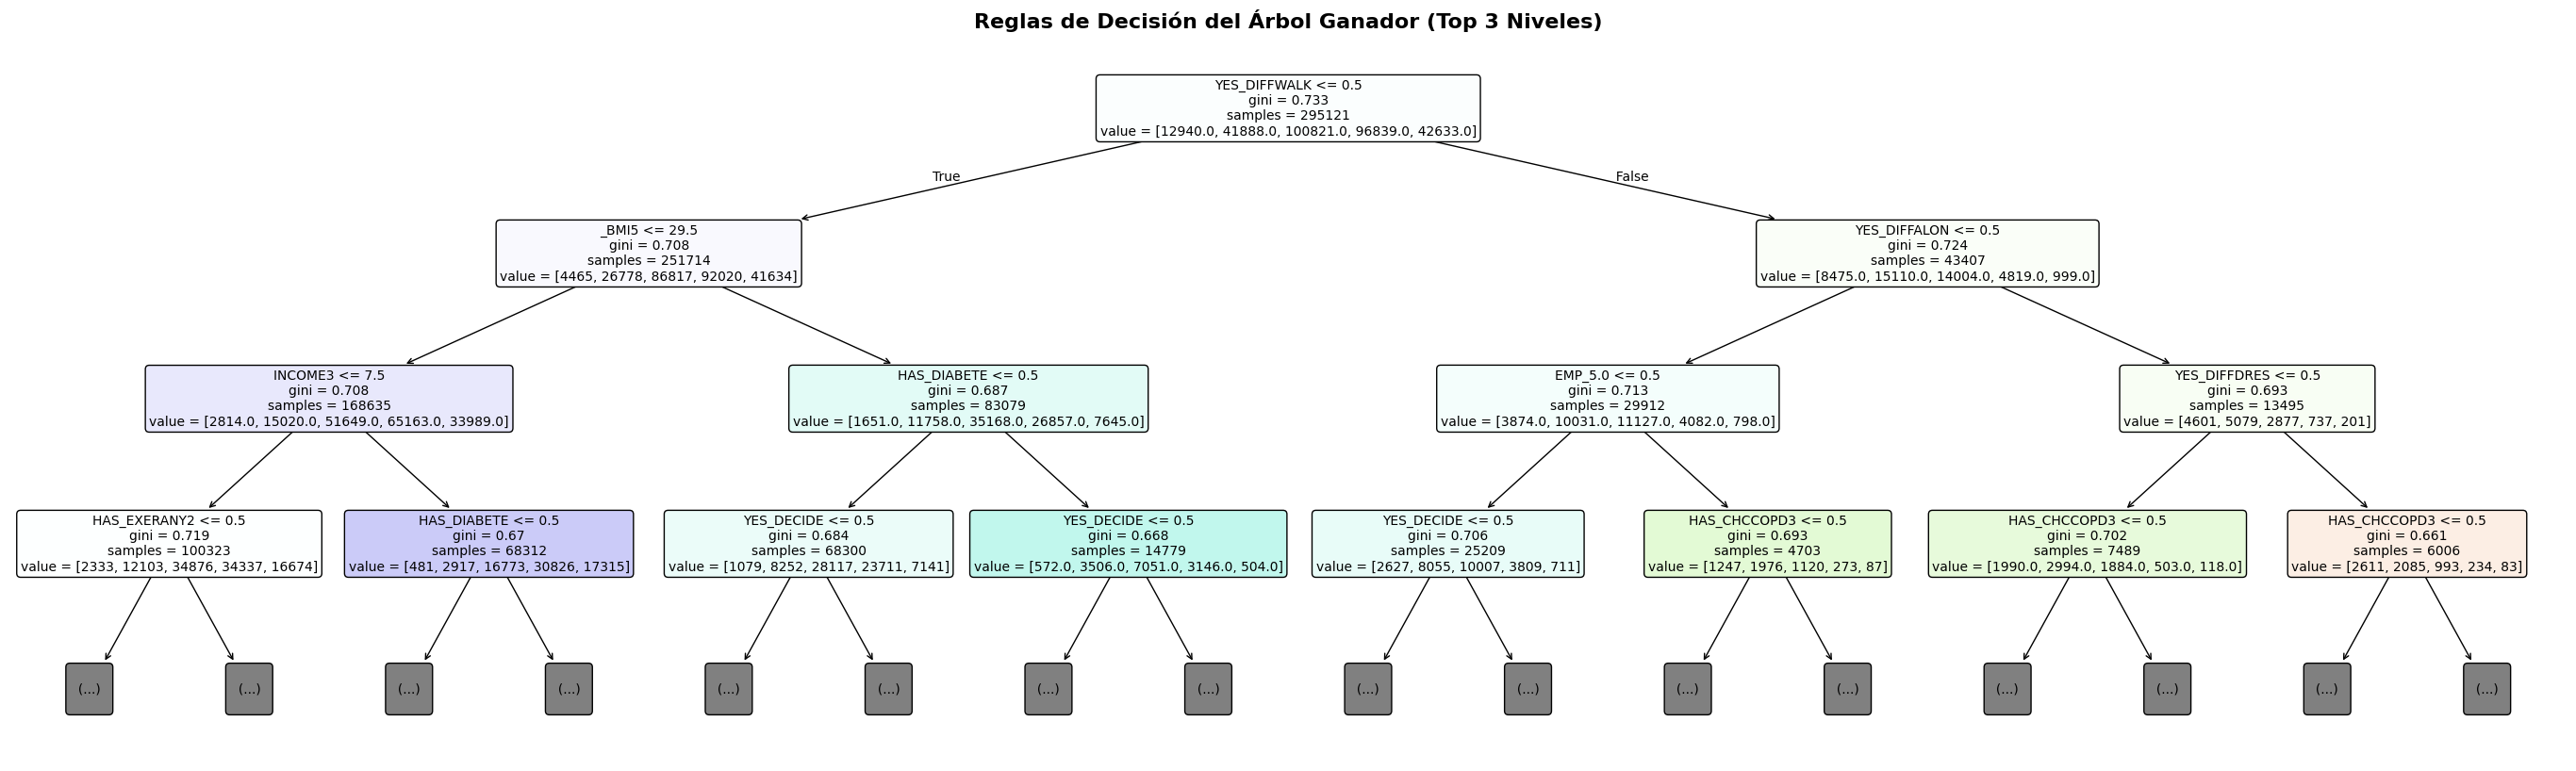

In [52]:
plt.figure(figsize=(35, 10))

# Dibujamos el árbol
plot_tree(modelo_3_1_acc,
          feature_names=X_train.columns,  # Nombres reales de las variables
          filled=True,                    # Colorea las cajas según el valor
          rounded=True,                   # Bordes redondeados
          max_depth=3,                    # Solo mostramos los 3 primeros niveles
          fontsize=10)

plt.title("Reglas de Decisión del Árbol Ganador (Top 3 Niveles)", fontsize=16, fontweight='bold')
plt.show()

Según el árbol de decisión ser independiente para caminar y para realizar movimientos es el factor más determinante para predecir el estado de salud general. La división principal (nodo raíz) clasifica a los encuestados según su dificultad para caminar (YES_DIFFWALK). Para el grupo sin problemas de movilidad (rama izquierda), el modelo afina la predicción evaluando el Índice de Masa Corporal (_BMI5 $\le 29.5$) y, posteriormente, factores socioeconómicos o crónicos (INCOME2, HAS_DIABETE). En contraste, para quienes sí presentan dificultad al caminar (rama derecha), el algoritmo profundiza en el grado de dependencia física, como la capacidad para hacer recados de forma autónoma (YES_DIFFALON) o la dificultad para vestirse (YES_DIFFDRES).

## 3.2 Regresión

En esta sección vamos a tratar de predecir el IMC de los individuos de la población. Para ello utilizaremos:

- Árboles de decisión para regresión
- Regresión lineal Ridge
- Support Vector Regressor (SVR)

Debemos tener en cuenta antes de realizar predicciones sobre esta variable que existen otras columnas directamente ligadas con el IMC como `WEIGHT2` y `HEIGHT3`.

En primer lugar tras excluir las variables mencionadas separamos el conjunto de datos en TRAIN (70%), VALIDACIÓN (20%) y TEST (10%).

In [53]:
# Eliminamos la variable objetivo y las que la calculan directamente
excluir_columnas = ['_BMI5', 'WEIGHT2', 'HEIGHT3']

X = data.drop(columns=[col for col in excluir_columnas if col in data.columns])
y = data['_BMI5']

# División 70/20/10
# Primero separamos el 70% para Train y el 30% restante para un conjunto temporal
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)

# Del 30% temporal, dividimos: 2/3 para Validación (20% del total) y 1/3 para Test (10% del total)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=1/3, random_state=42)

print(f"Distribución de datos:")
print(f"Entrenamiento (Train): {X_train.shape[0]} filas (70%)")
print(f"Validación (Val):      {X_val.shape[0]} filas (20%)")
print(f"Prueba (Test):         {X_test.shape[0]} filas (10%)")

# Escalado de características (Fit solo en Train, transform en el resto)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

Distribución de datos:
Entrenamiento (Train): 295121 filas (70%)
Validación (Val):      84320 filas (20%)
Prueba (Test):         42161 filas (10%)


Para el problema de regresión trataremos de:

- Maximizar el $R^2$ (porcentaje de varianza explicada)
- Minimizar el MAE (Error Absoluto Medio)
- Minimizar el RMSE (Raíz del Error Cuadrático Medio)

Entrenamos los modelos de regresión:

### 3.2.1 Decision Tree Regressor

Probamos 12 posibles combinaciones de parámetros para los árboles de regresión.

In [54]:
# SEGURO DE EJECUCIÓN

REENTRENAR = False  # Cambiar a False una vez para que no vuelva a entrenar

ruta_csv = os.path.join(results_path, 'resultados_3_2_1.csv')
ruta_r2 = os.path.join(results_path, '3_2_1_r2.pkl')
ruta_mae = os.path.join(results_path, '3_2_1_mae.pkl')
ruta_rmse = os.path.join(results_path, '3_2_1_rmse.pkl')

if not REENTRENAR and os.path.exists(ruta_csv):
    print("Cargando resultados desde el disco...")
    resultados_3_2_1 = pd.read_csv(ruta_csv)
    display(resultados_3_2_1.head(5))

    # Carga de los modelos entrenados
    modelo_r2_3_2_1 = joblib.load(ruta_r2)
    if os.path.exists(ruta_mae):
        modelo_mae_3_2_1 = joblib.load(ruta_mae)
    if os.path.exists(ruta_rmse):
        modelo_rmse_3_2_1 = joblib.load(ruta_rmse)

else:
    # Definimos la cuadrícula de parámetros a probar
    param_grid = {
        'max_depth': [5, 10, 20, 25],
        'min_samples_leaf': [10, 50, 100]
    }

    # Creamos la lista de todas las combinaciones posibles (4*3 = 12 modelos)
    grid = ParameterGrid(param_grid)
    resultados_grid = []

    print(f"Comenzando el entrenamiento de {len(grid)} combinaciones de hiperparámetros.")

    # R2 se maximiza, MAE y RMSE se minimizan
    mejor_r2_val = -float('inf')
    mejor_mae_val = float('inf')
    mejor_rmse_val = float('inf')

    modelo_r2_3_2_1 = None
    modelo_mae_3_2_1 = None
    modelo_rmse_3_2_1 = None

    # Bucle de entrenamiento y evaluación
    for i, params in enumerate(grid):
        if (i + 1) % 3 == 0:
            print(f"Entrenando modelo {i + 1} de {len(grid)}...")

        # Entrenamiento del modelo con la combinación actual
        dt = DecisionTreeRegressor(**params, random_state=42)
        dt.fit(X_train, y_train)

        # Predicciones en el conjunto de VALIDACIÓN
        y_pred_val = dt.predict(X_val)

        # Cálculo de métricas de REGRESIÓN
        r2 = r2_score(y_val, y_pred_val)
        mae = mean_absolute_error(y_val, y_pred_val)
        mse = mean_squared_error(y_val, y_pred_val)
        rmse = np.sqrt(mse)

        # Captura de los mejores modelos en memoria
        if r2 > mejor_r2_val:
            mejor_r2_val = r2
            modelo_r2_3_2_1 = dt

        if mae < mejor_mae_val:
            mejor_mae_val = mae
            modelo_mae_3_2_1 = dt

        if rmse < mejor_rmse_val:
            mejor_rmse_val = rmse
            modelo_rmse_3_2_1 = dt

        # Guardamos los resultados
        resultados_grid.append({
            'max_depth': params['max_depth'],
            'min_samples_leaf': params['min_samples_leaf'],
            'R2': r2,
            'MAE': mae,
            'RMSE': rmse
        })

    resultados_3_2_1 = pd.DataFrame(resultados_grid)

    # Ordenamos por R2 (Variación explicada) de MAYOR a MENOR
    resultados_3_2_1 = resultados_3_2_1.sort_values(by='R2', ascending=False).reset_index(drop=True)

    print("\nTOP 5 MEJORES MODELOS (Ordenados por R2)")
    display(resultados_3_2_1.head(5))

    # Guardar la tabla de resultados
    resultados_3_2_1.to_csv(ruta_csv, index=False)

    # Guardar siempre el mejor por R2
    joblib.dump(modelo_r2_3_2_1, ruta_r2)
    print(f"'3_2_1_r2.pkl' guardado (R2: {mejor_r2_val:.4f})")

    # Guardar el mejor por MAE (solo si es diferente al de R2)
    if modelo_mae_3_2_1 is not modelo_r2_3_2_1:
        joblib.dump(modelo_mae_3_2_1, ruta_mae)
        print(f"'3_2_1_mae.pkl' guardado (MAE: {mejor_mae_val:.4f})")
    else:
        print("El modelo por MAE coincide con R2. No se duplica.")

    # Guardar el mejor por RMSE (solo si es diferente a los dos anteriores)
    if modelo_rmse_3_2_1 not in [modelo_r2_3_2_1, modelo_mae_3_2_1]:
        joblib.dump(modelo_rmse_3_2_1, ruta_rmse)
        print(f"'3_2_1_rmse.pkl' guardado (RMSE: {mejor_rmse_val:.4f})")
    else:
        print("El modelo por RMSE coincide con uno anterior. No se duplica.")

Cargando resultados desde el disco...


,max_depth,min_samples_leaf,R2,MAE,RMSE
0,10,100,0.119858,4.336554,5.974794
1,10,50,0.118769,4.336895,5.978488
2,10,10,0.116440,4.339893,5.986384
3,20,100,0.116414,4.339867,5.986470
4,25,100,0.116224,4.340726,5.987114


El mismo modelo proporciona el óptimo en las 3 métricas.

Mejor modelo global (R2, MAE, RMSE)
Parámetros: Profundidad=10 | Hojas=100

Reporte de Métricas de Regresión:
R2   : 0.1199
MAE  : 4.3366
RMSE : 5.9748



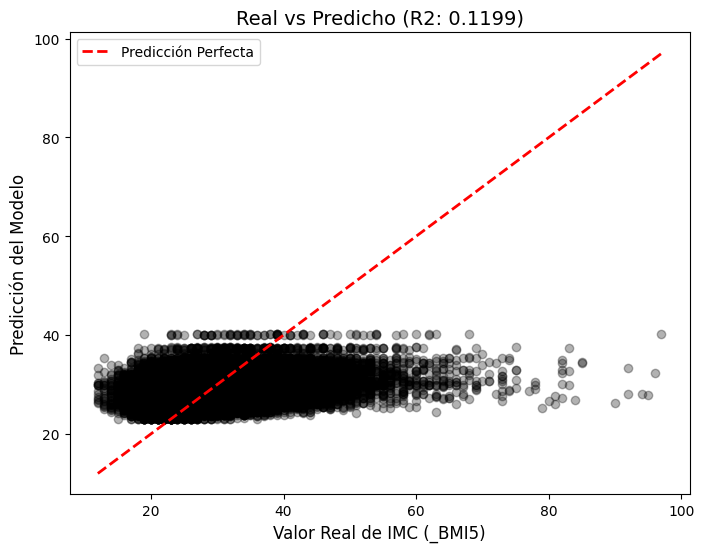

In [55]:
# EVALUACIÓN DEL MEJOR MODELO: R2 / MAE / RMSE

# Extraemos los parámetros directamente del modelo ya entrenado
params = modelo_r2_3_2_1.get_params()
print("Mejor modelo global (R2, MAE, RMSE)")
print(f"Parámetros: Profundidad={params['max_depth']} | Hojas={params['min_samples_leaf']}\n")

# Predicciones
y_pred_reg = modelo_r2_3_2_1.predict(X_val)

# Calculamos las métricas exactas
r2 = r2_score(y_val, y_pred_reg)
mae = mean_absolute_error(y_val, y_pred_reg)
rmse = np.sqrt(mean_squared_error(y_val, y_pred_reg))

print("Reporte de Métricas de Regresión:")
print(f"R2   : {r2:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}\n")

# Gráfico de Dispersión (Real vs Predicción)
plt.figure(figsize=(8, 6))
plt.scatter(y_val, y_pred_reg, alpha=0.3, color='black')

# Línea diagonal ideal (y = x)
min_val = min(y_val.min(), y_pred_reg.min())
max_val = max(y_val.max(), y_pred_reg.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Predicción Perfecta')

# Títulos y etiquetas
plt.title(f'Real vs Predicho (R2: {r2:.4f})', fontsize=14)
plt.xlabel('Valor Real de IMC (_BMI5)', fontsize=12)
plt.ylabel('Predicción del Modelo', fontsize=12)
plt.legend()
plt.show()

El mejor modelo según el $R^2$ es el que minimiza también el MAE y el RMSE, por lo que mantenemos este como el mejor árbol de decisión conseguido.

Aún así este modelo de árbol de decisión presenta un rendimiento general muy deficiente, evidenciado por un coeficiente de determinación ($R^2$) de apenas 0.1198. Como ilustra claramente el gráfico de dispersión, el modelo sufre de un severo problema de "regresión a la media": sus predicciones están fuertemente comprimidas en una estrecha franja entre los valores 22 y 40. Esto provoca que el modelo sobreestime el IMC de las personas con bajo peso y, de forma mucho más crítica, subestime drásticamente a los individuos con obesidad severa (valores reales por encima de 50 o 60). Con un error medio absoluto (MAE) de 4.33 y un RMSE de 5.97, la desviación es considerable. En conclusión, el árbol es incapaz de discriminar los casos extremos y se limita a realizar estimaciones conservadoras y planas en torno a los valores más frecuentes en la población.

La variable que más reduce el error cuadrático es `HEALTH` diferenciando entre los que tienen niveles 1, 2 y 3 de salud y los que tienen 4 y 5. En la segunda capa, para los individuos con una salud general por debajo de 3.5 lo que más influye es que tengan o no diabetes, mientras que para los que poseen una buena salud (4 o 5), la salud vuelve a ser un factor clave, diferenciando entre valores 4 y 5.

### 3.2.2 Regresión Lineal Ridge

Entrenamos la regresión lineal Ridge probando los parámetros $\alpha =  0.001, 0.01, 0.1, 1, 10, 50, 100, 500, 1000$

In [56]:
# SEGURO DE EJECUCIÓN

REENTRENAR = False  # Cambiar a False una vez para que no vuelva a entrenar

ruta_csv = os.path.join(results_path, 'resultados_3_2_2.csv')
ruta_r2 = os.path.join(results_path, '3_2_2_r2.pkl')
ruta_mae = os.path.join(results_path, '3_2_2_mae.pkl')
ruta_rmse = os.path.join(results_path, '3_2_2_rmse.pkl')

if not REENTRENAR and os.path.exists(ruta_csv):
    print("Cargando resultados desde el disco...")
    resultados_3_2_2 = pd.read_csv(ruta_csv)
    display(resultados_3_2_2)

    # Carga de los modelos entrenados
    modelo_r2_3_2_2 = joblib.load(ruta_r2)
    if os.path.exists(ruta_mae):
        modelo_mae_3_2_2 = joblib.load(ruta_mae)
    if os.path.exists(ruta_rmse):
        modelo_rmse_3_2_2 = joblib.load(ruta_rmse)

else:
    # Definimos la cuadrícula de parámetros (alpha controla la regularización)
    param_grid = {
        'alpha': [0.001, 0.01, 0.1, 1, 10, 50, 100, 500, 1000]
    }

    grid = ParameterGrid(param_grid)
    resultados_grid_lin = []

    print(f"Entrenando {len(grid)} combinaciones de Regresión Lineal (Ridge)...")

    mejor_r2_val = -float('inf')
    mejor_mae_val = float('inf')
    mejor_rmse_val = float('inf')

    modelo_r2_3_2_2 = None
    modelo_mae_3_2_2 = None
    modelo_rmse_3_2_2 = None

    for i, params in enumerate(grid):
        print(f"Entrenando modelo {i + 1} de {len(grid)}...")

        # Entrenamiento (USAMOS DATOS ESCALADOS)
        model_lin = Ridge(**params, random_state=42)
        model_lin.fit(X_train_scaled, y_train)

        # Predicción en Validación (USAMOS DATOS ESCALADOS)
        y_pred_val = model_lin.predict(X_val_scaled)

        # Métricas de REGRESIÓN
        r2 = r2_score(y_val, y_pred_val)
        mae = mean_absolute_error(y_val, y_pred_val)
        rmse = np.sqrt(mean_squared_error(y_val, y_pred_val))

        # Captura de los mejores modelos en memoria
        if r2 > mejor_r2_val:
            mejor_r2_val = r2
            modelo_r2_3_2_2 = model_lin

        if mae < mejor_mae_val:
            mejor_mae_val = mae
            modelo_mae_3_2_2 = model_lin

        if rmse < mejor_rmse_val:
            mejor_rmse_val = rmse
            modelo_rmse_3_2_2 = model_lin

        resultados_grid_lin.append({
            'alpha': params['alpha'],
            'R2': r2,
            'MAE': mae,
            'RMSE': rmse
        })

    resultados_3_2_2 = pd.DataFrame(resultados_grid_lin)

    # Ordenamos por R2 de mayor a menor
    resultados_3_2_2 = resultados_3_2_2.sort_values(by='R2', ascending=False).reset_index(drop=True)

    print("\nTOP MODELOS REGRESIÓN RIDGE (Ordenados por R2)")
    display(resultados_3_2_2)

    # GUARDADO DE RESULTADOS Y MODELOS
    print("\nGuardando resultados y mejores modelos...")

    # Guardar la tabla de resultados
    resultados_3_2_2.to_csv(ruta_csv, index=False)

    # Guardar siempre el mejor por R2
    joblib.dump(modelo_r2_3_2_2, ruta_r2)
    print(f"'3_2_2_r2.pkl' guardado (R2: {mejor_r2_val:.4f})")

    # Guardar el mejor por MAE (solo si es diferente al de R2)
    if modelo_mae_3_2_2 is not modelo_r2_3_2_2:
        joblib.dump(modelo_mae_3_2_2, ruta_mae)
        print(f"'3_2_2_mae.pkl' guardado (MAE: {mejor_mae_val:.4f})")
    else:
        print("El modelo por MAE coincide con R2. No se duplica.")

    # Guardar el mejor por RMSE (solo si es diferente a los dos anteriores)
    if modelo_rmse_3_2_2 not in [modelo_r2_3_2_2, modelo_mae_3_2_2]:
        joblib.dump(modelo_rmse_3_2_2, ruta_rmse)
        print(f"'3_2_2_rmse.pkl' guardado (RMSE: {mejor_rmse_val:.4f})")
    else:
        print("El modelo por RMSE coincide con uno anterior. No se duplica.")

Cargando resultados desde el disco...


,alpha,R2,MAE,RMSE
0,1000.000,0.110975,4.412331,6.004869
1,500.000,0.110972,4.412432,6.004877
2,100.000,0.110969,4.412515,6.004887
3,50.000,0.110969,4.412526,6.004888
4,10.000,0.110969,4.412534,6.004889
5,1.000,0.110969,4.412536,6.004889
6,0.100,0.110969,4.412536,6.004889
7,0.010,0.110969,4.412536,6.004889
8,0.001,0.110969,4.412536,6.004889


El mismo modelo proporciona el óptimo en las 3 métricas.

Mejor modelo global (R2, MAE, RMSE)
Parámetros: Alpha=1000

Reporte de Métricas de Regresión:
R2   : 0.1110
MAE  : 4.4123
RMSE : 6.0049



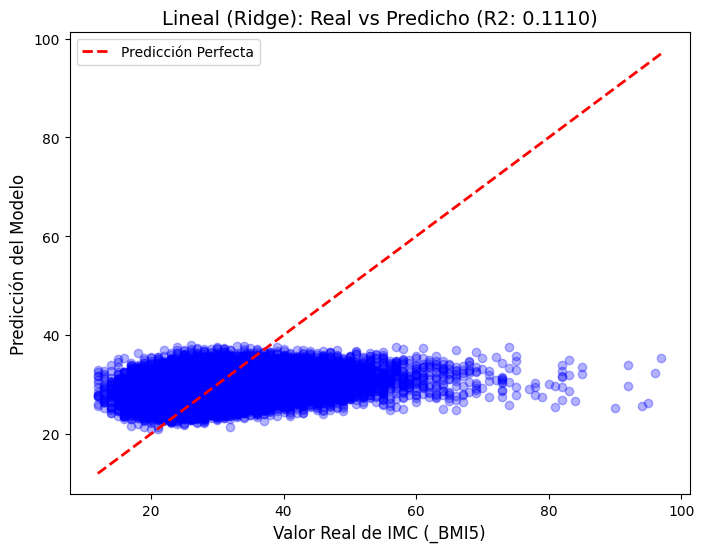

In [57]:
# EVALUACIÓN DEL MEJOR MODELO: R2 / MAE / RMSE (RIDGE)

# Extraemos los parámetros directamente del modelo ya entrenado
params = modelo_r2_3_2_2.get_params()
print("Mejor modelo global (R2, MAE, RMSE)")
print(f"Parámetros: Alpha={params['alpha']}\n")

# Predicciones
y_pred_reg_lin = modelo_r2_3_2_2.predict(X_val_scaled)

# Calculamos las métricas exactas
r2 = r2_score(y_val, y_pred_reg_lin)
mae = mean_absolute_error(y_val, y_pred_reg_lin)
rmse = np.sqrt(mean_squared_error(y_val, y_pred_reg_lin))

print("Reporte de Métricas de Regresión:")
print(f"R2   : {r2:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}\n")

# Gráfico de Dispersión (Real vs Predicción)
plt.figure(figsize=(8, 6))
plt.scatter(y_val, y_pred_reg_lin, alpha=0.3, color='blue')

# Línea diagonal ideal (y = x)
min_val = min(y_val.min(), y_pred_reg_lin.min())
max_val = max(y_val.max(), y_pred_reg_lin.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Predicción Perfecta')

# Títulos y etiquetas
plt.title(f'Lineal (Ridge): Real vs Predicho (R2: {r2:.4f})', fontsize=14)
plt.xlabel('Valor Real de IMC (_BMI5)', fontsize=12)
plt.ylabel('Predicción del Modelo', fontsize=12)
plt.legend()
plt.show()

Este modelo de regresión Ridge es el elegido si tenemos en cuenta los 3 criterios ($R^2$, MAE, RMSE). Optimizado con una fuerte penalización ($alpha = 1000$), proporciona resultados deficientes que incluso empeoran ligeramente, el ya mal desempeño del árbol de regresión anterior. Con un $R^2$ de $0.1110$, el modelo es incapaz de explicar apenas el 11% de la varianza del IMC. Como se observa en la gráfica, la nube de puntos azules, independientemente de si el paciente tiene infrapeso notable (IMC real $< 15$) o una obesidad extrema (IMC real $> 80$), el modelo se mantiene en una franja horizontal, prediciendo casi siempre un valor de IMC situado entre $22$ y $38$. Con un error medio absoluto ($MAE$) de $4.41$ y un $RMSE$ de $6.00$, esta regresión sufre de los mismos problemas ya comentados para el árbol de regresión.

### 3.2.3 Support Vector Regressor

Vamos a repetir la misma estrategia que usamos antes, es decir, extraeremos una muestra representativa de 15.000 pacientes del conjunto de entrenamiento para poder ajustar los parámetros sin que el modelo sea demasiado complejo de entrenar. En este caso probamos 9 combinaciones distintas de parámetros para el SVR.

In [58]:
# SEGURO DE EJECUCIÓN

REENTRENAR = False  # Cambiar a False una vez para que no vuelva a entrenar

ruta_csv = os.path.join(results_path, 'resultados_3_2_3.csv')
ruta_r2 = os.path.join(results_path, '3_2_3_r2.pkl')
ruta_mae = os.path.join(results_path, '3_2_3_mae.pkl')
ruta_rmse = os.path.join(results_path, '3_2_3_rmse.pkl')

if not REENTRENAR and os.path.exists(ruta_csv):
    print("Cargando resultados desde el disco...")
    resultados_3_2_3 = pd.read_csv(ruta_csv)
    display(resultados_3_2_3)

    # Carga de los modelos entrenados
    modelo_r2_3_2_3 = joblib.load(ruta_r2)
    if os.path.exists(ruta_mae):
        modelo_mae_3_2_3 = joblib.load(ruta_mae)
    if os.path.exists(ruta_rmse):
        modelo_rmse_3_2_3 = joblib.load(ruta_rmse)

else:
    # Cogemos solo 15.000 datos del conjunto de entrenamiento escalado
    # Lo hacemos aquí dentro para no gastar RAM innecesariamente si no reentrenamos
    X_train_svr, _, y_train_svr, _ = train_test_split(
        X_train_scaled, y_train, train_size=15000, random_state=42
    )

    print(f"Distribución Original:")
    print(f"Train: {X_train.shape[0]} | Val: {X_val.shape[0]} | Test: {X_test.shape[0]}\n")
    print(f"El SVR se entrenará sobre una sub-muestra de {X_train_svr.shape[0]} filas.\n")

    # Definimos una cuadrícula pequeña para SVR
    param_grid = {
        'C': [0.1, 1, 10],          # Fuerza de la regularización
        'epsilon': [0.1, 1.0, 2.0]  # Margen de error tolerado sin penalización
    }

    grid = ParameterGrid(param_grid)
    resultados_grid_svr = []

    print(f"Entrenando {len(grid)} combinaciones de SVR con 15.000 filas.")
    print("Esto puede tardar unos minutos...\n")

    mejor_r2_val = -float('inf')
    mejor_mae_val = float('inf')
    mejor_rmse_val = float('inf')

    modelo_r2_3_2_3 = None
    modelo_mae_3_2_3 = None
    modelo_rmse_3_2_3 = None

    for i, params in enumerate(grid):
        print(f"Entrenando modelo {i + 1} de {len(grid)}...")

        # Entrenamiento (USAMOS DATOS ESCALADOS Y SUB-MUESTRA)
        model_svr = SVR(**params, kernel='rbf')
        model_svr.fit(X_train_svr, y_train_svr)

        # Predicción en Validación (USAMOS DATOS ESCALADOS COMPLETOS)
        y_pred_val = model_svr.predict(X_val_scaled)

        # Métricas
        r2 = r2_score(y_val, y_pred_val)
        mae = mean_absolute_error(y_val, y_pred_val)
        rmse = np.sqrt(mean_squared_error(y_val, y_pred_val))

        # Captura de los mejores modelos en memoria
        if r2 > mejor_r2_val:
            mejor_r2_val = r2
            modelo_r2_3_2_3 = model_svr

        if mae < mejor_mae_val:
            mejor_mae_val = mae
            modelo_mae_3_2_3 = model_svr

        if rmse < mejor_rmse_val:
            mejor_rmse_val = rmse
            modelo_rmse_3_2_3 = model_svr

        resultados_grid_svr.append({
            'C': params['C'],
            'epsilon': params['epsilon'],
            'R2': r2,
            'MAE': mae,
            'RMSE': rmse
        })

    resultados_3_2_3 = pd.DataFrame(resultados_grid_svr)
    resultados_3_2_3 = resultados_3_2_3.sort_values(by='R2', ascending=False).reset_index(drop=True)

    print("\nTOP MODELOS SVR (Ordenados por R2)")
    display(resultados_3_2_3)

    # GUARDADO DE RESULTADOS Y MODELOS
    print("\nGuardando resultados y mejores modelos...")

    # Guardar la tabla de resultados
    resultados_3_2_3.to_csv(ruta_csv, index=False)

    # Guardar siempre el mejor por R2
    joblib.dump(modelo_r2_3_2_3, ruta_r2)
    print(f"'3_2_3_r2.pkl' guardado (R2: {mejor_r2_val:.4f})")

    # Guardar el mejor por MAE (solo si es diferente al de R2)
    if modelo_mae_3_2_3 is not modelo_r2_3_2_3:
        joblib.dump(modelo_mae_3_2_3, ruta_mae)
        print(f"'3_2_3_mae.pkl' guardado (MAE: {mejor_mae_val:.4f})")
    else:
        print("El modelo por MAE coincide con R2. No se duplica.")

    # Guardar el mejor por RMSE (solo si es diferente a los dos anteriores)
    if modelo_rmse_3_2_3 not in [modelo_r2_3_2_3, modelo_mae_3_2_3]:
        joblib.dump(modelo_rmse_3_2_3, ruta_rmse)
        print(f"'3_2_3_rmse.pkl' guardado (RMSE: {mejor_rmse_val:.4f})")
    else:
        print("El modelo por RMSE coincide con uno anterior. No se duplica.")

Cargando resultados desde el disco...


,C,epsilon,R2,MAE,RMSE
0,1.0,2.0,0.113226,4.272458,5.997259
1,1.0,1.0,0.109690,4.266656,6.009204
2,1.0,0.1,0.109541,4.260469,6.009708
3,10.0,2.0,0.097554,4.349965,6.050023
4,10.0,1.0,0.089123,4.355845,6.078218
5,10.0,0.1,0.082349,4.361222,6.100779
6,0.1,2.0,0.077652,4.344935,6.116370
7,0.1,1.0,0.074883,4.336209,6.125547
8,0.1,0.1,0.072670,4.334801,6.132869


De los 9 modelos seleccionados nos quedamos con el que tiene un mayor $R^2$ como el mejor modelo SVR.

Mejor modelo SVR según R2
Parámetros: C=1 | Epsilon=2.0

Reporte de Métricas de Regresión:
R2   : 0.1132
MAE  : 4.2725
RMSE : 5.9973



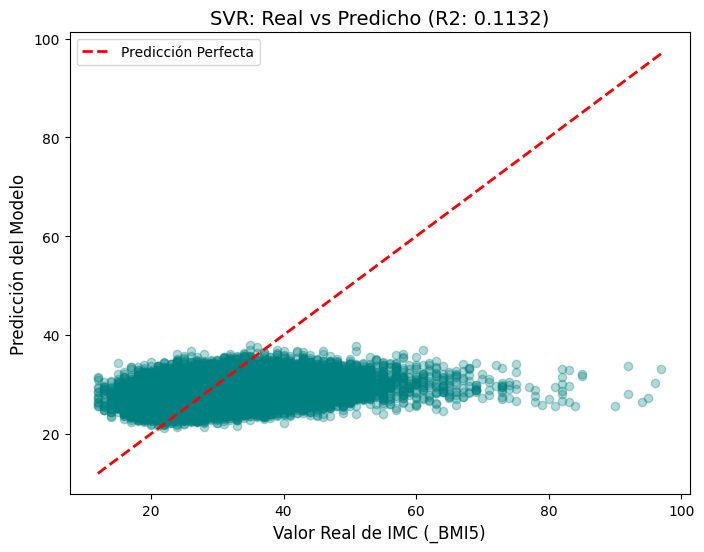

In [59]:
# EVALUACIÓN DEL MEJOR MODELO: R2 (SVR)

# Extraemos los parámetros directamente del modelo ya entrenado
params = modelo_r2_3_2_3.get_params()
print("Mejor modelo SVR según R2")
print(f"Parámetros: C={params['C']} | Epsilon={params['epsilon']}\n")

# Predicciones
y_pred_reg_svr = modelo_r2_3_2_3.predict(X_val_scaled)

# Calculamos las métricas exactas
r2 = r2_score(y_val, y_pred_reg_svr)
mae = mean_absolute_error(y_val, y_pred_reg_svr)
rmse = np.sqrt(mean_squared_error(y_val, y_pred_reg_svr))

print("Reporte de Métricas de Regresión:")
print(f"R2   : {r2:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}\n")

# Gráfico de Dispersión (Real vs Predicción)
plt.figure(figsize=(8, 6))
# Usamos 'teal' para diferenciarlo del azul de la Regresión Ridge (puedes cambiarlo a 'blue')
plt.scatter(y_val, y_pred_reg_svr, alpha=0.3, color='teal')

# Línea diagonal ideal (y = x)
min_val = min(y_val.min(), y_pred_reg_svr.min())
max_val = max(y_val.max(), y_pred_reg_svr.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Predicción Perfecta')

# Títulos y etiquetas
plt.title(f'SVR: Real vs Predicho (R2: {r2:.4f})', fontsize=14)
plt.xlabel('Valor Real de IMC (_BMI5)', fontsize=12)
plt.ylabel('Predicción del Modelo', fontsize=12)
plt.legend()
plt.show()

Este modelo de Máquinas de Vectores de Soporte para regresión (SVR), optimizado con una penalización estándar ($C = 1$) y un margen de tolerancia ($\epsilon = 2$), se mantiene en la línea de los algoritmos anteriores. Con un coeficiente de determinación ($R^2$) de apenas $0.1132$, el modelo se muestra incapaz de capturar la varianza del IMC. Como evidencia el gráfico de dispersión, la nube de predicciones se agrupa de nuevo en una franja horizontal aproximadamente entre los valores $22$ y $38$, ignorando casi por completo la línea de predicción perfecta (en rojo). Aunque el Error Medio Absoluto ($MAE = 4.27$) presenta una levísima mejora respecto a la regresión Ridge, el SVR sigue sin realizar predicciones buenas para los valores atípicos.

De todos los modelos planteados para regresión el que proporciona mejores resultados es el árbol de regresión, además de ser el modelo más sencillo. Incorporamos el siguiente gráfico para ver cómo decide el árbol, al menos en los 3 primeros niveles:

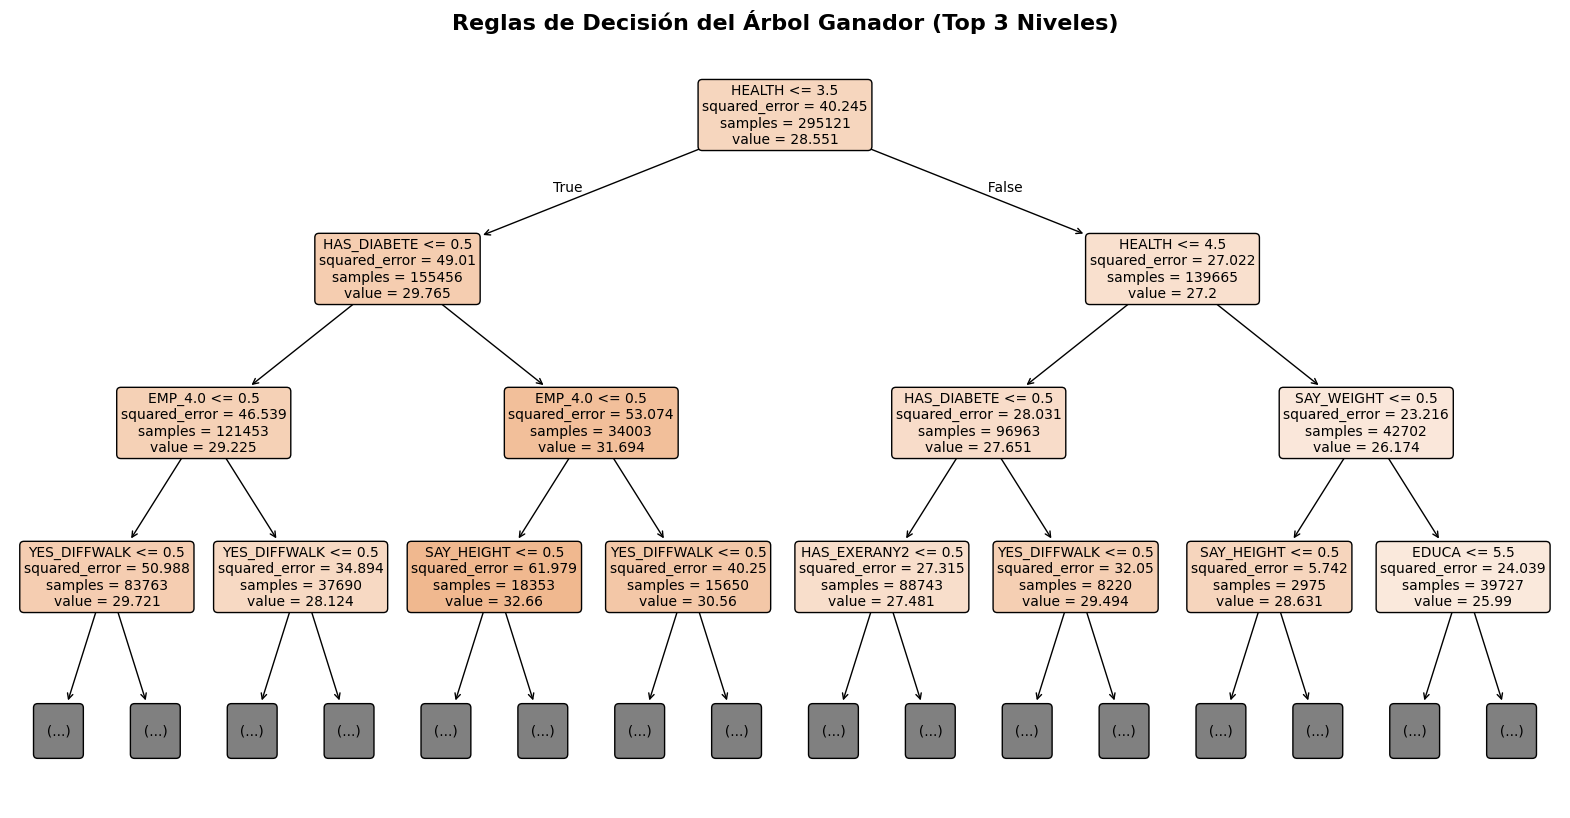

In [60]:
plt.figure(figsize=(20, 10))

# Dibujamos el árbol
plot_tree(modelo_r2_3_2_1,
          feature_names=X_train.columns,  # Nombres reales de las variables
          filled=True,                    # Colorea las cajas según el valor
          rounded=True,                   # Bordes redondeados
          max_depth=3,                    # Solo mostramos los 3 primeros niveles
          fontsize=10)

plt.title("Reglas de Decisión del Árbol Ganador (Top 3 Niveles)", fontsize=16, fontweight='bold')
plt.show()

El árbol de regresión muestra que el estado de salud general (HEALTH) es el factor principal para estimar el Índice de Masa Corporal (IMC). El nodo raíz divide la muestra en individuos con peor salud (HEALTH <= 3.5) a los que da un IMC superior (29.7) que a la rama derecha, que agrupa a quienes tienen un mejor estado físico (27.2). Esta rama derecha separa posteriormente a los encuestados con salud excelente (HEALTH > 4.5) para asignarles el IMC más bajo todavía (26.2).

Si nos fijamos en la tercera profundidad (la más profunda que se muestra), observamos que el IMC mínimo se establece para estas personas con salud excelente y que además responden a la pregunta del peso. Para la 4 profundidad el árbol en esta rama divide entre los que tienen una educación por enicma de 5.5, que recodamso es: *College 4 years or more (College graduate)*.

Por el contrario, el IMC más alto de todo el árbol (32.66) se da a los individuos con una peor salud, con diabetes y que no están desempleados (EMP_4 = 0).

Por último evaluamos este modelo en el conjunto de test para ver cómo se comporta y qué métricas tiene en un conjunto de datos completamente nuevo para él. Al haber seleccionado el modelo que mejores resultados da en el conjunto de validación, es esperable que los resultados bajen ligeramente en este conjunto.

EVALUANDO MODELO FINAL: Árbol de Regresión

RESULTADOS FINALES EN EL CONJUNTO DE TEST
R2 (Porcentaje de acierto general):  0.1175
MAE (Error absoluto medio en IMC):   4.3394
RMSE (Error cuadrático medio en IMC): 6.0033



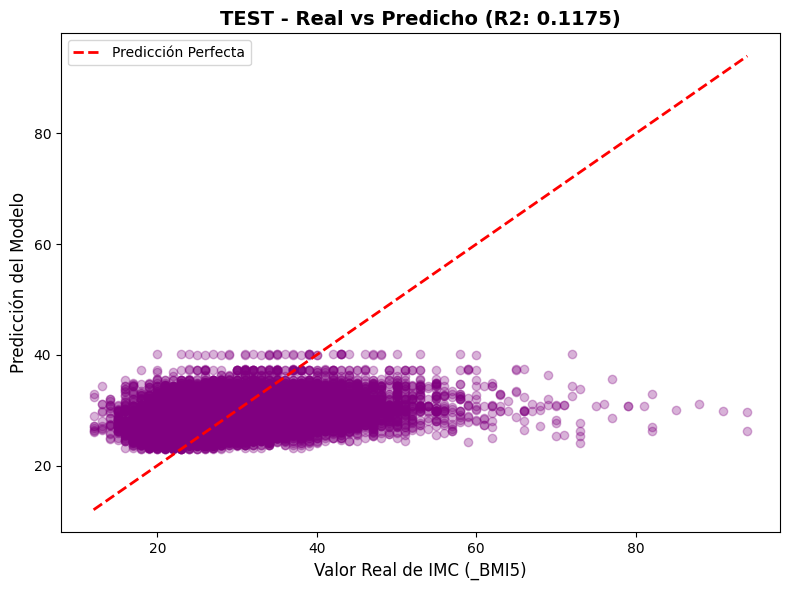

In [61]:
# EVALUACIÓN EN TEST: MEJOR MODELO R2 (ÁRBOL DE REGRESIÓN)


# Cargamos el modelo ganador directamente desde el disco
ruta_modelo_3_2_r2 = os.path.join(results_path, '3_2_1_r2.pkl')
modelo_3_2_r2 = joblib.load(ruta_modelo_3_2_r2)

print("EVALUANDO MODELO FINAL: Árbol de Regresión")

# Usamos X_test (sin escalar) para Árboles de Regresión
y_pred_test_3_2_r2 = modelo_3_2_r2.predict(X_test)

# Cálculo de las métricas definitivas
r2_test = r2_score(y_test, y_pred_test_3_2_r2)
mae_test = mean_absolute_error(y_test, y_pred_test_3_2_r2)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test_3_2_r2))

print("\nRESULTADOS FINALES EN EL CONJUNTO DE TEST")
print(f"R2 (Porcentaje de acierto general):  {r2_test:.4f}")
print(f"MAE (Error absoluto medio en IMC):   {mae_test:.4f}")
print(f"RMSE (Error cuadrático medio en IMC): {rmse_test:.4f}\n")

# Gráfico de Dispersión (Real vs Predicción en TEST)
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_test_3_2_r2, alpha=0.3, color='purple')

# Línea diagonal ideal (y = x)
min_val = min(y_test.min(), y_pred_test_3_2_r2.min())
max_val = max(y_test.max(), y_pred_test_3_2_r2.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Predicción Perfecta')

# Títulos y etiquetas
plt.title(f'TEST - Real vs Predicho (R2: {r2_test:.4f})', fontsize=14, fontweight='bold')
plt.xlabel('Valor Real de IMC (_BMI5)', fontsize=12)
plt.ylabel('Predicción del Modelo', fontsize=12)
plt.legend()

plt.tight_layout()
plt.show()

El modelo generaliza de manera excelente ante datos no vistos y replica el mismo patrón que en validación. Las gráficas de dispersión para validación (negra) y test (morada) son visualmente idénticas y muestran las predicciones alrededor de un valor de IMC medio (25-35). Las métricas R2 son muy cercanas, con un 0.1198 en validación versus 0.1175 en test.

# 4. Parte 2. Ensembles y clustering

En esta segunda parte del trabajo se tratarán de utilizar modelos algo más complejos que los vistos en la primera parte para realizar la tarea de clasificación. Utilizaremos modelos que ya hemos probado en la primera parte pero que ahora se combinarán entre sí mediante ensembles para tratar de proporcionar mejores resultados.

También haremos aprendizaje no supervisado, tratando de agrupar a los individuos según sus hábitos y situaciones sociodemográifcas con tal de formar perfiles y relacionarlos con las variables de salud.

## 4.1 Modelos de Ensemble (Clasificación Multiclase)

En esta sección vamos volver a tratar de clasificar a los individuos de la población según su nivel de salud.

De nuevo debemos tener en cuenta antes de realizar predicciones sobre esta variable que existen otras columnas directamente ligadas con la salud general, como son `HEALTH`, `GENHLTH`, `PHYSHLTH`, `MENTHLTH`, `POORHLTH` `SAY_PHYSHLTH` y `SAY_MENTHLTH`.

Tras excluir las variables mencionadas separamos el conjunto de datos en TRAIN (70%), VALIDACIÓN (20%) y TEST (10%).

In [62]:
# Variables que DEBEN quedarse fuera para no hacer trampa (Target Leakage)
excluir_columnas = ['HEALTH', 'GENHLTH', 'PHYSHLTH', 'MENTHLTH', 'POORHLTH',
                      'SAY_PHYSHLTH', 'SAY_MENTHLTH']

X = data.drop(columns=[col for col in excluir_columnas if col in data.columns])
y = data['HEALTH']

# División 70/20/10
# Primero separamos el 70% para Train y el 30% restante para un conjunto temporal
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)

# Del 30% temporal, dividimos: 2/3 para Validación (20% del total) y 1/3 para Test (10% del total)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=1/3, random_state=42, stratify=y_temp)

print(f"Distribución de datos:")
print(f"Entrenamiento (Train): {X_train.shape[0]} filas (70%)")
print(f"Validación (Val):      {X_val.shape[0]} filas (20%)")
print(f"Prueba (Test):         {X_test.shape[0]} filas (10%)")

# Escalado de características (Fit solo en Train, transform en el resto)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

Distribución de datos:
Entrenamiento (Train): 295121 filas (70%)
Validación (Val):      84320 filas (20%)
Prueba (Test):         42161 filas (10%)


### 4.1.1 Bagging: Random Forest

En esta sección implementaremos *Random Forest*, un algoritmo de ensembles basado en la técnica de *Bagging* (Bootstrap Aggregating). El objetivo principal es construir un modelo mediante la combinación paralela de múltiples árboles de decisión independientes.

In [63]:
# SEGURO DE EJECUCIÓN

REENTRENAR = False  # Cambiar a False una vez para que no vuelva a entrenar

ruta_csv = os.path.join(results_path, 'resultados_4_1_1.csv')
ruta_f1 = os.path.join(results_path, '4_1_1_f1.pkl')
ruta_recall = os.path.join(results_path, '4_1_1_recall.pkl')
ruta_acc = os.path.join(results_path, '4_1_1_acc.pkl')

if not REENTRENAR and os.path.exists(ruta_csv):
    print("Cargando resultados desde el disco...")
    resultados_4_1_1 = pd.read_csv(ruta_csv)
    display(resultados_4_1_1.head(10))

    # Carga de los modelos entrenados
    modelo_f1_4_1_1 = joblib.load(ruta_f1)
    if os.path.exists(ruta_recall):
        modelo_recall_4_1_1 = joblib.load(ruta_recall)
    if os.path.exists(ruta_acc):
        modelo_acc_4_1_1 = joblib.load(ruta_acc)

else:
    # Definimos la cuadrícula para el Random Forest
    param_grid = {
        'n_estimators': [50, 100],        # Cantidad de árboles en el bosque
        'max_depth': [15, 25],            # Profundidad máxima de cada árbol
        'class_weight': [None, 'balanced'] # Vital para detectar las minorías de salud
    }

    # Creamos la lista (2*2*2 = 8 modelos)
    grid = ParameterGrid(param_grid)
    resultados_grid = []

    print(f"Comenzando entrenamiento de {len(grid)} combinaciones de Random Forest.")
    print("Al ser un Ensemble, tomará un poco más de tiempo...\n")

    mejor_f1_val = -1
    mejor_recall_val = -1
    mejor_acc_val = -1

    modelo_f1_4_1_1 = None
    modelo_recall_4_1_1 = None
    modelo_acc_4_1_1 = None

    # Bucle de entrenamiento y evaluación
    for i, params in enumerate(grid):
        print(f"Entrenando modelo {i + 1} de {len(grid)}...")

        # Entrenamiento del Random Forest (usamos n_jobs=-1 para velocidad)
        rf = RandomForestClassifier(**params, random_state=42, n_jobs=-1)
        rf.fit(X_train, y_train)

        # Predicciones en VALIDACIÓN
        y_pred_val = rf.predict(X_val)

        # Cálculo de métricas
        acc = accuracy_score(y_val, y_pred_val)
        f1_macro = f1_score(y_val, y_pred_val, average='macro', zero_division=0)
        prec_macro = precision_score(y_val, y_pred_val, average='macro', zero_division=0)
        recall_macro = recall_score(y_val, y_pred_val, average='macro', zero_division=0)

        # Captura de los mejores modelos en memoria
        if f1_macro > mejor_f1_val:
            mejor_f1_val = f1_macro
            modelo_f1_4_1_1 = rf

        if recall_macro > mejor_recall_val:
            mejor_recall_val = recall_macro
            modelo_recall_4_1_1 = rf

        if acc > mejor_acc_val:
            mejor_acc_val = acc
            modelo_acc_4_1_1 = rf

        # Guardamos los resultados
        resultados_grid.append({
            'n_estimators': params['n_estimators'],
            'max_depth': params['max_depth'],
            'class_weight': str(params['class_weight']),
            'Accuracy': acc,
            'Precision_Macro': prec_macro,
            'Recall_Macro': recall_macro,
            'F1_Macro': f1_macro
        })

    resultados_4_1_1 = pd.DataFrame(resultados_grid)

    # Ordenamos por F1_Macro de mayor a menor
    resultados_4_1_1 = resultados_4_1_1.sort_values(by='F1_Macro', ascending=False).reset_index(drop=True)

    print("\nMEJORES MODELOS RANDOM FOREST (Ordenados por F1-Macro)")
    display(resultados_4_1_1.head(10))

    # GUARDADO DE RESULTADOS Y MODELOS
    print("\nGuardando resultados y mejores modelos...")

    # Guardar la tabla de resultados
    resultados_4_1_1.to_csv(ruta_csv, index=False)

    # Guardar siempre el mejor por F1
    joblib.dump(modelo_f1_4_1_1, ruta_f1)
    print(f"'4_1_1_f1.pkl' guardado (F1: {mejor_f1_val:.4f})")

    # Guardar el mejor por Recall (solo si es diferente al de F1)
    if modelo_recall_4_1_1 is not modelo_f1_4_1_1:
        joblib.dump(modelo_recall_4_1_1, ruta_recall)
        print(f"'4_1_1_recall.pkl' guardado (Recall: {mejor_recall_val:.4f})")
    else:
        print("El modelo por Recall coincide con F1. No se duplica.")

    # Guardar el mejor por Accuracy (solo si es diferente a los dos anteriores)
    if modelo_acc_4_1_1 not in [modelo_f1_4_1_1, modelo_recall_4_1_1]:
        joblib.dump(modelo_acc_4_1_1, ruta_acc)
        print(f"'4_1_1_acc.pkl' guardado (Accuracy: {mejor_acc_val:.4f})")
    else:
        print("El modelo por Accuracy coincide con uno anterior. No se duplica.")

Cargando resultados desde el disco...


,n_estimators,max_depth,class_weight,Accuracy,Precision_Macro,Recall_Macro,F1_Macro
0,100,25,balanced,0.413816,0.412736,0.378178,0.380618
1,50,25,balanced,0.409511,0.407654,0.376989,0.378733
2,100,15,balanced,0.368121,0.371462,0.426774,0.372444
3,50,15,balanced,0.367030,0.370423,0.426444,0.371137
4,100,25,NaN,0.449419,0.451328,0.343811,0.351600
5,50,25,NaN,0.445968,0.441244,0.343522,0.351524
6,100,15,NaN,0.451411,0.488509,0.330640,0.326047
7,50,15,NaN,0.450629,0.479991,0.330229,0.325544


En este caso tenemos un mejor modelo por cada una de las métricas

Mejor modelo según: Accuracy
Parámetros: Árboles=100 | Profundidad=15 | Peso=None

Reporte de Clasificación:
              precision    recall  f1-score   support

         1.0       0.52      0.19      0.27      3697
         2.0       0.43      0.24      0.31     11968
         3.0       0.44      0.57      0.50     28806
         4.0       0.46      0.65      0.54     27668
         5.0       0.59      0.00      0.01     12181

    accuracy                           0.45     84320
   macro avg       0.49      0.33      0.33     84320
weighted avg       0.47      0.45      0.40     84320



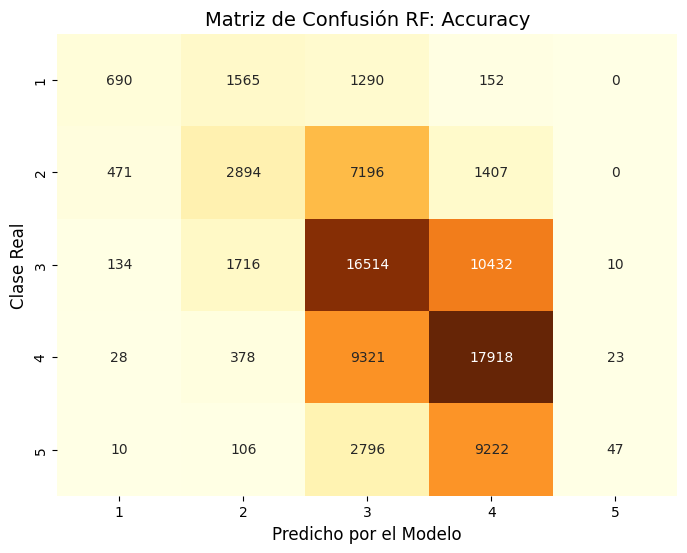

In [64]:
# EVALUACIÓN DEL MEJOR MODELO: ACCURACY (RF)

metrica = 'Accuracy'

# Extraemos parámetros del modelo en memoria
params = modelo_acc_4_1_1.get_params()
print(f"Mejor modelo según: {metrica}")
print(f"Parámetros: Árboles={params['n_estimators']} | Profundidad={params['max_depth']} | Peso={params['class_weight']}\n")

# Predicciones directas
y_pred_acc = modelo_acc_4_1_1.predict(X_val)

# Reporte de clasificación
print("Reporte de Clasificación:")
print(classification_report(y_val, y_pred_acc, zero_division=0))

# Matriz de Confusión
cm = confusion_matrix(y_val, y_pred_acc)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='g', cmap='YlOrBr', cbar=False,
            xticklabels=[1, 2, 3, 4, 5],
            yticklabels=[1, 2, 3, 4, 5])

plt.title(f'Matriz de Confusión RF: {metrica}', fontsize=14)
plt.xlabel('Predicho por el Modelo', fontsize=12)
plt.ylabel('Clase Real', fontsize=12)
plt.show()

Este primer modelo de Random Forest, seleccionado por alcanzar la mayor exactitud global ($Accuracy = 0.4514$) utilizando un ensamble de 100 árboles con una profundidad de 15 y sin aplicar balanceo de clases ($Peso=None$), tiene un comportamiento conservador y sesgado hacia las categorías mayoritarias. Al igual que ocurrió con los primeros modelos de árbol de decisión y regresión logística, este algoritmo infla su tasa de acierto apostando casi en exclusiva por los niveles de salud centrales (clases 3 y 4), donde logra sus mejores métricas de sensibilidad ($0.57$ y $0.65$, respectivamente). Sin embargo, pierde su capacidad predictiva en los extremos, destacando el caso crítico de la clase 5 (salud excelente) con un $recall$ prácticamente nulo, logrando identificar correctamente a tan solo 48 individuos de más de 12,000. La matriz de confusión evidencia de forma contundente cómo el modelo arrastra masivamente estas predicciones hacia el nivel 4 (con más de 9,200 falsos negativos).

Mejor modelo según: Recall_Macro
Parámetros: Árboles=100 | Profundidad=15 | Peso=balanced

Reporte de Clasificación:
              precision    recall  f1-score   support

         1.0       0.33      0.48      0.39      3697
         2.0       0.32      0.45      0.37     11968
         3.0       0.46      0.29      0.36     28806
         4.0       0.46      0.28      0.35     27668
         5.0       0.29      0.64      0.40     12181

    accuracy                           0.37     84320
   macro avg       0.37      0.43      0.37     84320
weighted avg       0.41      0.37      0.36     84320



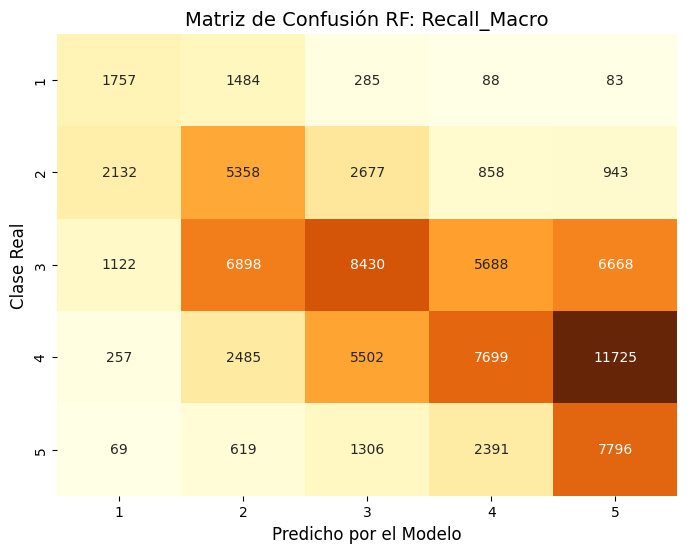

In [65]:
# EVALUACIÓN DEL MEJOR MODELO: RECALL MACRO (RF)

metrica = 'Recall_Macro'

params = modelo_recall_4_1_1.get_params()
print(f"Mejor modelo según: {metrica}")
print(f"Parámetros: Árboles={params['n_estimators']} | Profundidad={params['max_depth']} | Peso={params['class_weight']}\n")

y_pred_recall = modelo_recall_4_1_1.predict(X_val)

print("Reporte de Clasificación:")
print(classification_report(y_val, y_pred_recall, zero_division=0))

cm = confusion_matrix(y_val, y_pred_recall)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='g', cmap='YlOrBr', cbar=False,
            xticklabels=[1, 2, 3, 4, 5],
            yticklabels=[1, 2, 3, 4, 5])

plt.title(f'Matriz de Confusión RF: {metrica}', fontsize=14)
plt.xlabel('Predicho por el Modelo', fontsize=12)
plt.ylabel('Clase Real', fontsize=12)
plt.show()

Este segundo modelo de Random Forest que maximiza el Recall Macro (0.4268) posee pesos balanceados (class_weight='balanced'). Su principal virtud es la recuperación de la sensibilidad en los extremos ya que logra elevar la detección de los pacientes con peor salud (clase 1) a un 0.48 y dispara el recall de la clase 5 (salud excelente) hasta un notable 0.64, sacándola del cero absoluto. Sin embargo, esto exige un sacrificio altísimo en la exactitud global (Accuracy = 0.37). Al observar la matriz de confusión, se observa que el modelo ha adoptado una postura de máxima precaución, sobreprediciendo agresivamente los extremos. Un ejemplo claro es cómo arrastra a más de 18,000 encuestados con niveles de salud intermedios (clases 3 y 4) hacia la categoría de salud excelente, generando una gran cantidad de falsos positivos.

Mejor modelo según: F1_Macro
Parámetros: Árboles=100 | Profundidad=25 | Peso=balanced

Reporte de Clasificación:
              precision    recall  f1-score   support

         1.0       0.45      0.22      0.29      3697
         2.0       0.39      0.31      0.34     11968
         3.0       0.45      0.49      0.47     28806
         4.0       0.46      0.36      0.41     27668
         5.0       0.32      0.51      0.39     12181

    accuracy                           0.41     84320
   macro avg       0.41      0.38      0.38     84320
weighted avg       0.42      0.41      0.41     84320



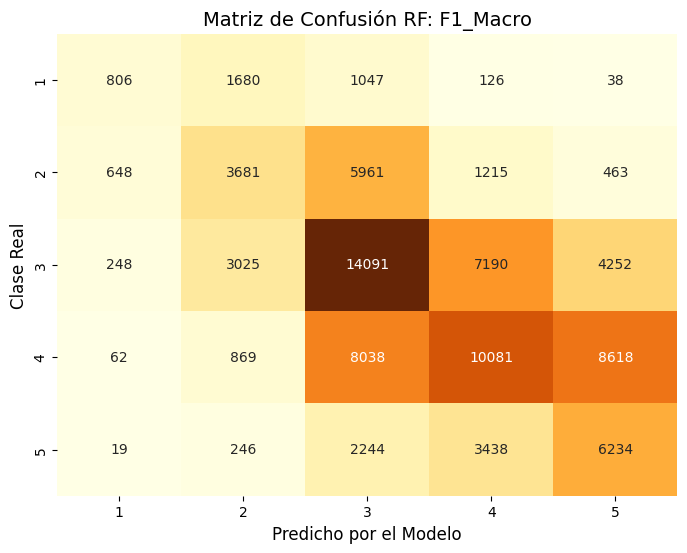

In [66]:
# EVALUACIÓN DEL MEJOR MODELO: F1 MACRO (RF)

metrica = 'F1_Macro'

params = modelo_f1_4_1_1.get_params()
print(f"Mejor modelo según: {metrica}")
print(f"Parámetros: Árboles={params['n_estimators']} | Profundidad={params['max_depth']} | Peso={params['class_weight']}\n")

y_pred_f1 = modelo_f1_4_1_1.predict(X_val)

print("Reporte de Clasificación:")
print(classification_report(y_val, y_pred_f1, zero_division=0))

cm = confusion_matrix(y_val, y_pred_f1)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='g', cmap='YlOrBr', cbar=False,
            xticklabels=[1, 2, 3, 4, 5],
            yticklabels=[1, 2, 3, 4, 5])

plt.title(f'Matriz de Confusión RF: {metrica}', fontsize=14)
plt.xlabel('Predicho por el Modelo', fontsize=12)
plt.ylabel('Clase Real', fontsize=12)
plt.show()

Este tercer y último modelo de Random Forest, seleccionado por maximizar el $F1\_Macro$ ($0.3806$) tiene una estructura más profunda (profundidad $= 25$) y utiliza pesos balanceados. Se trata de un modelo equilibrado entre los dos enfoques anteriores, busca equilibrar la precisión y recuperar parte de la exactitud global ($Accuracy = 0.41$) frente al segundo modelo, reduciendo la gran cantidad de falsos positivos. Sin embargo, este equilibrio resulta ser bastante asimétrico: mientras que mantiene una capacidad razonable para detectar la salud excelente (clase 5, con un $recall$ de $0.51$), sacrifica de forma notoria la detección del estado de salud más bajo (clase 1), cuyo $recall$ se desploma a $0.22$. La matriz de confusión ilustra claramente cómo el modelo sufre de solapamiento en los niveles superiores, arrastrando a más de 12,000 personas de las clases 3 y 4 hacia la categoría 5.

### 4.1.2 Boosting: Gradient Boosting

Vamos a probar en esta sección el método de *Gradient Boosting*. Este algoritmo de ensembles consiste en construir un modelo predictivo a partir de la combinación secuencial de modelos base más sencillos.

En este caso utilizaremos los modelos base más comunes para este ensemble como son los árboles de decisión. Como el *Gradient Boosting* es algo costoso de entrenar vamos a probar 4 combinaciones de parámetros.

In [67]:
# SEGURO DE EJECUCIÓN

REENTRENAR = False  # Cambiar a False una vez para que no vuelva a entrenar

ruta_csv = os.path.join(results_path, 'resultados_4_1_2.csv')
ruta_f1 = os.path.join(results_path, '4_1_2_f1.pkl')
ruta_recall = os.path.join(results_path, '4_1_2_recall.pkl')
ruta_acc = os.path.join(results_path, '4_1_2_acc.pkl')

if not REENTRENAR and os.path.exists(ruta_csv):
    print("Cargando resultados desde el disco...")
    resultados_4_1_2 = pd.read_csv(ruta_csv)
    display(resultados_4_1_2.head(10))

    # Carga de los modelos entrenados
    modelo_f1_4_1_2 = joblib.load(ruta_f1)
    if os.path.exists(ruta_recall):
        modelo_recall_4_1_2 = joblib.load(ruta_recall)
    if os.path.exists(ruta_acc):
        modelo_acc_4_1_2 = joblib.load(ruta_acc)

else:
    # Definimos la cuadrícula para Gradient Boosting
    param_grid = {
        'n_estimators': [50, 100],        # Número de etapas de boosting (árboles)
        'learning_rate': [0.1, 0.2],      # Cuánto corrige cada árbol
        'max_depth': [3]                  # Profundidad baja para evitar sobreajuste
    }

    # Creamos la lista (2*2*1 = 4 modelos)
    grid = ParameterGrid(param_grid)
    resultados_grid = []

    print(f"Comenzando entrenamiento de {len(grid)} combinaciones de Gradient Boosting.")

    mejor_f1_val = -1
    mejor_recall_val = -1
    mejor_acc_val = -1

    modelo_f1_4_1_2 = None
    modelo_recall_4_1_2 = None
    modelo_acc_4_1_2 = None

    # Bucle de entrenamiento y evaluación
    for i, params in enumerate(grid):
        print(f"Entrenando modelo {i + 1} de {len(grid)}...")

        # Entrenamiento del Gradient Boosting
        gb = GradientBoostingClassifier(**params, random_state=42)
        gb.fit(X_train, y_train)

        # Predicciones en VALIDACIÓN
        y_pred_val = gb.predict(X_val)

        # Cálculo de métricas
        acc = accuracy_score(y_val, y_pred_val)
        f1_macro = f1_score(y_val, y_pred_val, average='macro', zero_division=0)
        prec_macro = precision_score(y_val, y_pred_val, average='macro', zero_division=0)
        recall_macro = recall_score(y_val, y_pred_val, average='macro', zero_division=0)

        # Captura de los mejores modelos en memoria
        if f1_macro > mejor_f1_val:
            mejor_f1_val = f1_macro
            modelo_f1_4_1_2 = gb

        if recall_macro > mejor_recall_val:
            mejor_recall_val = recall_macro
            modelo_recall_4_1_2 = gb

        if acc > mejor_acc_val:
            mejor_acc_val = acc
            modelo_acc_4_1_2 = gb

        # Guardamos los resultados
        resultados_grid.append({
            'n_estimators': params['n_estimators'],
            'learning_rate': params['learning_rate'],
            'max_depth': params['max_depth'],
            'Accuracy': acc,
            'Precision_Macro': prec_macro,
            'Recall_Macro': recall_macro,
            'F1_Macro': f1_macro
        })

    resultados_4_1_2 = pd.DataFrame(resultados_grid)

    # Ordenamos por F1_Macro de mayor a menor
    resultados_4_1_2 = resultados_4_1_2.sort_values(by='F1_Macro', ascending=False).reset_index(drop=True)

    print("\nMEJORES MODELOS GRADIENT BOOSTING (Ordenados por F1-Macro)")
    display(resultados_4_1_2.head(10))

    # GUARDADO DE RESULTADOS Y MODELOS
    print("\nGuardando resultados y mejores modelos...")

    # Guardar la tabla de resultados
    resultados_4_1_2.to_csv(ruta_csv, index=False)

    # Guardar siempre el mejor por F1
    joblib.dump(modelo_f1_4_1_2, ruta_f1)
    print(f"'4_1_2_f1.pkl' guardado (F1: {mejor_f1_val:.4f})")

    # Guardar el mejor por Recall (solo si es diferente al de F1)
    if modelo_recall_4_1_2 is not modelo_f1_4_1_2:
        joblib.dump(modelo_recall_4_1_2, ruta_recall)
        print(f"'4_1_2_recall.pkl' guardado (Recall: {mejor_recall_val:.4f})")
    else:
        print("El modelo por Recall coincide con F1. No se duplica.")

    # Guardar el mejor por Accuracy (solo si es diferente a los dos anteriores)
    if modelo_acc_4_1_2 not in [modelo_f1_4_1_2, modelo_recall_4_1_2]:
        joblib.dump(modelo_acc_4_1_2, ruta_acc)
        print(f"'4_1_2_acc.pkl' guardado (Accuracy: {mejor_acc_val:.4f})")
    else:
        print("El modelo por Accuracy coincide con uno anterior. No se duplica.")

Cargando resultados desde el disco...


,n_estimators,learning_rate,max_depth,Accuracy,Precision_Macro,Recall_Macro,F1_Macro
0,100,0.2,3,0.457839,0.459926,0.356821,0.365950
1,50,0.2,3,0.455408,0.460437,0.350799,0.357375
2,100,0.1,3,0.455266,0.464010,0.349812,0.355870
3,50,0.1,3,0.450154,0.461670,0.338427,0.338747


El modelo con 100 estimadores (árboles), learing rate de 0.2 y 3 de profundidad en sus árboles es el que maximiza el *accuracy* general, el recall macro y el f1 macro.

Mejor modelo Gradient Boosting (Ganador Global)
Parámetros: Árboles=100 | LR=0.2 | Profundidad=3

Reporte de Clasificación:
              precision    recall  f1-score   support

         1.0       0.49      0.25      0.33      3697
         2.0       0.43      0.27      0.33     11968
         3.0       0.45      0.56      0.50     28806
         4.0       0.47      0.63      0.54     27668
         5.0       0.46      0.08      0.13     12181

    accuracy                           0.46     84320
   macro avg       0.46      0.36      0.37     84320
weighted avg       0.46      0.46      0.43     84320



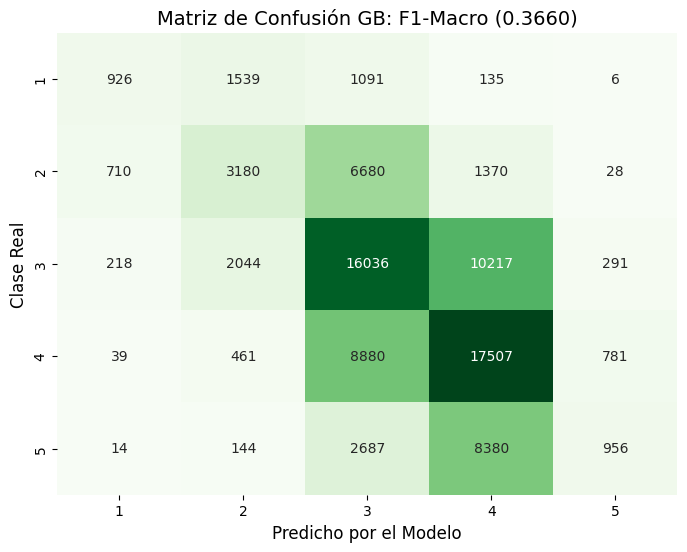

In [68]:
# EVALUACIÓN DEL MEJOR MODELO

# Extraemos los parámetros directamente del modelo ya entrenado en memoria
params = modelo_f1_4_1_2.get_params()
print(f"Mejor modelo Gradient Boosting (Ganador Global)")
print(f"Parámetros: Árboles={params['n_estimators']} | LR={params['learning_rate']} | Profundidad={params['max_depth']}\n")

# Predicciones
# Usamos X_val (los modelos de boosting no requieren escalado)
y_pred_gb = modelo_f1_4_1_2.predict(X_val)

# Mostramos el detalle exacto por cada clase
print("Reporte de Clasificación:")
print(classification_report(y_val, y_pred_gb, zero_division=0))

# Calcular los valores de la matriz de confusión
cm = confusion_matrix(y_val, y_pred_gb)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='g', cmap='Greens', cbar=False,
             xticklabels=[1, 2, 3, 4, 5],
             yticklabels=[1, 2, 3, 4, 5])

f1_val = f1_score(y_val, y_pred_gb, average='macro', zero_division=0)
plt.title(f'Matriz de Confusión GB: F1-Macro ({f1_val:.4f})', fontsize=14)
plt.xlabel('Predicho por el Modelo', fontsize=12)
plt.ylabel('Clase Real', fontsize=12)

plt.show()

Este modelo de Gradient Boosting, seleccionado por obtener el mejor $F1\_Macro$ ($0.3660$) con una configuración de árboles poco profundos (profundidad $= 3.0$) y una tasa de aprendizaje moderada ($LR = 0.2$), logra la mayor exactitud global de todos los clasificadores evaluados hasta ahora ($Accuracy = 0.46$) gracias a un comportamiento muy conservador. El algoritmo concentra todo su poder predictivo en las categorías mayoritarias centrales, alcanzando niveles de $recall$ del $0.56$ y $0.63$ para las clases 3 y 4, respectivamente. Sin embargo, la capacidad para detectar el estado de salud más deficiente (clase 1) es pobre ($0.25$), y su rendimiento en la clase 5 (salud excelente) es más bajo todavía, con un $recall$ de apenas $0.08$. La matriz de confusión muestra esta deficiencia, más de 11,000 personas con salud excelente son clasificadas erróneamente por las clases 3 y 4.

### 4.1.3 Stacking

En esta sección vamos a probar un modelo ensamblado mediante la técnica de Stacking integrando un Random Forest y un Árbol de Decisión como modelos base coordinados por una Regresión Logística con pesos balanceados. Al delegar la decisión final en un meta-modelo con class_weight='balanced', el sistema hereda la sensibilidad característica de los modelos balanceados previos, alcanzando un $Recall$ de $0.62$ para la salud más precaria (clase 1) y de $0.57$ para la salud excelente (clase 5). No obstante, esto vuelve a sacrificar la exactitud global ($Accuracy = 0.37$), ya que el modelo asume un alto riesgo al desplazar miles de casos desde las categorías mayoritarias (3 y 4) hacia los bordes de la escala para evitar omitir los casos críticos. En conclusión, el Stacking se consolida como una estrategia robusta para combatir el desbalance de clases, ofreciendo un equilibrio de $F1\_Macro$ ($0.3717$) muy competitivo.

Aunque no se añade al notebook por tiempo de ejecución y extensión, se ha probado el parámetro `passthrough=True` que pasa las decenas de variables originales al meta modelo. En los resultados se ha visto que no ha ayudado a mejorar el rendimiento y además, ha provocado un entrenamiento más lento y las variables originales lo han confundido. Al ser mucho más rápido de entrenar si lo dejamos en `False`, vamos a entrenar 12 modelos de stacking variando el resto de los parámetros.

In [69]:
# SEGURO DE EJECUCIÓN

REENTRENAR = False  # Cambiar a False una vez para que no vuelva a entrenar

ruta_csv = os.path.join(results_path, 'resultados_4_1_3.csv')
ruta_f1 = os.path.join(results_path, '4_1_3_f1.pkl')
ruta_recall = os.path.join(results_path, '4_1_3_recall.pkl')
ruta_acc = os.path.join(results_path, '4_1_3_acc.pkl')

if not REENTRENAR and os.path.exists(ruta_csv):
    print("Cargando resultados desde el disco...")
    resultados_4_1_3 = pd.read_csv(ruta_csv)
    display(resultados_4_1_3.head(10))

    # Carga de los modelos entrenados
    modelo_f1_4_1_3 = joblib.load(ruta_f1)
    if os.path.exists(ruta_recall):
        modelo_recall_4_1_3 = joblib.load(ruta_recall)
    if os.path.exists(ruta_acc):
        modelo_acc_4_1_3 = joblib.load(ruta_acc)

else:
    # Definimos los estimadores base y el meta-modelo
    estimadores_base = [
        ('rf', RandomForestClassifier(max_depth=10, random_state=42, n_jobs=-1)),
        ('dt', DecisionTreeClassifier(random_state=42))
    ]

    meta_modelo = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')

    # Definimos la cuadrícula para el Stacking
    param_grid = {
        'final_estimator__C': [0.1, 1.0, 10.0],  # Meta Model
        'rf__n_estimators': [50, 100],           # RF experto
        'dt__max_depth': [5, 10]                 # DT experto
    }

    # Creamos la lista (3 * 2 * 2 = 12 modelos)
    grid = ParameterGrid(param_grid)
    resultados_grid = []

    print(f"Comenzando entrenamiento de {len(grid)} combinaciones de Stacking.")

    mejor_f1_val = -1
    mejor_recall_val = -1
    mejor_acc_val = -1

    modelo_f1_4_1_3 = None
    modelo_recall_4_1_3 = None
    modelo_acc_4_1_3 = None

    # Bucle de entrenamiento y evaluación
    for i, params in enumerate(grid):
        print(f"Entrenando modelo {i + 1} de {len(grid)}...")

        # Configuramos el StackingClassifier
        stacking_clf = StackingClassifier(
            estimators=estimadores_base,
            final_estimator=meta_modelo,
            cv=3,
            n_jobs=-1
        )

        # Aplicamos los parámetros antes de entrenar
        stacking_clf.set_params(**params)
        stacking_clf.fit(X_train_scaled, y_train)

        # Predicciones en VALIDACIÓN
        y_pred_val = stacking_clf.predict(X_val_scaled)

        # Cálculo de métricas
        acc = accuracy_score(y_val, y_pred_val)
        f1_macro = f1_score(y_val, y_pred_val, average='macro', zero_division=0)
        prec_macro = precision_score(y_val, y_pred_val, average='macro', zero_division=0)
        recall_macro = recall_score(y_val, y_pred_val, average='macro', zero_division=0)

        # Captura de los mejores modelos en memoria
        if f1_macro > mejor_f1_val:
            mejor_f1_val = f1_macro
            modelo_f1_4_1_3 = stacking_clf

        if recall_macro > mejor_recall_val:
            mejor_recall_val = recall_macro
            modelo_recall_4_1_3 = stacking_clf

        if acc > mejor_acc_val:
            mejor_acc_val = acc
            modelo_acc_4_1_3 = stacking_clf

        # Guardamos los resultados
        resultados_grid.append({
            'final_C': params['final_estimator__C'],
            'rf_estimators': params['rf__n_estimators'],
            'dt_depth': params['dt__max_depth'],
            'Accuracy': acc,
            'Precision_Macro': prec_macro,
            'Recall_Macro': recall_macro,
            'F1_Macro': f1_macro
        })

    resultados_4_1_3 = pd.DataFrame(resultados_grid)

    # Ordenamos por F1_Macro de mayor a menor
    resultados_4_1_3 = resultados_4_1_3.sort_values(by='F1_Macro', ascending=False).reset_index(drop=True)

    print("\nMEJORES MODELOS STACKING (Ordenados por F1-Macro)")
    display(resultados_4_1_3.head(10))

    # GUARDADO DE RESULTADOS Y MODELOS
    print("\nGuardando resultados y mejores modelos...")

    # Guardar la tabla de resultados
    resultados_4_1_3.to_csv(ruta_csv, index=False)

    # Guardar siempre el mejor por F1
    joblib.dump(modelo_f1_4_1_3, ruta_f1)
    print(f"'4_1_3_f1.pkl' guardado (F1: {mejor_f1_val:.4f})")

    # Guardar el mejor por Recall (solo si es diferente al de F1)
    if modelo_recall_4_1_3 is not modelo_f1_4_1_3:
        joblib.dump(modelo_recall_4_1_3, ruta_recall)
        print(f"'4_1_3_recall.pkl' guardado (Recall: {mejor_recall_val:.4f})")
    else:
        print("El modelo por Recall coincide con F1. No se duplica.")

    # Guardar el mejor por Accuracy (solo si es diferente a los dos anteriores)
    if modelo_acc_4_1_3 not in [modelo_f1_4_1_3, modelo_recall_4_1_3]:
        joblib.dump(modelo_acc_4_1_3, ruta_acc)
        print(f"'4_1_3_acc.pkl' guardado (Accuracy: {mejor_acc_val:.4f})")
    else:
        print("El modelo por Accuracy coincide con uno anterior. No se duplica.")

Cargando resultados desde el disco...


,final_C,rf_estimators,dt_depth,Accuracy,Precision_Macro,Recall_Macro,F1_Macro
0,1.0,100,5,0.375380,0.363434,0.436996,0.375876
1,0.1,100,5,0.373707,0.361934,0.436652,0.374250
2,10.0,100,5,0.373304,0.362126,0.437067,0.373809
3,1.0,100,10,0.372853,0.361969,0.435450,0.373357
4,10.0,50,5,0.372593,0.361178,0.435451,0.373138
5,10.0,100,10,0.372142,0.361433,0.435392,0.372727
6,1.0,50,5,0.371976,0.360638,0.435296,0.372334
7,10.0,50,10,0.371501,0.360697,0.433948,0.371728
8,1.0,50,10,0.371015,0.360507,0.434657,0.371532
9,0.1,50,5,0.370908,0.359661,0.434506,0.371446


Nos quedamos con la combinación de parámetros que maximiza todas las métricas.

Mejor modelo Stacking según F1-Macro
Parámetros: MetaModel_C=10.0 | RF_Arboles=100 | DT_Prof=10

Reporte de Clasificación:
              precision    recall  f1-score   support

         1.0       0.30      0.62      0.40      3697
         2.0       0.30      0.35      0.32     11968
         3.0       0.46      0.32      0.37     28806
         4.0       0.46      0.33      0.39     27668
         5.0       0.30      0.56      0.39     12181

    accuracy                           0.38     84320
   macro avg       0.36      0.44      0.38     84320
weighted avg       0.41      0.38      0.37     84320



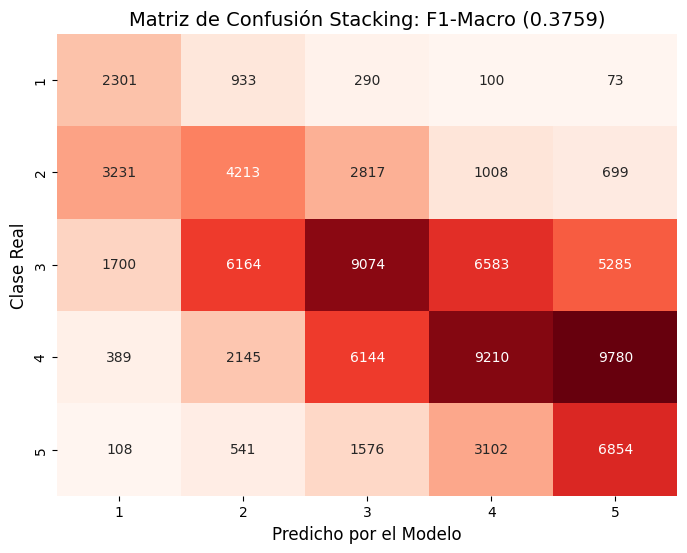

In [70]:
# EVALUACIÓN DEL MEJOR MODELO: F1-MACRO (STACKING)

# Extraemos los parámetros directamente del modelo ya entrenado
params = modelo_f1_4_1_3.get_params()

print(f"Mejor modelo Stacking según F1-Macro")
print(f"Parámetros: MetaModel_C={params['final_estimator__C']} | "
      f"RF_Arboles={params['rf__n_estimators']} | "
      f"DT_Prof={params['dt__max_depth']}\n")

# Predicciones directas (SIN REENTRENAR)
# Usamos X_val_scaled porque el meta-modelo es Logística
y_pred_stack = modelo_f1_4_1_3.predict(X_val_scaled)

# Mostramos el reporte detallado
print("Reporte de Clasificación:")
print(classification_report(y_val, y_pred_stack, zero_division=0))

# Calcular los valores de la matriz
cm = confusion_matrix(y_val, y_pred_stack)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='g', cmap='Reds', cbar=False,
              xticklabels=[1, 2, 3, 4, 5],
              yticklabels=[1, 2, 3, 4, 5])

# Título con la métrica real obtenida
f1_val = f1_score(y_val, y_pred_stack, average='macro', zero_division=0)
plt.title(f'Matriz de Confusión Stacking: F1-Macro ({f1_val:.4f})', fontsize=14)
plt.xlabel('Predicho por el Modelo', fontsize=12)
plt.ylabel('Clase Real', fontsize=12)

plt.show()

Este modelo Stacking prioriza la detección de las clases minoritarias. Logra una alta sensibilidad en los extremos, alcanzando un recall de 0.62 para la salud más baja (clase 1) y de 0.56 para la excelente (clase 5). Sin embargo, este enfoque penaliza la exactitud global (Accuracy = 0.38). La matriz de confusión muestra solapamiento en las categorías centrales, miles de encuestados con salud intermedia (clases 3 y 4) son clasificados erróneamente hacia los bordes de la escala.

Si tenemos en cuenta como métrica principal el F1 Macro y como métrica secundaria el Accuracy, de todos los modelos de ensembles entrenados, el que ha obtenido mejores resultados en el conjunto de validación ha sido el Random Forest con 100 árboles y profundidad máxima 25. Evaluamos sus resultados en el conjunto de test.


RESULTADOS FINALES EN EL CONJUNTO DE TEST
Accuracy General : 0.4174
F1-Macro         : 0.3845
Recall-Macro     : 0.3819

Reporte de Clasificación:
              precision    recall  f1-score   support

         1.0       0.46      0.23      0.30      1849
         2.0       0.40      0.31      0.35      5984
         3.0       0.45      0.50      0.47     14403
         4.0       0.46      0.36      0.41     13835
         5.0       0.32      0.51      0.39      6090

    accuracy                           0.42     42161
   macro avg       0.42      0.38      0.38     42161
weighted avg       0.43      0.42      0.41     42161



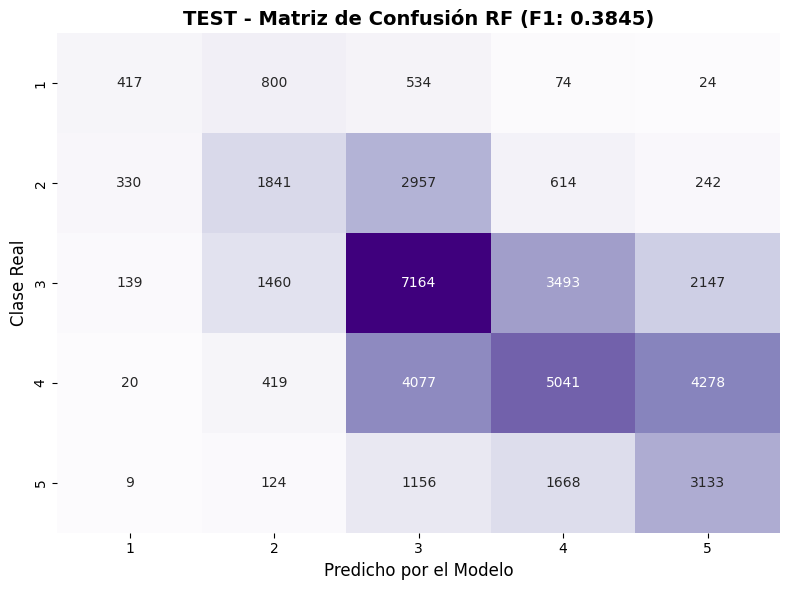

In [71]:
# EVALUACIÓN EN TEST: MEJOR MODELO F1 (RANDOM FOREST)

# Cargamos el modelo ganador directamente desde el disco
ruta_modelo_4_1_f1 = os.path.join(results_path, '4_1_1_f1.pkl')
modelo_4_1_f1 = joblib.load(ruta_modelo_4_1_f1)

# Usamos X_test (Random Forest no requiere escalado)
y_pred_test_4_1_f1 = modelo_4_1_f1.predict(X_test)

# Cálculo de las métricas definitivas
acc_test = accuracy_score(y_test, y_pred_test_4_1_f1)
f1_test = f1_score(y_test, y_pred_test_4_1_f1, average='macro', zero_division=0)
recall_test = recall_score(y_test, y_pred_test_4_1_f1, average='macro', zero_division=0)

print("\nRESULTADOS FINALES EN EL CONJUNTO DE TEST")
print(f"Accuracy General : {acc_test:.4f}")
print(f"F1-Macro         : {f1_test:.4f}")
print(f"Recall-Macro     : {recall_test:.4f}\n")

# Reporte de Clasificación Final
print("Reporte de Clasificación:")
print(classification_report(y_test, y_pred_test_4_1_f1, zero_division=0))

# Matriz de Confusión Final
cm_test = confusion_matrix(y_test, y_pred_test_4_1_f1)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_test, annot=True, fmt='g', cmap='Purples', cbar=False,
            xticklabels=[1, 2, 3, 4, 5],
            yticklabels=[1, 2, 3, 4, 5])

plt.title(f'TEST - Matriz de Confusión RF (F1: {f1_test:.4f})', fontsize=14, fontweight='bold')
plt.xlabel('Predicho por el Modelo', fontsize=12)
plt.ylabel('Clase Real', fontsize=12)
plt.tight_layout()
plt.show()

El modelo generaliza excelentemente ante datos no vistos, replicando el accuracy global (0.42 frente a 0.41) y el comportamiento predictivo en todas las categorías. Mantiene su enfoque estable, confirmando su capacidad para detectar la salud excelente (manteniendo un recall de 0.51 para la clase 5), a costa de sufrir la misma debilidad con un recall de 0.23 para la clase 1 y el habitual solapamiento en los niveles intermedios.

Si tenemos en cuenta la métrica *accuracy*, de todos los modelos de ensembles entrenados, el que ha obtenido mejores resultados en el conjunto de validación ha sido el Random Forest con 100 árboles y profundidad máxima 15. Evaluamos sus resultados en el conjunto de test.


RESULTADOS FINALES EN EL CONJUNTO DE TEST
Accuracy General : 0.4518
F1-Macro         : 0.3275
Recall-Macro     : 0.3321

Reporte de Clasificación:
              precision    recall  f1-score   support

         1.0       0.50      0.20      0.28      1849
         2.0       0.43      0.24      0.31      5984
         3.0       0.44      0.58      0.50     14403
         4.0       0.46      0.65      0.54     13835
         5.0       0.55      0.00      0.01      6090

    accuracy                           0.45     42161
   macro avg       0.48      0.33      0.33     42161
weighted avg       0.47      0.45      0.40     42161



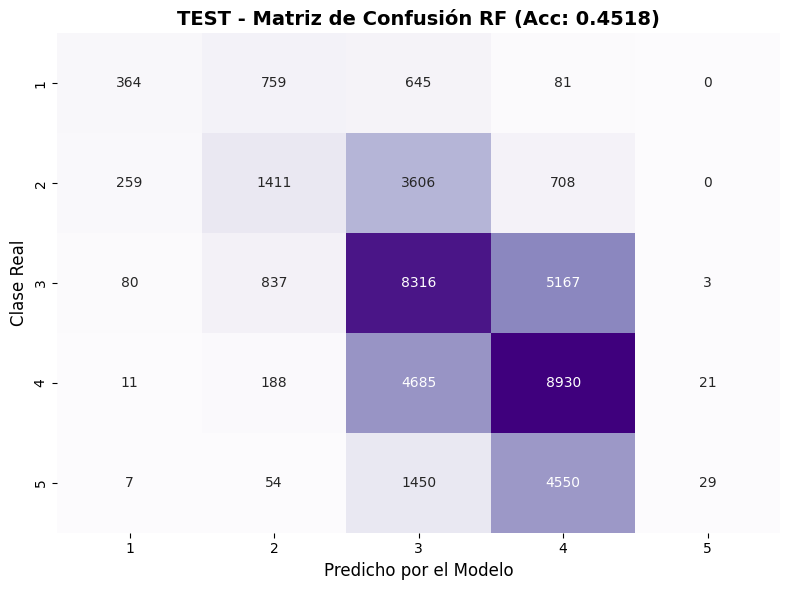

In [72]:
# EVALUACIÓN EN TEST: MEJOR MODELO ACCURACY (RANDOM FOREST)

# Cargamos el modelo ganador directamente desde el disco
ruta_modelo_4_1_acc = os.path.join(results_path, '4_1_1_acc.pkl')
modelo_4_1_acc = joblib.load(ruta_modelo_4_1_acc)

# Usamos X_test
y_pred_test_4_1_acc = modelo_4_1_acc.predict(X_test)

# Cálculo de las métricas definitivas
acc_test = accuracy_score(y_test, y_pred_test_4_1_acc)
f1_test = f1_score(y_test, y_pred_test_4_1_acc, average='macro', zero_division=0)
recall_test = recall_score(y_test, y_pred_test_4_1_acc, average='macro', zero_division=0)

print("\nRESULTADOS FINALES EN EL CONJUNTO DE TEST")
print(f"Accuracy General : {acc_test:.4f}")
print(f"F1-Macro         : {f1_test:.4f}")
print(f"Recall-Macro     : {recall_test:.4f}\n")

# Reporte de Clasificación Final
print("Reporte de Clasificación:")
print(classification_report(y_test, y_pred_test_4_1_acc, zero_division=0))

# Matriz de Confusión Final
cm_test = confusion_matrix(y_test, y_pred_test_4_1_acc)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_test, annot=True, fmt='g', cmap='Purples', cbar=False,
            xticklabels=[1, 2, 3, 4, 5],
            yticklabels=[1, 2, 3, 4, 5])

plt.title(f'TEST - Matriz de Confusión RF (Acc: {acc_test:.4f})', fontsize=14, fontweight='bold')
plt.xlabel('Predicho por el Modelo', fontsize=12)
plt.ylabel('Clase Real', fontsize=12)
plt.tight_layout()
plt.show()

El modelo generaliza de manera excelente ante datos no vistos, replicando el accuracy global (0.45) y el comportamiento predictivo en todas las categorías. Mantiene su fuerte sesgo hacia los niveles centrales (logrando un recall de 0.58 para la clase 3 y 0.65 para la clase 4), confirmando su incapacidad para detectar la salud excelente al repetir un recall completamente nulo (0.00) en la clase 5.

A continuación mostramos las curvas ROC para estos dos modelos de ensembles seleccionados.

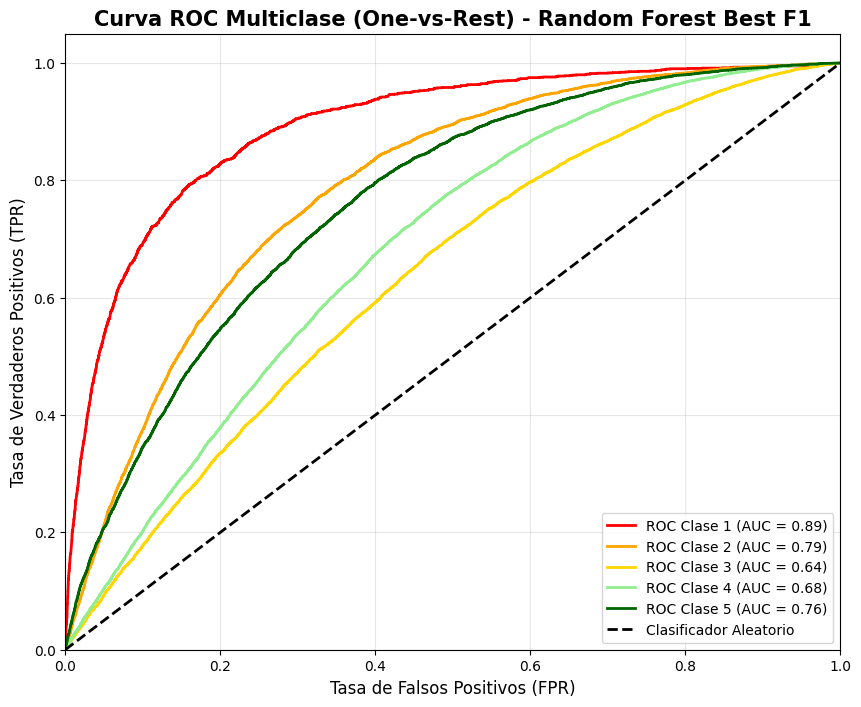

In [73]:
# Binarizamos las etiquetas (Formato One-vs-Rest)
# Convertimos5 en 5 columnas de 0s y 1s
clases = [1, 2, 3, 4, 5]
y_test_bin = label_binarize(y_test, classes=clases)
n_classes = y_test_bin.shape[1]

# Obtenemos el % de seguridad en la predicción
y_prob = modelo_4_1_f1.predict_proba(X_test)

# Configuramos el gráfico
plt.figure(figsize=(10, 8))
colores = cycle(['red', 'orange', 'gold', 'lightgreen', 'darkgreen'])

# Bucle para calcular y dibujar la curva de cada clase
for i, color in zip(range(n_classes), colores):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'ROC Clase {clases[i]} (AUC = {roc_auc:.2f})')

# Línea de suerte pura (clasificador aleatorio)
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Clasificador Aleatorio')

# Detalles estéticos
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
plt.ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=12)
plt.title('Curva ROC Multiclase (One-vs-Rest) - Random Forest Best F1', fontsize=15, fontweight='bold')
plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.3)

plt.show()

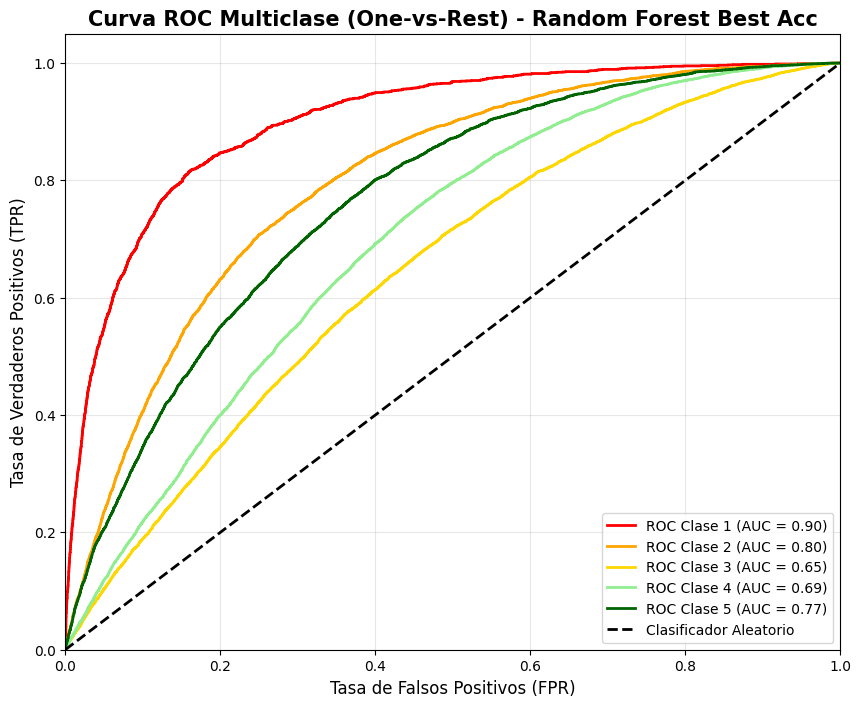

In [74]:
# Binarizamos las etiquetas (Formato One-vs-Rest)
# Convertimos5 en 5 columnas de 0s y 1s
clases = [1, 2, 3, 4, 5]
y_test_bin = label_binarize(y_test, classes=clases)
n_classes = y_test_bin.shape[1]

# Obtenemos el % de seguridad en la predicción
y_prob = modelo_4_1_acc.predict_proba(X_test)

# Configuramos el gráfico
plt.figure(figsize=(10, 8))
colores = cycle(['red', 'orange', 'gold', 'lightgreen', 'darkgreen'])

# Bucle para calcular y dibujar la curva de cada clase
for i, color in zip(range(n_classes), colores):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'ROC Clase {clases[i]} (AUC = {roc_auc:.2f})')

# Línea de suerte pura (clasificador aleatorio)
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Clasificador Aleatorio')

# Detalles estéticos
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
plt.ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=12)
plt.title('Curva ROC Multiclase (One-vs-Rest) - Random Forest Best Acc', fontsize=15, fontweight='bold')
plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.3)

plt.show()

Si comparamos las matrices de confusión de los dos modelos observamos notables diferencias, sin embargo vemos una extrema similitud en las curvas AUC-ROC. Esto último nos indica que ambos modelos poseen una capacidad de discriminación y ordenamiento (ranking) casi idéntica. Mientras que el Accuracy y el F1-Score son métricas dependientes de un umbral de decisión específico, el AUC evalúa el potencial del modelo de forma independiente al umbral. Esto explica por qué las curvas coinciden: el modelo con mejor *accuracy* es más conservador y el que tiene mejor *F1 Score* es más arriesgado al asignar etiquetas, pero ambos mantienen prácticamente el mismo orden de probabilidades. Estas curvas nos permiten observar que el modelo no ha mejorado su capacidad de separar las clases, sino que simplemente ha desplazado el *threshold* de descisión para priorizar el acierto global o la recuperación de clases minoritarias.

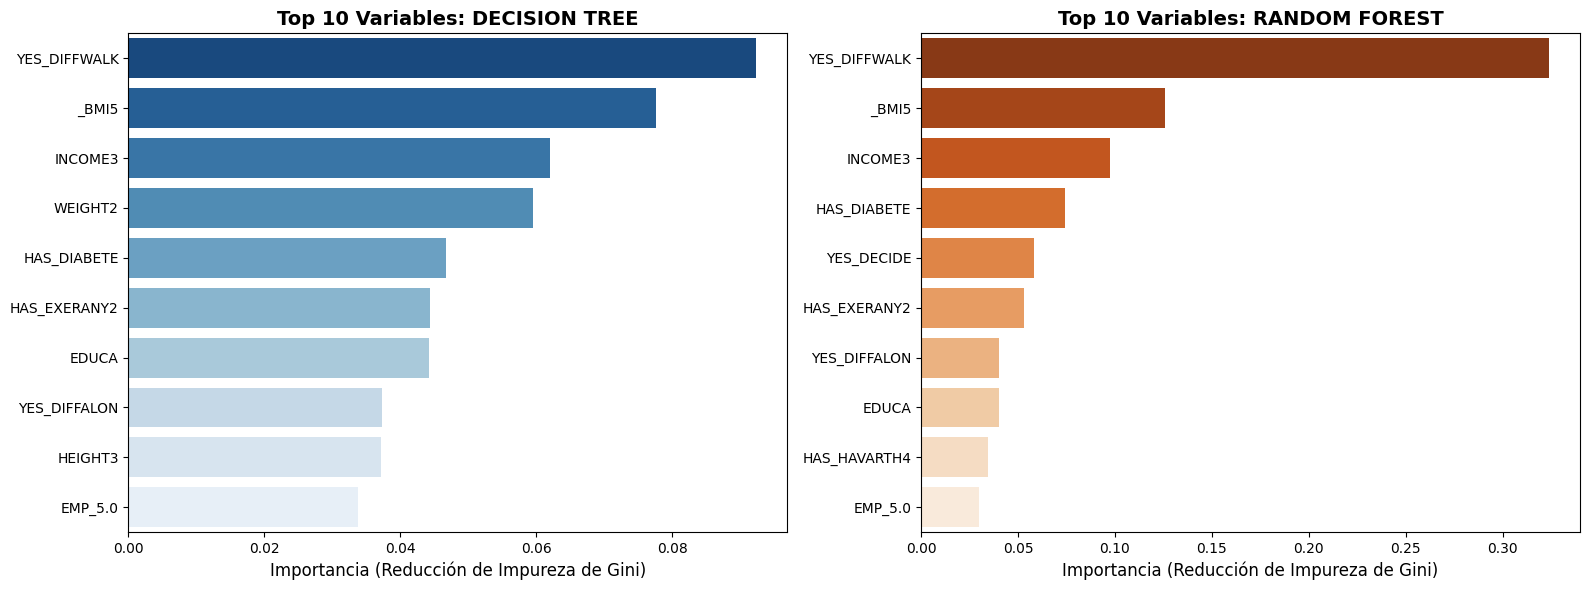

In [75]:
# Extraemos la importancia del Decision Tree (modelo_4_1_acc)
importancias_dt = modelo_4_1_acc.feature_importances_
df_dt = pd.DataFrame({'Variable': X_train.columns, 'Importancia_DT': importancias_dt})
top10_dt = df_dt.sort_values(by='Importancia_DT', ascending=False).head(10)

# Extraemos la importancia del Random Forest (modelo_3_1_acc)
importancias_rf = modelo_3_1_acc.feature_importances_
df_rf = pd.DataFrame({'Variable': X_train.columns, 'Importancia_RF': importancias_rf})
top10_rf = df_rf.sort_values(by='Importancia_RF', ascending=False).head(10)

# GRÁFICO DOBLE
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico Izquierda: Decision Tree
sns.barplot(x='Importancia_DT', y='Variable', data=top10_dt, ax=axes[0], palette='Blues_r', hue='Variable', legend=False)
axes[0].set_title('Top 10 Variables: DECISION TREE', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Importancia (Reducción de Impureza de Gini)', fontsize=12)
axes[0].set_ylabel('')

# Gráfico Derecha: Random Forest
sns.barplot(x='Importancia_RF', y='Variable', data=top10_rf, ax=axes[1], palette='Oranges_r', hue='Variable', legend=False)
axes[1].set_title('Top 10 Variables: RANDOM FOREST', fontsize=14, fontweight='bold')
# ¡Corregido! El RF también usa la impureza de Gini
axes[1].set_xlabel('Importancia (Reducción de Impureza de Gini)', fontsize=12)
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

Al comparar la importancia de características (basada en la reducción de la impureza de Gini) entre el Árbol de Decisión simple y el Random Forest, observamos notables diferencias:

- El Árbol de Decisión muestra un perfil de importancia más diluido (su variable principal no alcanza el 10%). Esto es síntoma de un modelo profundo, si recordamos se trata de un árbol con profundidad máxima de 25. Lo que a menudo conduce a memorizar ruido (overfitting).

- Por el contrario, el Random Forest revela que al promediar múltiples árboles independientes, el ruido desaparece y determina que YES_DIFFWALK (Dificultad severa para caminar) acumula por sí sola más del 30% del poder predictivo, seguida del IMC (_BMI5).

En definitiva, el Random Forest nos demuestra que no necesitamos 30 variables para evaluar el estado general de salud de un paciente. La movilidad física (YES_DIFFWALK), el peso (_BMI5) y el nivel adquisitivo/social (INCOME3, EDUCA) forman el grupo principal de variables que separa a los individuos según su nivel de salud para este modelo.

## 4.2 Clustering

En esta sección abandonamos la predicción para comenzar con el descubrimiento de patrones. El objetivo es utilizar algoritmos de clustering para descubrir si existen perfiles de individuos basándonos exclusivamente en las variables del conjunto de datos relativas a su contexto sociodemográfico y sus hábitos.

### Adaptación de los datos

Para asegurar que el algoritmo descubra patrones reales y no separe a los individuos únicamente por su estado de salud, tanto directamente con la variable `HEALTH` como indirectamente con variables que influyen en la misma como `PHYSHLTH`, `MENTHLTH` o `POORHLTH`, debemos realizar una limpieza previa.

- Retiramos todas las variables relacionadas con el estado de salud y el peso (IMC) ya que queremos obligar al modelo a agrupar por estilo de vida y contexto social y económico.

- Para evitar el colapso de la memoria RAM por ejemplo a la hora de encontrar el mejor *k* posible, extraemos una muestra representativa de 10.000 pacientes.

- De nuevo escalamos los datos para evitar que variables con rangos amplios dominen sobre las variables binarias.

In [76]:
# Eliminación de variables
excluir_clustering = ['HEALTH', 'GENHLTH', 'PHYSHLTH', 'MENTHLTH', 'POORHLTH',
                      'SAY_PHYSHLTH', 'SAY_MENTHLTH', '_BMI5', 'WEIGHT2', 'HEIGHT3']

X_clust = data.drop(columns=[col for col in excluir_clustering if col in data.columns])

# Extracción de la muestra
X_clust_sample = X_clust.sample(n=10000, random_state=42)

# Escalado de Datos
scaler_clust = StandardScaler()
X_clust_sample_scaled = scaler_clust.fit_transform(X_clust_sample)
X_clust_scaled = scaler_clust.transform(X_clust)

print(f"Datos originales: {X_clust.shape[0]} filas y {X_clust_sample.shape[1]} variables.")
print(f"Muestra para clustering: {X_clust_sample.shape[0]} filas y {X_clust_sample.shape[1]} variables.")

Datos originales: 421602 filas y 56 variables.
Muestra para clustering: 10000 filas y 56 variables.


### Búsqueda del número óptimo de clústeres (*k*)

El algoritmo *K-Means* requiere definir previamente la cantidad de grupos a formar. Evaluaremos un rango de *k* (desde 2 hasta 10 clústeres) utilizando dos métricas de validación complementarias para asegurar una partición matemática robusta:

- **Regla del Codo (Inercia):** La inercia calcula la distancia total entre cada punto de datos y el centroide de su clúster. Se define de la siguiente manera:

$$
\text{Inercia} = \sum_{k=1}^{K} \sum_{x_i \in C_k} ||x_i - \mu_k||^2
$$

Al calcular la inercia para diferentes valores de $k$ y graficarla frente a los mismos, el punto donde la disminución de la inercia sea más notable (formando un "codo" en la gráfica) se considera el número óptimo de clústeres.

- **Coeficiente de Silueta:** Mide cómo de similar es un objeto a su propio clúster en comparación con otros clústeres. A diferencia de la inercia, no asume que los clústeres tienen forma esférica y su valor siempre está acotado entre -1 y 1. Se calcula primero para cada punto de datos individual $i$ y luego se saca el promedio para obtener la métrica global del modelo.

$$
s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}
$$

  - Cercano a 1: El punto está muy bien clasificado en su clúster y lejos de los demás.

  - Cercano a 0: El punto está en la frontera entre dos clústeres.

  - Cercano a -1: El punto probablemente está en el clúster equivocado.

Para obtener resultados estables y que no sean fruto de la asignación aleatrioa inicial de los centroides configuramos el algoritmo para realizar 20 intentos aleatorios por cada valor de *k*. Para cálculos como la incercia siempre devuelve el mínimo encontrado en estas 20 pruebas.


Calculando K-Means para diferentes valores de K (Clústeres)...
K=2 | Inercia: 471675 | Silueta: 0.4896
K=3 | Inercia: 436526 | Silueta: 0.1434
K=4 | Inercia: 414869 | Silueta: 0.1287
K=5 | Inercia: 398524 | Silueta: 0.1321
K=6 | Inercia: 383439 | Silueta: 0.0739
K=7 | Inercia: 373650 | Silueta: 0.0790
K=8 | Inercia: 366292 | Silueta: 0.0722
K=9 | Inercia: 358281 | Silueta: 0.0785
K=10 | Inercia: 350758 | Silueta: 0.0877


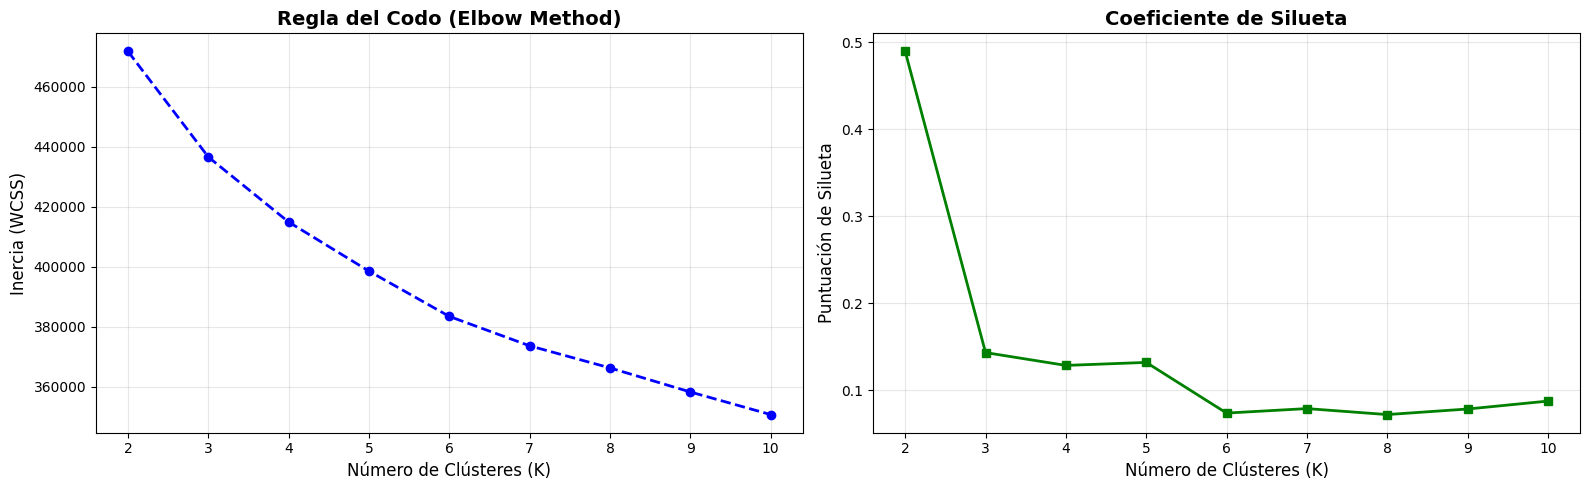

In [77]:
# Probamos desde 2 hasta 10 grupos
rango_k = range(2,11)
inercias = []
siluetas = []

print("Calculando K-Means para diferentes valores de K (Clústeres)...")

for k in rango_k:
    start_time = time.time()

    # Tiramos 20 veces al azar los centroides para empezar
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=20)
    kmeans.fit(X_clust_sample_scaled)

    # Guardamos la Inercia (para la Regla del codo)
    inercias.append(kmeans.inertia_)

    # Guardamos la Silueta (mide lo bien separados que están los grupos)
    score_silueta = silhouette_score(X_clust_sample_scaled, kmeans.labels_)
    siluetas.append(score_silueta)

    print(f"K={k} | Inercia: {kmeans.inertia_:.0f} | Silueta: {score_silueta:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Gráfico 1: Regla del Codo (Inercia)
axes[0].plot(rango_k, inercias, marker='o', linestyle='--', color='blue', linewidth=2)
axes[0].set_title('Regla del Codo (Elbow Method)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Número de Clústeres (K)', fontsize=12)
axes[0].set_ylabel('Inercia (WCSS)', fontsize=12)
axes[0].grid(alpha=0.3)

# Gráfico 2: Coeficiente de Silueta
axes[1].plot(rango_k, siluetas, marker='s', linestyle='-', color='green', linewidth=2)
axes[1].set_title('Coeficiente de Silueta', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Número de Clústeres (K)', fontsize=12)
axes[1].set_ylabel('Puntuación de Silueta', fontsize=12)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Interpretación de métricas y selección de *k*

Si analizamos ambas gráficas observamos como para la incercia no existe un codo real, si no que esta va descendidendo progresivamente. Esto no nos aporta información relevante para decidir cuál será el *k* ideal. En cuanto a la silueta sí que observamos un valor más alto, alrededor de 0.5, para *k=2* y se reduce drásticamente a partir de los 3 clústers.

Basándonos únicamente en el coeficiente de silueta elegimos *k=2* por el alto valor en el mismo. Debido a la falta de información por parte de la regla del codo consideramos también *k=5* ya que nuestra variable `HEALTH` separa en 5 grupos, de esta manera veremos si el algoritmo es capaz de separar estos perfiles.

### 4.2.1 *K*-Means (k=2)

In [78]:
k = 2

kmeans_2 = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=20)
kmeans_2.fit(X_clust_scaled)

# Asignamos la etiqueta del clúster al dataset de muestra original (sin escalar)
df_clusters = X_clust.copy()
df_clusters['Cluster'] = kmeans_2.labels_

print("Entrenamiento completado.")
print(f"Pacientes en el Clúster 0: {(df_clusters['Cluster'] == 0).sum()}")
print(f"Pacientes en el Clúster 1: {(df_clusters['Cluster'] == 1).sum()}")

Entrenamiento completado.
Pacientes en el Clúster 0: 17258
Pacientes en el Clúster 1: 404344


### Visualización con PCA

Para poder visualizar los clústeres formados con *k-means* para *k=2* aplicamos un análisis de componentes principales con dos ejes.

Información primera componente: 18.17%
Información segunda componente: 8.20%
Total de información con dos componentes: 26.37%



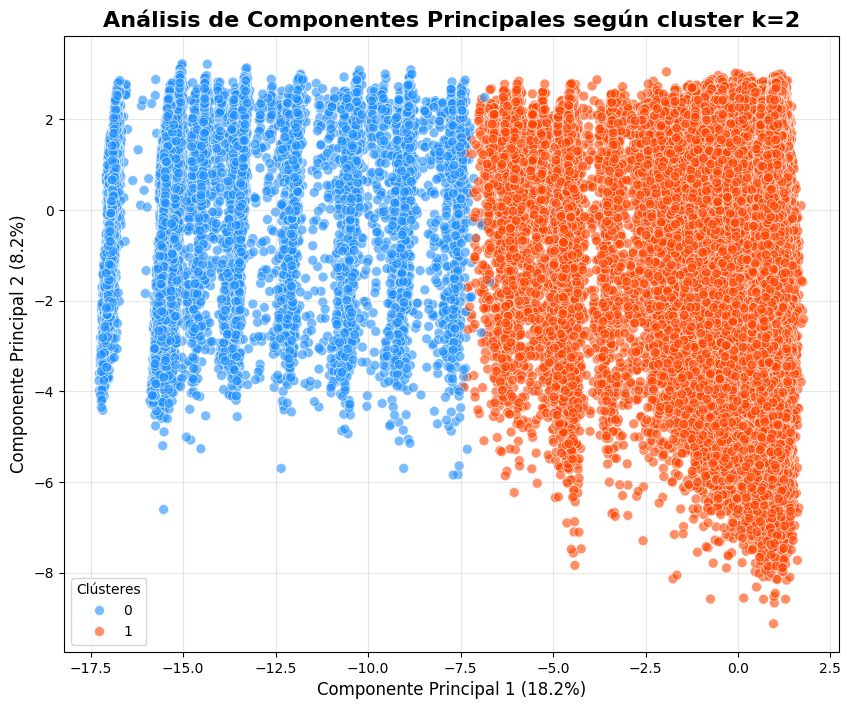

In [79]:
# Aplicamos PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_clust_scaled)

# Añadimos las nuevas coordenadas al df
df_clusters['PCA1'] = X_pca[:, 0]
df_clusters['PCA2'] = X_pca[:, 1]

# Calculamos la varianza explicada por cada eje
var_explicada = pca.explained_variance_ratio_
print(f"Información primera componente: {var_explicada[0]*100:.2f}%")
print(f"Información segunda componente: {var_explicada[1]*100:.2f}%")
print(f"Total de información con dos componentes: {sum(var_explicada)*100:.2f}%\n")

# Visualización
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='PCA1', y='PCA2',
    hue='Cluster',
    palette=['dodgerblue', 'orangered'],
    data=df_clusters,
    alpha=0.6,
    s=50
)

plt.title('Análisis de Componentes Principales según cluster k=2', fontsize=16, fontweight='bold')
plt.xlabel(f'Componente Principal 1 ({var_explicada[0]*100:.1f}%)', fontsize=12)
plt.ylabel(f'Componente Principal 2 ({var_explicada[1]*100:.1f}%)', fontsize=12)
plt.legend(title='Clústeres', loc = 'lower left')
plt.grid(alpha=0.3)

plt.show()

Observamos que la frontera de decisión entre el clúster 0 (azul) y el clúster 1 (naranja) es completamente vertical. Esto indica que la primera componente (responsable del 18.2% de la varianza total) es la que explica en exclusiva las diferencias entre los grupos.

Como hemos visto que *k-means* está diferenciando los clusters en base a la primera componente vamos a graficar los *loadings* del análisis de componentes principales para así obervar qué variables tienen influencia en esta primera componente.

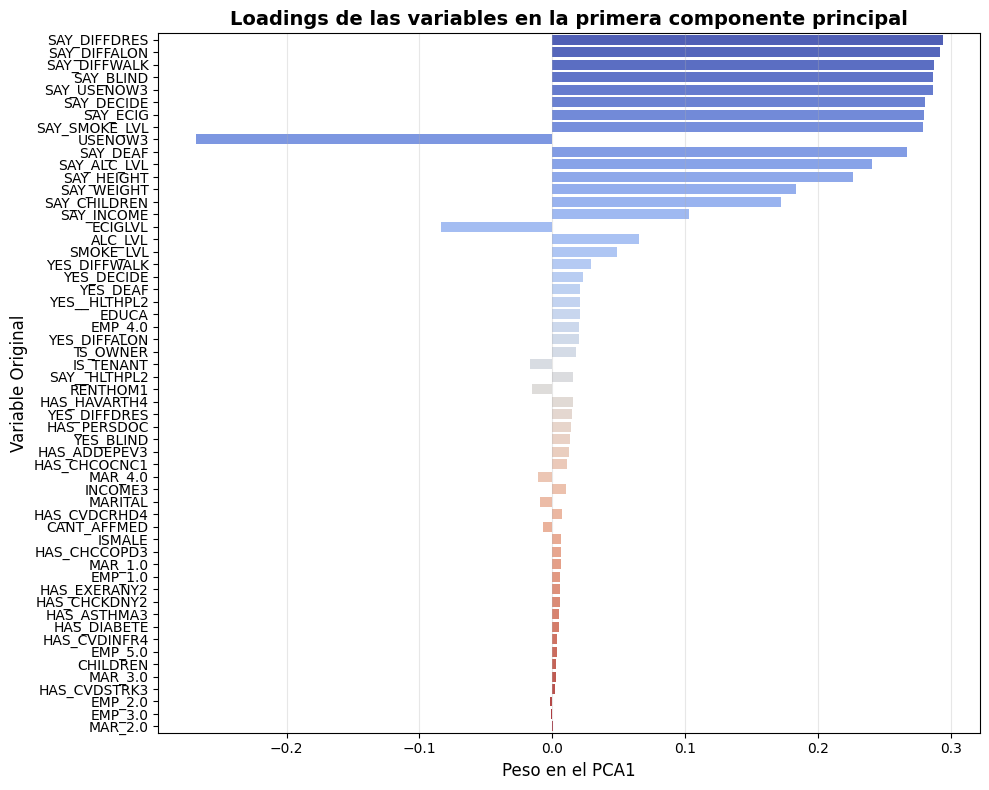

In [80]:
# Extracción de los loadings del modelo PCA
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PCA1', 'PCA2'],
    index=X_clust.columns
)

# Ordenamos los loadings de la primera componente
loadings_pca1 = loadings['PCA1'].sort_values(key=abs, ascending=False)

# Visualización de los pesos en el PCA1
plt.figure(figsize=(10, 8))
sns.barplot(
    x=loadings_pca1.values,
    y=loadings_pca1.index,
    hue=loadings_pca1.index,
    palette='coolwarm',
    legend=False
)
plt.title('Loadings de las variables en la primera componente principal', fontsize=14, fontweight='bold')
plt.xlabel('Peso en el PCA1', fontsize=12)
plt.ylabel('Variable Original', fontsize=12)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

Observamos cómo lo que está haciendo el algoritmo de *k-means* es separar en dos clusters principalmente entre los individuos que contestaron a ciertas preguntas comprometidas y los que no ya que las variables que más contribuyen a formar esta primera componente son las binarias:

- SAY_DIFFDRES
- SAY_DIFFALON
- SAY_DIFFWALK
- SAY_BLIND
- SAY_USENOW3
- SAY_DECIDE
- SAY_ECIG
- SAY_SMOKELVL
- SAY_DEAF
- SAY_ALCLVL
- SAY_WEIGHT
- SAY_HEIGHT
- SAY_CHILDREN
- SAY_INCOME

Junto con USENOW3 que se cuela en medio de la lista. Recordamos que esta variable corresponde al uso de tabaco de mascar y derivados.

### Diferencias entre clústers

Añadimos ahora las variables sociodemográficas, de hábitos y las de salud/IMC para observar si existen diferencias para los dos clústers creados.

Primero comenzamos haciendo un gráfico de barras por clúster de las dos variables más importantes del trabajo, el `_BMI5` y `HEALTH`.

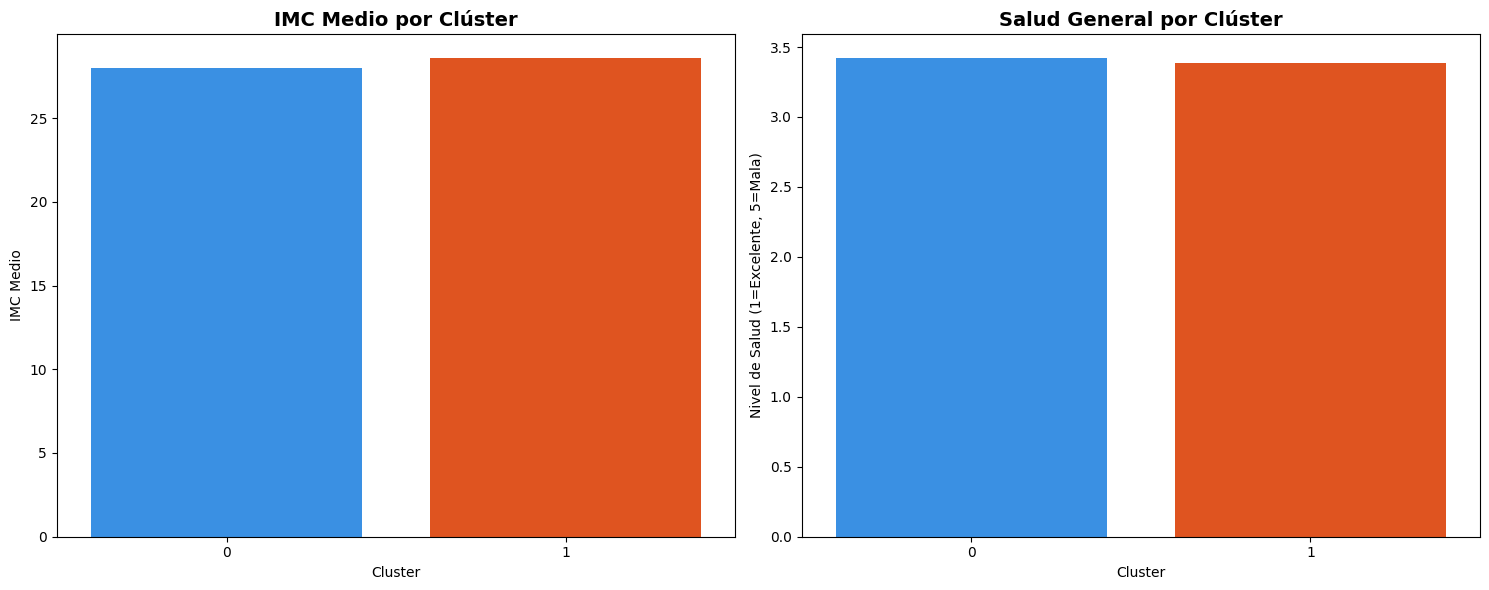

In [81]:
df_diferencias = data.loc[df_clusters.index].copy()
df_diferencias['Cluster'] = df_clusters['Cluster']

variables_analisis = [
    '_BMI5', 'HEALTH', 'INCOME3', 'EDUCA',
    'YES_DIFFWALK', 'HAS_EXERANY2', 'HAS_DIABETE', 'HAS_HAVARTH4'
]

# Media de cada variable para cada clúster
perfiles = df_diferencias.groupby('Cluster')[variables_analisis].mean()

perfiles['Tamaño_Muestra'] = df_diferencias.groupby('Cluster').size()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Comparación de IMC
sns.barplot(
    x='Cluster',
    y='_BMI5',
    data=perfiles.reset_index(),
    ax=axes[0],
    palette=['dodgerblue', 'orangered'],
    hue='Cluster',
    legend=False
)
axes[0].set_title('IMC Medio por Clúster', fontsize=14, fontweight='bold')
axes[0].set_ylabel('IMC Medio')

# Comparación de Salud
sns.barplot(
    x='Cluster',
    y='HEALTH',
    data=perfiles.reset_index(),
    ax=axes[1],
    palette=['dodgerblue', 'orangered'],
    hue='Cluster',
    legend=False
)
axes[1].set_title('Salud General por Clúster', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Nivel de Salud (1=Excelente, 5=Mala)')

plt.tight_layout()
plt.show()

Las diferencias son mínimas luego la agrupación en 2 clústers no ha conseguido separar a los individuos según su nivel de salud.

Veamos para el resto de variables relevantes.

In [82]:
display(perfiles.T)

Cluster,0,1
_BMI5,28.013733,28.571296
HEALTH,3.419863,3.386038
INCOME3,6.903291,7.067920
EDUCA,4.855487,5.057186
YES_DIFFWALK,0.005563,0.152857
HAS_EXERANY2,0.749681,0.775968
HAS_DIABETE,0.132866,0.149086
HAS_HAVARTH4,0.271005,0.346223
Tamaño_Muestra,17258.000000,404344.000000


Se observa una diferencia en la variable `YES_DIFFWALK` mientras que el resto se mantienen muy similares.

### 4.2.2 *K*-Means (k=5)

In [83]:
k = 5

kmeans_5 = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=20)
kmeans_5.fit(X_clust_scaled)

# Asignamos la etiqueta del clúster al dataset de muestra original (sin escalar)
df_clusters = X_clust.copy()
df_clusters['Cluster'] = kmeans_5.labels_

print("Entrenamiento completado.")

for i in range(k):
    print(f"Pacientes en el Clúster {i}: {(df_clusters['Cluster'] == i).sum()}")

Entrenamiento completado.
Pacientes en el Clúster 0: 226898
Pacientes en el Clúster 1: 63587
Pacientes en el Clúster 2: 14459
Pacientes en el Clúster 3: 11928
Pacientes en el Clúster 4: 104730


### Visualización con PCA

Para poder visualizar los clústeres formados con *k-means* para *k=5* aplicamos un análisis de componentes principales con dos ejes. Como ya hemos calculado las coordenadas de cada punto con PCA, basta asignar a que cluster pertenece cada punto según el nuevo algoritmo de *k-means* con *k=5*

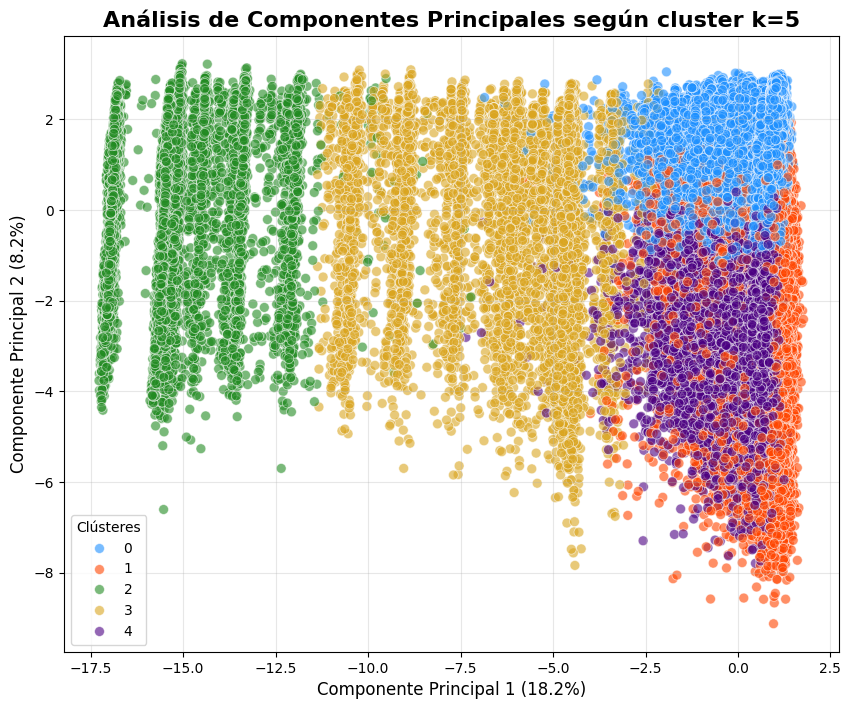

In [84]:
# Añadimos las nuevas coordenadas al df
df_clusters['PCA1'] = X_pca[:, 0]
df_clusters['PCA2'] = X_pca[:, 1]

# Visualización
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='PCA1', y='PCA2',
    hue='Cluster',
    palette=['dodgerblue', 'orangered', 'forestgreen', 'goldenrod', 'indigo'],
    data=df_clusters,
    alpha=0.6,
    s=50
)

plt.title('Análisis de Componentes Principales según cluster k=5', fontsize=16, fontweight='bold')
plt.xlabel(f'Componente Principal 1 ({var_explicada[0]*100:.1f}%)', fontsize=12)
plt.ylabel(f'Componente Principal 2 ({var_explicada[1]*100:.1f}%)', fontsize=12)
plt.legend(title='Clústeres', loc = 'lower left')
plt.grid(alpha=0.3)

plt.show()

Observamos que la frontera de decisión entre el clúster 2 (verde) y el clúster 3 (amarillo) vuelve a ser completamente vertical. Lo mismo sucede entre este último y el resto. Esto indica que la primera componente (responsable del 18.2% de la varianza total) es la que continúa explicando en exclusiva las diferencias entre estos grupos. Para los otros 3 clústeres observamos como la única división observabel es entre los clústers 0 y 4, que se dividen aproximádamente por una línea horizontal en 'y=0'.

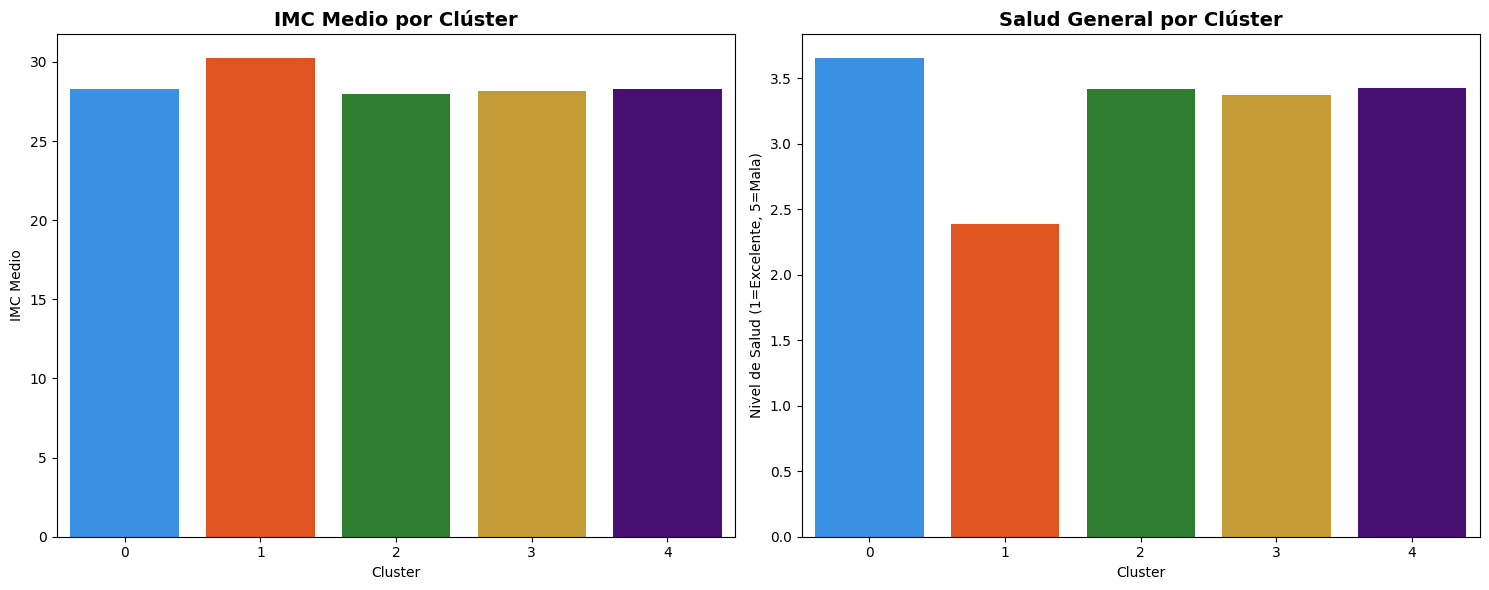

In [85]:
df_diferencias = data.loc[df_clusters.index].copy()
df_diferencias['Cluster'] = df_clusters['Cluster']

variables_analisis = [
    '_BMI5', 'HEALTH', 'INCOME3', 'EDUCA',
    'YES_DIFFWALK', 'HAS_EXERANY2', 'HAS_DIABETE', 'HAS_HAVARTH4', 'EMP_1.0',
    'EMP_2.0', 'EMP_3.0', 'EMP_4.0', 'EMP_5.0', 'IS_OWNER', 'IS_TENANT', 'ISMALE'
]

# Media de cada variable para cada clúster
perfiles = df_diferencias.groupby('Cluster')[variables_analisis].mean()

perfiles['Tamaño_Muestra'] = df_diferencias.groupby('Cluster').size()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Comparación de IMC
sns.barplot(
    x='Cluster',
    y='_BMI5',
    data=perfiles.reset_index(),
    ax=axes[0],
    palette=['dodgerblue', 'orangered', 'forestgreen', 'goldenrod', 'indigo'],
    hue='Cluster',
    legend=False
)
axes[0].set_title('IMC Medio por Clúster', fontsize=14, fontweight='bold')
axes[0].set_ylabel('IMC Medio')

# Comparación de Salud
sns.barplot(
    x='Cluster',
    y='HEALTH',
    data=perfiles.reset_index(),
    ax=axes[1],
    palette=['dodgerblue', 'orangered', 'forestgreen', 'goldenrod', 'indigo'],
    hue='Cluster',
    legend=False
)
axes[1].set_title('Salud General por Clúster', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Nivel de Salud (1=Excelente, 5=Mala)')

plt.tight_layout()
plt.show()

A pesar de que los ejes no separan aparentemente los clusters 0 (azul) y 1(naranja) existe una clara diferencia entre las variables objetivo entre ambos clústers.

- El IMC medio es superior para el clúster naranja (entorno a 30) en comparación con el resto de clústers (entre 27 y 28).

- La puntuación de salud es en promedio 1 punto inferior para el clúster 1 (naranja) con respecto al 0 (azul). Sin embargo también observamos que el azul está unas décimas por encima del resto, superando a los 3.5 puntos de media.

Estos datos confirman que el clúster 1 (naranja) está agrupando individuos con peor salud y más peso, mientras que el clúster 0 (azul) aunque agrupa individuos en promedio con el mismo IMC que el resto de clústers, sí tiene una media de salud más alta.

Viendo ques e ha conseguido diferenciar entre la salud del clúster 1 y el resto vamos a ver cómo es el perfil sociodemográfico de estos individuos.

In [86]:
display(perfiles.T)

Cluster,0,1,2,3,4
_BMI5,28.265115,30.231887,28.001660,28.155684,28.260508
HEALTH,3.651553,2.383711,3.419531,3.370137,3.422124
INCOME3,7.918501,5.392219,6.889757,6.844567,6.265444
EDUCA,5.319602,4.622832,4.836157,4.960010,4.760728
YES_DIFFWALK,0.048295,0.692406,0.000069,0.133216,0.050864
HAS_EXERANY2,0.857606,0.466967,0.748876,0.749162,0.789172
HAS_DIABETE,0.119591,0.371570,0.131337,0.154175,0.077103
HAS_HAVARTH4,0.329747,0.734789,0.264610,0.343561,0.145173
EMP_1.0,0.557563,0.088037,0.450861,0.480969,0.657080
EMP_2.0,0.017973,0.036973,0.038454,0.038229,0.098043


En esta tabla se puede observar cómo para los individuos del clúster 1 (5.39) la media de ingresos es más baja que para el resto de clústers siendo la más alta notablemente la del clúster 0 (7.9).

El nivel de educación también se ve afectado siendo el nivel más alto el de los individuos del clúster 0 (media de 5.32) y el más bajo el del clúster 1 (media de 4.62).

Diferencias enormes también las existentes entre la proporción de individuos que puede caminar y la que no entre el clúster 0 y el resto. La cifra es del 70% para este frente a un 13% o un 5% en los más altos.

En cuanto al deporte, mientras que en el 85% de los individuos del clúster 0 (sano) hizo deporte el último mes, solo el 47% de los individuos del clúster 1 (peor salud) lo hizo.

También son notablemente más altos en este clúster 1 los porcentajes de individuos con diabetes (37%) y con artritis (73%).

En cuanto a los puestos de trabajo tenemos que un 55% de los individuos del primer clúster están activos laboralmente, mientras que solo el 8% de los individuos del clúster 0 lo están. El otro dato relevante es que el 56% de las personas del clúster 1 (peor salud) son jubilados, lo que podría explicar la baja salud media del grupo, sin embargo en el clúster 0 (mejor salud) también tenemos un gran porcentaje de jubilados, concretamente un 37%. Donde si encontramos diferencias sustanciales es en el porcentaje de incapacitados para trabajar, que llega en el clúster 1 al 27% mientras que en el resto de clústeres no supera el 6%.

Por último vemos como en el clúster 0 (sanos) el 99% es dueño de una vivienda y menos del 1% vive de alquiler, mientras que en el clúster 1 (peor salud) solo el 67% es propietario.

### 4.2.3 DBSCAN

Con la intención de probar otro modelo diferente al *K-Means* que ya conocíamos de otras asignaturas y proyectos, vamos a tratar de implementar el DBSCAN que desconocíamos hasta haberlo visto en la asignatura.

A diferencia de *K-Means*, DBSCAN (*Density-Based Spatial Clustering of Applications with Noise*) modela clústeres como regiones continuas de alta densidad separadas por regiones de baja densidad.

El algoritmo depende de dos hiperparámetros estrictos:
- **$\epsilon$ (*eps*):** El radio máximo que define el entorno alrededor de un punto $p$.
- **$min\_samples$:** El número mínimo de observaciones requeridas dentro de un entorno $\epsilon$ para que $p$ sea considerado un punto núcleo.

Para estimar un valor base para $\epsilon$, emplearemos el gráfico *k-distance*. Fijamos $k = min\_samples$ (asumiendo un valor aproximado al doble de la dimensionalidad de nuestros datos, $k=100$) y calculamos la distancia Euclídea de cada observación a su $k$-ésimo vecino más cercano. Al ordenar y graficar estas distancias, buscaremos el 'codo' que nos indique el punto donde la densidad comienza a considerarse ruido.

Utilizaremos la muestra escalada para reducir el coste computacional.

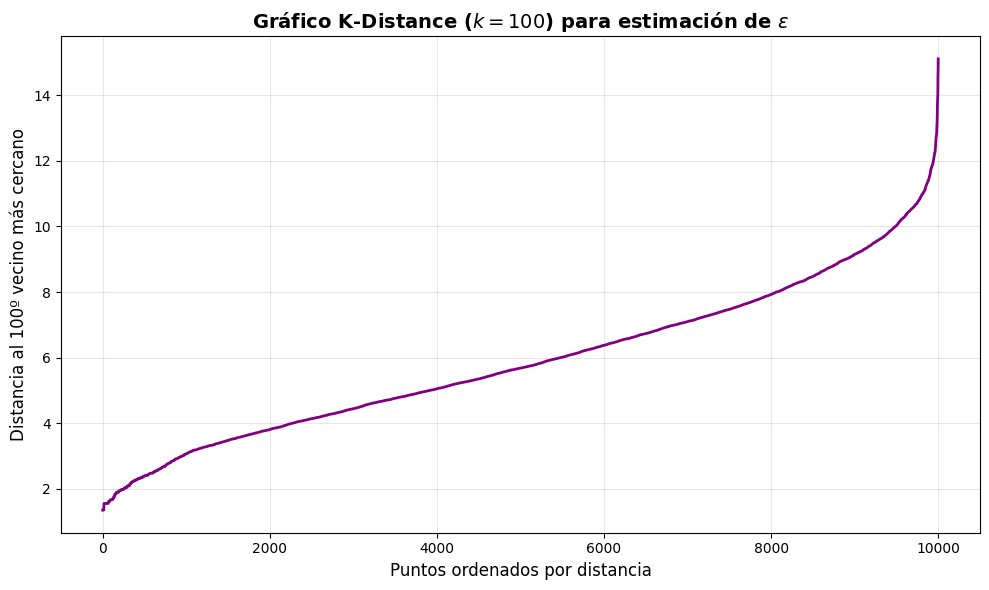

In [87]:
k_vecinos = 100

vecinos = NearestNeighbors(n_neighbors=k_vecinos)
vecinos_fit = vecinos.fit(X_clust_sample_scaled)

# Distancias
distancias, indices = vecinos_fit.kneighbors(X_clust_sample_scaled)

# Ordenamos
distancias_k = np.sort(distancias[:, k_vecinos - 1], axis=0)

# Visualización geométrica
plt.figure(figsize=(10, 6))
plt.plot(distancias_k, color='purple', linewidth=2)
plt.title(f'Gráfico K-Distance ($k={k_vecinos}$) para estimación de $\\epsilon$', fontsize=14, fontweight='bold')
plt.xlabel('Puntos ordenados por distancia', fontsize=12)
plt.ylabel(f'Distancia al {k_vecinos}º vecino más cercano', fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

El gráfico ordena a todos los pacientes (eje X) de menor a mayor en función de la distancia necesaria para englobar a sus 100 vecinos más cercanos en el entorno. Por lo tanto que el punto de máxima curvatura y en el cual a partitr de ahí no obtenemos una mejora considerable es la ordenada $y=10.5$.

Entrenamos DBSCAN con $\epsilon = 10.5$ y $min\_samples = 100$.

Número de clústeres descubiertos: 1
Pacientes clasificados como ruido (outliers): 13 (0.13%)
Cluster_DBSCAN
-1      13
 0    9987
Name: count, dtype: int64


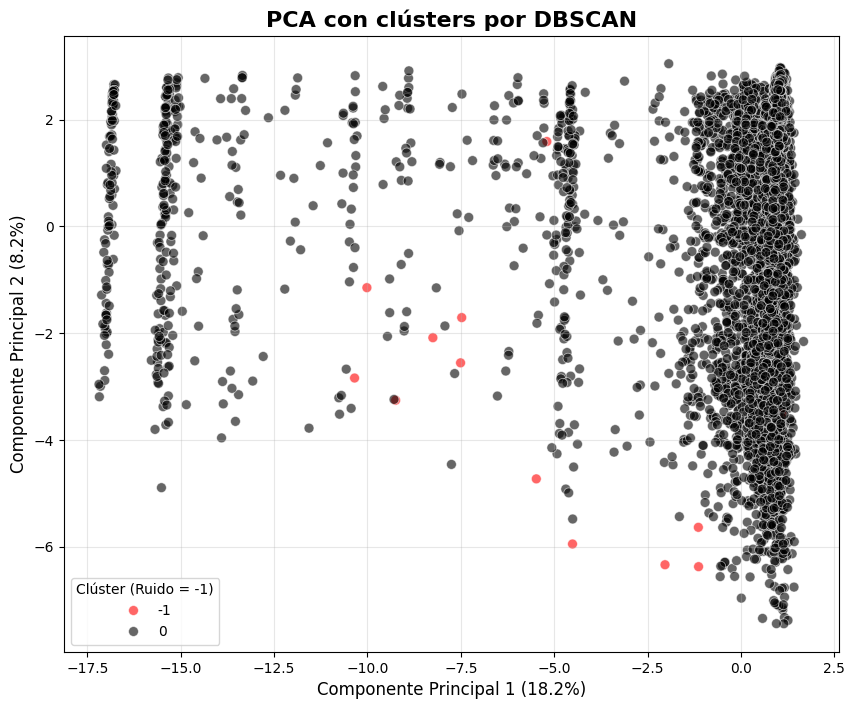

In [88]:
# Parámetros
epsilon = 10.5
min_vecinos = 20

# Entrenamiento del modelo
dbscan = DBSCAN(eps=epsilon, min_samples=min_vecinos, n_jobs=-1)
dbscan.fit(X_clust_sample_scaled)

# Asignación de etiquetas al dataframe de la muestra
df_dbscan = X_clust_sample.copy()
df_dbscan['Cluster_DBSCAN'] = dbscan.labels_

etiquetas = df_dbscan['Cluster_DBSCAN']

# El ruido se etiqueta como -1
n_clusters = len(set(etiquetas)) - (1 if -1 in set(etiquetas) else 0)
n_ruido = list(etiquetas).count(-1)
porcentaje_ruido = (n_ruido / len(etiquetas)) * 100

print(f"Número de clústeres descubiertos: {n_clusters}")
print(f"Pacientes clasificados como ruido (outliers): {n_ruido} ({porcentaje_ruido:.2f}%)")
print(etiquetas.value_counts().sort_index())

# Visualización
X_pca_dbscan = pca.transform(X_clust_sample_scaled)
df_dbscan['PCA1'] = X_pca_dbscan[:, 0]
df_dbscan['PCA2'] = X_pca_dbscan[:, 1]

plt.figure(figsize=(10, 8))

sns.scatterplot(
    x='PCA1', y='PCA2',
    hue='Cluster_DBSCAN',
    palette=['red', 'black'],
    data=df_dbscan,
    alpha=0.6,
    s=50,
    legend='full'
)

plt.title('PCA con clústers por DBSCAN', fontsize=16, fontweight='bold')
plt.xlabel(f'Componente Principal 1 ({var_explicada[0]*100:.1f}%)', fontsize=12)
plt.ylabel(f'Componente Principal 2 ({var_explicada[1]*100:.1f}%)', fontsize=12)
plt.legend(title='Clúster (Ruido = -1)', loc='lower left')
plt.grid(alpha=0.3)

plt.show()

Como vemos DBSCAN nos ayuda únicamente a diferenciar el ruido, concretamente 13 muestras, pero no agrupa en clústers según el nivel de salud como se buscaba.

# 5. Resultados

Recuperamos en esta sección todos los archivos de resultados para encontrar qué modelos de clasificación de los entrenados en todo el notebook maximizan cada métrica.

In [89]:
archivos_clasificacion = {
    'resultados_3_1_1.csv': 'Árbol de Decisión',
    'resultados_3_1_2.csv': 'Regresión Logística',
    'resultados_3_1_3.csv': 'SVC',
    'resultados_4_1_1.csv': 'Random Forest',
    'resultados_4_1_2.csv': 'Gradient Boosting',
    'resultados_4_1_3.csv': 'Stacking'
}

lista_dfs = []

for archivo, nombre_modelo in archivos_clasificacion.items():
    ruta_completa = os.path.join(results_path, archivo)
    if os.path.exists(ruta_completa):
        df_temp = pd.read_csv(ruta_completa)
        # Añadimos una columna para identificar de qué algoritmo viene cada fila
        df_temp['Modelo'] = nombre_modelo
        lista_dfs.append(df_temp)
    else:
        print(f"No se encontró {archivo}")

df_global = pd.concat(lista_dfs, ignore_index=True)

ganador_acc = df_global.loc[df_global['Accuracy'].idxmax()]
ganador_rec = df_global.loc[df_global['Recall_Macro'].idxmax()]
ganador_f1 = df_global.loc[df_global['F1_Macro'].idxmax()]

print(f"MEJOR ACCURACY    : {ganador_acc['Modelo']:<20} ({ganador_acc['Accuracy']:.4f})")
print(f"MEJOR RECALL MACRO: {ganador_rec['Modelo']:<20} ({ganador_rec['Recall_Macro']:.4f})")
print(f"MEJOR F1 MACRO    : {ganador_f1['Modelo']:<20} ({ganador_f1['F1_Macro']:.4f})")

columnas_mostrar = ['Modelo', 'Accuracy', 'Recall_Macro', 'F1_Macro']
display(df_global[columnas_mostrar].sort_values(by='F1_Macro', ascending=False).head(10).reset_index(drop=True))

MEJOR ACCURACY    : Gradient Boosting    (0.4578)
MEJOR RECALL MACRO: Regresión Logística  (0.4406)
MEJOR F1 MACRO    : Random Forest        (0.3806)


,Modelo,Accuracy,Recall_Macro,F1_Macro
0,Random Forest,0.413816,0.378178,0.380618
1,Random Forest,0.409511,0.376989,0.378733
2,Stacking,0.375380,0.436996,0.375876
3,Stacking,0.373707,0.436652,0.374250
4,Stacking,0.373304,0.437067,0.373809
5,Stacking,0.372853,0.435450,0.373357
6,Stacking,0.372593,0.435451,0.373138
7,Stacking,0.372142,0.435392,0.372727
8,Random Forest,0.368121,0.426774,0.372444
9,Stacking,0.371976,0.435296,0.372334


El modelo con un mayor *accuracy* obtenido en toda la práctica ha sido el *Gradient Boosting*, sin embargo como se ha comentado en la sección, se prefiere el *Random Forest* de mayor accuracy (100 árbboles de profundidad 15) ya que las diferencias son mínimas y es un modelo mucho más sencillo.

# Conclusiones

- Gradient Boosting (Mejor Accuracy: 0.4578): Se trata de un modelo con una postura conservadora. Maximiza la tasa de aciertos global concentrando sus predicciones en las categorías mayoritarias (niveles intermedios 3 y 4), pero resulta prácticamente inútil para detectar los casos minoritarios o extremos (salud excelente o muy precaria).

- Regresión Logística (Mejor Recall Macro: 0.4406): Representa el enfoque opuesto. Asegura la detección de los estados de salud críticos y excepcionales (clases 1 y 5). Sin embargo, este riesgo penaliza fuertemente la exactitud global, generando un caos de falsos positivos al desplazar perfiles promedio hacia los extremos.

- Random Forest (Mejor F1 Macro: 0.3806): Se posiciona como la mejor solución general ya que logra el comportamiento más estable al equilibrar la precisión y la exhaustividad, reduciendo la ignorancia de los casos extremos del Gradient Boosting sin llegar al descontrol de falsos positivos de la Regresión Logística. En la práctica, es el modelo estadísticamente más robusto y equitativo de todos.

Recordamos también que para la sección de regresión sobre el IMC el mejor modelo conseguido ha sido el árbol de regresión con:

R2 (Porcentaje de acierto general):  0.1175
MAE (Error absoluto medio en IMC):   4.3394
RMSE (Error cuadrático medio en IMC): 6.0033

Por último, destacar el clústering obtenido con el modelo k-medias y *k=5*, que ha conseguido identificar un grupo de personas con baja salud en función de variables sociodemográficas tal y como se pretendía al principio de la práctica. Aunque este clustering ha detectado mayoritariamente al grupo de jubilados y no se puede asegurar con total certeza, se ha visto que existen indicios de que una peor educación, un sueldo más bajo o ser propietario de una vivienda está asociado a un perfil de persona que cuida más su salud, ya que estas también están ligadas a hacer ejercicio y a no padecer enfermedades como la diabetes o la artritis.

Por último, antes de terminar incorporamos una sección de análisis de sesgos y fairness para estos modelos ganadores.

# 6. Análisis de Sesgos y *Fairness*

- Sesgo por Desbalanceo de Clases: El conjunto de datos original sufre una grave desproporción donde existe una clase predominante sobre las demás. La concentración de encuestados en los niveles de salud 3 y 4 ha provocado que los modelos asimilaran este sesgo, anulando su capacidad para detectar las clases minoritarias (1 y 5). Al aplicar técnicas de preproceso e hiperparámetros como los pesos balanceados (class_weight='balanced') tratamos de solucionar esto pero a la vez inducimos un sesgo algorítmico. Algoritmos como la Regresión Logística o el Stacking han sobrecompensado a las minorías, asumiendo riesgos excesivos que redujeron demasiado el *accuracy* global.

- Discriminación Explicable: Los árboles de decisión discriminan radicalmente a los individuos en función de su dificultad para caminar (YES_DIFFWALK). En este contexto médico, representa una discriminación explicable, puesto que se trata de un motivo directamente vinculado al estado de salud físico.

Queremos ver también si los modelos discriminan por sexo, para ello veamos cómo es la distribución de hombres y mujeres en cada una de las clases originales del dataset.

In [90]:
print(f"Porcenaje de hombres en el conjunto de datos", data['ISMALE'].mean().round(4)*100)

data_fairness = df_clean.loc[:,['HEALTH','_BMI5','ISMALE']].dropna()

data_male = data_fairness.groupby('HEALTH')['ISMALE'].agg(['count', 'mean'])
data_male.columns = ['Total_Registros', 'Porcentaje_Hombres']
data_male['Porcentaje_Hombres'] = data_male['Porcentaje_Hombres'] * 100
print(data_male)

Porcenaje de hombres en el conjunto de datos 47.27
        Total_Registros  Porcentaje_Hombres
HEALTH                                     
1.0               21217           45.482396
2.0               66029           45.955565
3.0              154470           47.753609
4.0              145040           46.838114
5.0               63899           50.880295


Como vemos no hay apenas diferencias entre clases de salud. Un 47% del total de la muestra son hombres y aproximadamente se tiene la misma cantidad en cada clase, salvo un 45.48% en la clase 1 y un 50.88% en la clase 5.

Veamos cómo son las predicciones de los 3 mejores modelos, teniendo en cuenta el *Random Forest* en lugar del *Gradient Boosting* como se ha comentado.

In [91]:
ismale_val = X_val['ISMALE'].values

modelos_ganadores = {
    'Random Forest (Mejor Accuracy) [4_1_1]': (modelo_acc_4_1_1, False),
    'Regresión Logística (Mejor Recall) [3_1_2]': (modelo_f1_3_1_2, True),
    'Random Forest (Mejor F1) [4_1_1]': (modelo_f1_4_1_1, False)
}

for nombre_modelo, (modelo, usa_escalado) in modelos_ganadores.items():

    # Seleccionamos los datos correctos para predecir
    X_eval = X_val_scaled if usa_escalado else X_val
    y_pred = modelo.predict(X_eval)

    # Creamos un DataFrame temporal uniendo las predicciones del modelo y la variable de sexo
    df_fairness_pred = pd.DataFrame({
        'HEALTH_Predicho': y_pred,
        'ISMALE': ismale_val
    })

    data_male_pred = df_fairness_pred.groupby('HEALTH_Predicho')['ISMALE'].agg(['count', 'mean'])
    data_male_pred.columns = ['Total_Registros', 'Porcentaje_Hombres (%)']
    data_male_pred['Porcentaje_Hombres (%)'] = data_male_pred['Porcentaje_Hombres (%)'] * 100

    print(f"Distribución predicha por: {nombre_modelo}")
    display(data_male_pred.round(2))

Distribución predicha por: Random Forest (Mejor Accuracy) [4_1_1]


,Total_Registros,Porcentaje_Hombres (%)
HEALTH_Predicho,,
1.0,1333,43.44
2.0,6659,37.93
3.0,37117,47.78
4.0,39131,48.80
5.0,80,13.75


Distribución predicha por: Regresión Logística (Mejor Recall) [3_1_2]


,Total_Registros,Porcentaje_Hombres (%)
HEALTH_Predicho,,
1.0,8693,46.35
2.0,12714,42.56
3.0,16368,48.30
4.0,18602,38.94
5.0,27943,54.96


Distribución predicha por: Random Forest (Mejor F1) [4_1_1]


,Total_Registros,Porcentaje_Hombres (%)
HEALTH_Predicho,,
1.0,1783,43.63
2.0,9501,39.81
3.0,31381,48.04
4.0,22050,44.68
5.0,19605,53.34


Se puede observar la presencia de un sesgo que no existe en los datos reales (donde los hombres representan el 47.27% global y mantienen proporciones estables entre el 45.48% y el 50.88% en todas las clases).

Random Forest (Mejor Accuracy): Produce una discriminación en la clase 5 (salud excelente). Al reducirse mucho la cantidad de sus predicciones en esta categoría (solo 80 casos), el algoritmo no tiene en cuenta apenas a la representación masculina con solo un 13.75% (frente al 50.88% real). Además, también penaliza a los hombres en la clase 2, bajando su proporción al 37.93%.

Regresión Logística (Mejor Recall) y Random Forest (Mejor F1): Al utilizar técnicas de compensación para detectar a las minorías, logran restaurar la igualdad demográfica en los extremos. En la clase 5, predicen un 54.96% y un 53.34% de hombres respectivamente, cifras coherentes con el dato real aunque no correctas, corrigiendo así la discriminación del primer modelo. Sin embargo, este rebalanceo desplaza ligeramente el sesgo hacia las clases 2 y 4, donde la representación masculina cae al 38-42% (frente al ~46% real).

En cualquier caso, salvo en el primer *random forest* donde la diferencia se debe al bajo número de muestras en el grupo 5, los porcentajes entre hombres y mujeres están bastante parejos, por lo que no podemos decir que existe un sesgo y que el algoritmo está discriminando por género.

De la sección de clustering extraemos la fila obtenida de porcentaje de hombres en cada clúster.

In [92]:
perfiles.T.loc['ISMALE']*100

Cluster
0    48.140574
1    38.386777
2    46.116606
3    35.219651
4    52.292562
Name: ISMALE, dtype: float64

Mientras que los clústeres 0 (48.14%) y 2 (46.12%) mantienen una proporción de hombres muy cercana a la media global (47.27%), el algoritmo de clustering reduce su proporción en los clústeres 1 (38.39% de hombres) y 3 (35.22%). Por su parte, el clúster 4 muestra una ligera sobrerrepresentación masculina (52.29%), lo que nos sugiere que las variables utilizadas para la creación de los grupos actúan en parte en base al género, introduciendo un pequeño sesgo.